In [ ]:
FIRST MODEL - INTERACTION DETECTOR

In [2]:
# ============================================================
# CHECK SYNC TIME AND SENSOR OVERLAP
#
# Input:
# /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED
#
# This does NOT modify files.
#
# Goal:
# Check whether OpenEarable, Xsens, and OptiTrack can be fused safely
# using a common time axis.
# ============================================================

import os
import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/thesis/data"

MODEL_READY_DIR = f"{BASE}/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR = f"{BASE}/ML_DATASETS"
os.makedirs(OUT_DIR, exist_ok=True)

GROUPS = [1, 2, 3, 5, 6, 7, 8, 9, 10]
SENSORS = ["openearable", "xsens", "optitrack"]

def choose_sync_time_col(df):
    """
    For multimodal fusion, video_time_s is preferred.
    If it does not exist, time_s is used.
    """
    if "video_time_s" in df.columns:
        return "video_time_s"

    if "time_s" in df.columns:
        return "time_s"

    return None


def get_time_stats(df, time_col):
    vals = pd.to_numeric(df[time_col], errors="coerce")
    vals = vals.dropna()

    if len(vals) == 0:
        return None

    return {
        "time_min": float(vals.min()),
        "time_max": float(vals.max()),
        "time_duration": float(vals.max() - vals.min()),
        "valid_time_rows": int(len(vals)),
    }


rows = []

print("=" * 100)
print("CHECKING SYNC TIME COLUMNS AND SENSOR TIME RANGES")
print("=" * 100)

for group in GROUPS:
    for sensor in SENSORS:

        filename = f"group_{group}_{sensor}_model_ready.csv"
        path = os.path.join(MODEL_READY_DIR, filename)

        print("\n" + "=" * 100)
        print(f"GROUP {group} | SENSOR: {sensor.upper()}")
        print("=" * 100)
        print(path)

        if not os.path.exists(path):
            print("MISSING FILE")

            rows.append({
                "group": group,
                "sensor": sensor,
                "status": "missing_file",
                "path": path,
            })
            continue

        df = pd.read_csv(path, low_memory=False)

        sync_time_col = choose_sync_time_col(df)

        if sync_time_col is None:
            print("NO TIME COLUMN FOUND")

            rows.append({
                "group": group,
                "sensor": sensor,
                "status": "no_time_column",
                "path": path,
                "rows": len(df),
                "cols": len(df.columns),
            })
            continue

        stats = get_time_stats(df, sync_time_col)

        if stats is None:
            print("TIME COLUMN EXISTS BUT HAS NO VALID VALUES")

            rows.append({
                "group": group,
                "sensor": sensor,
                "status": "invalid_time_values",
                "path": path,
                "rows": len(df),
                "cols": len(df.columns),
                "sync_time_col": sync_time_col,
            })
            continue

        print("Rows:", len(df))
        print("Time column used:", sync_time_col)
        print("Time min:", stats["time_min"])
        print("Time max:", stats["time_max"])
        print("Duration:", stats["time_duration"])

        rows.append({
            "group": group,
            "sensor": sensor,
            "status": "ok",
            "path": path,
            "rows": len(df),
            "cols": len(df.columns),
            "sync_time_col": sync_time_col,
            **stats,
        })


time_df = pd.DataFrame(rows)

# ============================================================
# GROUP-LEVEL OVERLAP CHECK
# ============================================================

overlap_rows = []

print("\n" + "=" * 100)
print("CHECKING COMMON SENSOR OVERLAP PER GROUP")
print("=" * 100)

for group in GROUPS:

    gdf = time_df[(time_df["group"] == group) & (time_df["status"] == "ok")].copy()

    print("\n" + "=" * 100)
    print(f"GROUP {group}")
    print("=" * 100)

    if len(gdf) != 3:
        print("Not all three sensors are available/valid.")

        overlap_rows.append({
            "group": group,
            "status": "not_all_sensors_valid",
            "valid_sensor_count": len(gdf),
        })
        continue

    sensor_ranges = {}

    for _, row in gdf.iterrows():
        sensor_ranges[row["sensor"]] = {
            "min": row["time_min"],
            "max": row["time_max"],
            "duration": row["time_duration"],
            "rows": row["rows"],
            "time_col": row["sync_time_col"],
        }

    common_start = max(sensor_ranges[s]["min"] for s in sensor_ranges)
    common_end = min(sensor_ranges[s]["max"] for s in sensor_ranges)
    common_duration = common_end - common_start

    print("Sensor ranges:")
    for sensor, r in sensor_ranges.items():
        print(f"{sensor}: {r['min']:.3f} → {r['max']:.3f} | duration {r['duration']:.3f} | rows {r['rows']} | time_col {r['time_col']}")

    print("Common overlap:")
    print(f"{common_start:.3f} → {common_end:.3f} | duration {common_duration:.3f}")

    if common_duration <= 0:
        status = "no_common_overlap"
        fusion_safe = False
    else:
        status = "ok"
        fusion_safe = True

    # Estimate what percent of each sensor duration overlaps with common interval
    overlap_info = {}

    for sensor, r in sensor_ranges.items():
        sensor_duration = r["duration"]

        if sensor_duration > 0 and common_duration > 0:
            overlap_pct = 100 * common_duration / sensor_duration
        else:
            overlap_pct = 0

        overlap_info[f"{sensor}_time_min"] = r["min"]
        overlap_info[f"{sensor}_time_max"] = r["max"]
        overlap_info[f"{sensor}_duration"] = r["duration"]
        overlap_info[f"{sensor}_rows"] = r["rows"]
        overlap_info[f"{sensor}_sync_time_col"] = r["time_col"]
        overlap_info[f"{sensor}_common_overlap_pct_of_sensor_duration"] = overlap_pct

    overlap_rows.append({
        "group": group,
        "status": status,
        "fusion_safe": fusion_safe,
        "common_start": common_start,
        "common_end": common_end,
        "common_duration": common_duration,
        **overlap_info,
    })


overlap_df = pd.DataFrame(overlap_rows)

time_report_path = f"{OUT_DIR}/sync_time_sensor_ranges.csv"
overlap_report_path = f"{OUT_DIR}/sync_time_common_overlap_by_group.csv"

time_df.to_csv(time_report_path, index=False)
overlap_df.to_csv(overlap_report_path, index=False)

print("\n" + "=" * 100)
print("SYNC TIME CHECK DONE")
print("=" * 100)

print("\nSaved sensor time range report:")
print(time_report_path)

print("\nSaved group overlap report:")
print(overlap_report_path)

print("\nSensor time ranges:")
display(time_df)

print("\nCommon overlap by group:")
display(overlap_df)

print("\nGroups with possible fusion problems:")
display(overlap_df[overlap_df["status"] != "ok"])

CHECKING SYNC TIME COLUMNS AND SENSOR TIME RANGES

GROUP 1 | SENSOR: OPENEARABLE
/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_1_openearable_model_ready.csv
Rows: 91527
Time column used: video_time_s
Time min: 0.014408
Time max: 1830.534408
Duration: 1830.52

GROUP 1 | SENSOR: XSENS
/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_1_xsens_model_ready.csv
Rows: 54915
Time column used: time_s
Time min: 153.7031
Time max: 1984.2064
Duration: 1830.5033

GROUP 1 | SENSOR: OPTITRACK
/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_1_optitrack_model_ready.csv
Rows: 436329
Time column used: video_time_s
Time min: 0.0028339999999321
Time max: 1830.543
Duration: 1830.540166

GROUP 2 | SENSOR: OPENEARABLE
/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/group_2_openearable_model_ready.csv
Rows: 141324
Time column used: video_time_s
Time min: 63.527853
Time max: 2889.987853
Duration: 28

,group,sensor,status,path,rows,cols,sync_time_col,time_min,time_max,time_duration,valid_time_rows
0,1,openearable,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,91527,73,video_time_s,0.014408,1830.534408,1830.520000,91527
1,1,xsens,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,54915,42,time_s,153.703100,1984.206400,1830.503300,54915
2,1,optitrack,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,436329,39,video_time_s,0.002834,1830.543000,1830.540166,436329
3,2,openearable,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,141324,73,video_time_s,63.527853,2889.987853,2826.460000,141324
4,2,xsens,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,80519,43,video_time_s,206.000000,2889.987000,2683.987000,80519
5,2,optitrack,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,643811,39,video_time_s,0.000167,2689.415834,2689.415667,643811
6,3,openearable,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,133611,73,video_time_s,43.268616,2715.468616,2672.200000,133611
7,3,xsens,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,81288,43,video_time_s,0.000000,2709.620900,2709.620900,81288
8,3,optitrack,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,636985,39,video_time_s,0.000333,2679.165166,2679.164833,636985
9,5,openearable,ok,/content/drive/MyDrive/thesis/data/ALL_MODEL_R...,197856,73,video_time_s,132.913248,4090.013248,3957.100000,197856



Common overlap by group:


,group,status,fusion_safe,common_start,common_end,common_duration,openearable_time_min,openearable_time_max,openearable_duration,openearable_rows,...,xsens_duration,xsens_rows,xsens_sync_time_col,xsens_common_overlap_pct_of_sensor_duration,optitrack_time_min,optitrack_time_max,optitrack_duration,optitrack_rows,optitrack_sync_time_col,optitrack_common_overlap_pct_of_sensor_duration
0,1,ok,True,153.703100,1830.534408,1676.831308,0.014408,1830.534408,1830.52,91527,...,1830.5033,54915,time_s,91.604932,0.002834,1830.543000,1830.540166,436329,video_time_s,91.603087
1,2,ok,True,206.000000,2689.415834,2483.415834,63.527853,2889.987853,2826.46,141324,...,2683.9870,80519,video_time_s,92.527119,0.000167,2689.415834,2689.415667,643811,video_time_s,92.340350
2,3,ok,True,43.268616,2679.165166,2635.896550,43.268616,2715.468616,2672.20,133611,...,2709.6209,81288,video_time_s,97.279164,0.000333,2679.165166,2679.164833,636985,video_time_s,98.385009
3,5,ok,True,206.000000,3440.544500,3234.544500,132.913248,4090.013248,3957.10,197856,...,3878.0590,108539,video_time_s,83.406274,0.002667,3440.544500,3440.541833,818108,video_time_s,94.012649
4,6,ok,True,0.018227,1358.970200,1358.951973,0.018227,1371.078227,1371.06,68554,...,1371.0607,41132,video_time_s,99.116835,0.002324,1371.089687,1371.087363,255548,video_time_s,99.114908
5,7,ok,True,95.551144,2979.270051,2883.718907,95.551144,2994.131144,2898.58,144930,...,2920.2250,87606,video_time_s,98.749888,0.014343,2979.270051,2979.255708,709393,video_time_s,96.793266
6,8,ok,True,38.880508,2328.632792,2289.752284,38.880508,2355.820508,2316.94,115848,...,2328.5799,69857,video_time_s,98.332562,14.294456,2328.632792,2314.338336,549591,video_time_s,98.937664
7,9,ok,True,81.804975,2489.200000,2407.395025,81.804975,3645.064975,3563.26,178164,...,2412.1000,72364,video_time_s,99.804943,0.003154,3598.362080,3598.358926,854881,video_time_s,66.902582
8,10,ok,True,83.319569,1498.474833,1415.155264,83.319569,1530.419569,1447.10,72356,...,1490.4333,44714,video_time_s,94.949252,0.000500,1498.474833,1498.474333,356008,video_time_s,94.439740



Groups with possible fusion problems:


,group,status,fusion_safe,common_start,common_end,common_duration,openearable_time_min,openearable_time_max,openearable_duration,openearable_rows,...,xsens_duration,xsens_rows,xsens_sync_time_col,xsens_common_overlap_pct_of_sensor_duration,optitrack_time_min,optitrack_time_max,optitrack_duration,optitrack_rows,optitrack_sync_time_col,optitrack_common_overlap_pct_of_sensor_duration


In [3]:
# ============================================================
# CREATE FUSED MULTIMODAL ACTIVITY TOKENS
#
# Input:
# /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED
#
# Output:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/fused_multimodal_activity_tokens.csv
#
# Concept:
# One token = one activity segment.
# The token interval is defined by a target label event.
# Inside that same time interval, we extract:
# - all other tier label states
# - OpenEarable sensor summaries
# - Xsens sensor summaries
# - OptiTrack sensor summaries
#
# This is variable-duration tokenization, NOT fixed windows.
# ============================================================

import os
import re
import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/thesis/data"

MODEL_READY_DIR = f"{BASE}/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR = f"{BASE}/ML_DATASETS"
os.makedirs(OUT_DIR, exist_ok=True)

GROUPS = [1, 2, 3, 5, 6, 7, 8, 9, 10]
SENSORS = ["openearable", "xsens", "optitrack"]

LABEL_COLS = [
    "label_Participant1",
    "label_Participant2",
    "label_Participant3",
    "label_Participant1_Participant2",
    "label_Participant1_Participant3",
    "label_Participant2_Participant3",
    "label_Whole_Group",
]

SINGLE_TIERS = [
    "label_Participant1",
    "label_Participant2",
    "label_Participant3",
]

PAIR_TIERS = [
    "label_Participant1_Participant2",
    "label_Participant1_Participant3",
    "label_Participant2_Participant3",
]

WHOLE_GROUP_TIERS = [
    "label_Whole_Group",
]

# ============================================================
# GENERAL LABEL MAPPING FOR YOUR 5-CLASS GROUP ACTIVITY TASK
# ============================================================

def map_general_group_label(label):
    if pd.isna(label) or str(label).strip() == "":
        return ""

    label = str(label).strip()

    conversation_labels = {
        "task_operational_convo",
        "task_related_convo",
        "task_social_convo",
        "task_related_social_convo",
        "non_task_convo",
    }

    co_building_labels = {
        "co_building_subpiece",
        "co_building_piece",
        "building_subpiece_together",
    }

    co_merging_labels = {
        "co_merging_subpiece",
        "merging_subpiece",
    }

    co_inspection_labels = {
        "co_inspecting_image",
        "co_inspecting_pieces",
        "co_inspecting_target_image",
        "inspecting_target_image",
        "inspecting_pieces",
        "inspecting_other_pieces",
        "inspecting_other_units",
        "inspecting_other_puzzle_pieces",
        "inspecting_puzzle_pieces",
    }

    object_handover_labels = {
        "object_handover",
        "object_handover_target_image",
    }

    if label in conversation_labels:
        return "conversation"

    if label in co_building_labels:
        return "co_building"

    if label in co_merging_labels:
        return "co_merging"

    if label in co_inspection_labels:
        return "co_inspection"

    if label in object_handover_labels:
        return "object_handover"

    return "other"


def get_tier_type(tier):
    if tier in SINGLE_TIERS:
        return "single"
    if tier in PAIR_TIERS:
        return "pair"
    if tier in WHOLE_GROUP_TIERS:
        return "whole_group"
    return "unknown"


def get_interaction_type(tier):
    if tier in SINGLE_TIERS:
        return "non_interaction"
    if tier in PAIR_TIERS or tier in WHOLE_GROUP_TIERS:
        return "interaction"
    return "unknown"


def choose_sync_time_col(df):
    """
    For fusion, prefer video_time_s.
    If video_time_s does not exist, use time_s.
    """
    if "video_time_s" in df.columns:
        return "video_time_s"
    if "time_s" in df.columns:
        return "time_s"
    raise ValueError("No usable time column found.")


def clean_label_cell(x):
    if pd.isna(x):
        return ""

    x = str(x).strip()

    if x == "" or x.lower() in ["nan", "none", "null"]:
        return ""

    return x


def split_label_cell(x):
    x = clean_label_cell(x)

    if x == "":
        return []

    parts = [p.strip() for p in x.replace("|", "+").split("+")]
    parts = [p for p in parts if p != ""]

    return parts


def join_unique_labels(labels):
    out = []

    for lab in labels:
        lab = clean_label_cell(lab)
        if lab != "" and lab not in out:
            out.append(lab)

    return " + ".join(out)


def get_numeric_feature_columns(df):
    """
    Keep numeric columns that are likely sensor features.
    Exclude labels, metadata, time, and frame-like columns.
    """
    exclude_prefixes = ["label_", "model_ready_"]

    exclude_exact = {
        "video_time_s",
        "time_s",
        "timestamp",
        "timestamp_s",
        "elapsed_time_s",
        "time",
        "frame",
        "frame_id",
        "index",
    }

    numeric_cols = []

    for col in df.columns:
        if any(col.startswith(prefix) for prefix in exclude_prefixes):
            continue

        if col in exclude_exact:
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)

    return numeric_cols


def compute_sensor_features(segment_df, numeric_cols, sensor_prefix):
    """
    Summarize sensor data inside the target interval.
    """
    features = {}

    features[f"{sensor_prefix}_rows"] = int(len(segment_df))
    features[f"{sensor_prefix}_missing"] = bool(len(segment_df) == 0)

    if len(segment_df) == 0:
        return features

    for col in numeric_cols:
        vals = pd.to_numeric(segment_df[col], errors="coerce")

        if vals.notna().any():
            safe_col = re.sub(r"[^A-Za-z0-9_]+", "_", col)

            features[f"{sensor_prefix}_{safe_col}_mean"] = float(vals.mean())
            features[f"{sensor_prefix}_{safe_col}_std"] = float(vals.std()) if vals.notna().sum() > 1 else 0.0
            features[f"{sensor_prefix}_{safe_col}_min"] = float(vals.min())
            features[f"{sensor_prefix}_{safe_col}_max"] = float(vals.max())

    return features


def dominant_and_all_labels(segment_df, label_col):
    """
    Finds:
    - main label: most frequent non-empty label in interval
    - all labels: all unique non-empty labels in interval

    Because data is sampled densely, row-count dominance approximates
    time-overlap dominance.
    """
    if len(segment_df) == 0 or label_col not in segment_df.columns:
        return "", ""

    vals = segment_df[label_col].fillna("").astype(str).apply(clean_label_cell)
    vals = vals[vals != ""]

    if len(vals) == 0:
        return "", ""

    expanded = []

    for v in vals:
        expanded.extend(split_label_cell(v))

    if len(expanded) == 0:
        return "", ""

    counts = pd.Series(expanded).value_counts()

    main_label = counts.index[0]
    all_labels = " + ".join(counts.index.tolist())

    return main_label, all_labels


def extract_target_events(reference_df, group, common_start, common_end):
    """
    Extract target label events from the reference label timeline.

    We use the OpenEarable file as reference because it has the canonical labels
    and good temporal density. Then for each target event, all 3 sensors are sliced
    by the same time interval.
    """
    time_col = choose_sync_time_col(reference_df)

    df = reference_df.copy()
    df["_sync_time_s"] = pd.to_numeric(df[time_col], errors="coerce")

    df = df[
        (df["_sync_time_s"].notna()) &
        (df["_sync_time_s"] >= common_start) &
        (df["_sync_time_s"] <= common_end)
    ].copy()

    df = df.sort_values("_sync_time_s").reset_index(drop=True)

    target_events = []

    for tier in LABEL_COLS:

        labels = df[tier].fillna("").astype(str).apply(clean_label_cell).tolist()
        times = df["_sync_time_s"].to_numpy()

        current_label = None
        start_idx = None

        def close_event(end_idx):
            if current_label is None or current_label == "":
                return

            start_time = float(times[start_idx])
            end_time = float(times[end_idx])
            duration = end_time - start_time

            if duration < 0:
                return

            labels_inside = split_label_cell(current_label)

            for lab in labels_inside:
                target_events.append({
                    "group": group,
                    "target_tier": tier,
                    "target_tier_type": get_tier_type(tier),
                    "target_label": lab,
                    "target_general_group_label": map_general_group_label(lab),
                    "target_interaction_type": get_interaction_type(tier),
                    "start_time": start_time,
                    "end_time": end_time,
                    "duration": float(duration),
                    "source_start_row_in_reference": int(start_idx),
                    "source_end_row_in_reference": int(end_idx),
                })

        for i, lab in enumerate(labels):
            if lab != current_label:
                if current_label not in [None, ""]:
                    close_event(i - 1)

                current_label = lab
                start_idx = i

        if current_label not in [None, ""]:
            close_event(len(labels) - 1)

    events_df = pd.DataFrame(target_events)

    if len(events_df) == 0:
        return events_df

    events_df = events_df.sort_values(
        by=["start_time", "end_time", "target_tier", "target_label"]
    ).reset_index(drop=True)

    events_df["token_index"] = np.arange(len(events_df))

    return events_df


def slice_by_time(df, sync_col, start_time, end_time):
    vals = pd.to_numeric(df[sync_col], errors="coerce")

    mask = (
        vals.notna() &
        (vals >= start_time) &
        (vals <= end_time)
    )

    return df.loc[mask]


# ============================================================
# LOAD OVERLAP REPORT
# ============================================================

overlap_path = f"{OUT_DIR}/sync_time_common_overlap_by_group.csv"

if not os.path.exists(overlap_path):
    raise FileNotFoundError(
        f"Overlap report not found: {overlap_path}\n"
        "Run the sync time overlap check cell first."
    )

overlap_df = pd.read_csv(overlap_path)

# ============================================================
# MAIN FUSION LOOP
# ============================================================

all_tokens = []
fusion_report = []

print("=" * 100)
print("CREATING FUSED MULTIMODAL ACTIVITY TOKENS")
print("=" * 100)

for group in GROUPS:

    print("\n" + "=" * 100)
    print(f"GROUP {group}")
    print("=" * 100)

    overlap_row = overlap_df[overlap_df["group"] == group]

    if len(overlap_row) == 0:
        print("No overlap information found. Skipping group.")
        fusion_report.append({
            "group": group,
            "status": "missing_overlap_info",
        })
        continue

    overlap_row = overlap_row.iloc[0]

    if overlap_row["status"] != "ok" or bool(overlap_row["fusion_safe"]) is not True:
        print("Fusion not safe for this group. Skipping group.")
        fusion_report.append({
            "group": group,
            "status": "fusion_not_safe",
        })
        continue

    common_start = float(overlap_row["common_start"])
    common_end = float(overlap_row["common_end"])

    print(f"Common overlap: {common_start:.3f} → {common_end:.3f}")

    # Load all three sensors
    sensor_dfs = {}
    sensor_time_cols = {}
    sensor_numeric_cols = {}

    group_load_ok = True

    for sensor in SENSORS:

        path = os.path.join(
            MODEL_READY_DIR,
            f"group_{group}_{sensor}_model_ready.csv"
        )

        if not os.path.exists(path):
            print(f"Missing {sensor} file.")
            group_load_ok = False
            break

        df = pd.read_csv(path, low_memory=False)
        sync_col = choose_sync_time_col(df)

        df["_sync_time_s"] = pd.to_numeric(df[sync_col], errors="coerce")
        df = df.sort_values("_sync_time_s").reset_index(drop=True)

        sensor_dfs[sensor] = df
        sensor_time_cols[sensor] = "_sync_time_s"
        sensor_numeric_cols[sensor] = get_numeric_feature_columns(df)

        print(f"{sensor}: rows={len(df)}, sync_col={sync_col}, numeric_features={len(sensor_numeric_cols[sensor])}")

    if not group_load_ok:
        fusion_report.append({
            "group": group,
            "status": "file_load_failed",
        })
        continue

    # Use OpenEarable as label reference timeline
    reference_df = sensor_dfs["openearable"]

    target_events_df = extract_target_events(
        reference_df=reference_df,
        group=group,
        common_start=common_start,
        common_end=common_end,
    )

    print("Target events extracted:", len(target_events_df))

    if len(target_events_df) == 0:
        fusion_report.append({
            "group": group,
            "status": "no_target_events",
        })
        continue

    group_tokens = []

    for _, event in target_events_df.iterrows():

        start_time = float(event["start_time"])
        end_time = float(event["end_time"])

        token = event.to_dict()

        # Normalized position inside common overlap
        common_duration = common_end - common_start
        if common_duration > 0:
            token["relative_start_in_group"] = (start_time - common_start) / common_duration
            token["relative_end_in_group"] = (end_time - common_start) / common_duration
        else:
            token["relative_start_in_group"] = np.nan
            token["relative_end_in_group"] = np.nan

        # Slice all sensors by the same real time interval
        sensor_segments = {}

        for sensor in SENSORS:
            seg = slice_by_time(
                sensor_dfs[sensor],
                sensor_time_cols[sensor],
                start_time,
                end_time,
            )

            sensor_segments[sensor] = seg

        # Context labels from reference timeline over the same interval
        reference_segment = sensor_segments["openearable"]

        for label_col in LABEL_COLS:
            main_lab, all_labs = dominant_and_all_labels(reference_segment, label_col)

            short_name = label_col.replace("label_", "")

            token[f"context_{short_name}_main"] = main_lab
            token[f"context_{short_name}_all"] = all_labs
            token[f"context_{short_name}_general_main"] = map_general_group_label(main_lab)

        # Sensor summaries
        for sensor in SENSORS:
            sensor_features = compute_sensor_features(
                segment_df=sensor_segments[sensor],
                numeric_cols=sensor_numeric_cols[sensor],
                sensor_prefix=sensor,
            )

            token.update(sensor_features)

        group_tokens.append(token)

    group_tokens_df = pd.DataFrame(group_tokens)

    # Add sequence information
    group_tokens_df = group_tokens_df.sort_values(
        by=["start_time", "end_time", "target_tier", "target_label"]
    ).reset_index(drop=True)

    group_tokens_df["token_index"] = np.arange(len(group_tokens_df))

    group_tokens_df["prev_target_label"] = group_tokens_df["target_label"].shift(1).fillna("[START]")
    group_tokens_df["next_target_label"] = group_tokens_df["target_label"].shift(-1).fillna("[END]")

    group_tokens_df["prev_target_general_group_label"] = group_tokens_df["target_general_group_label"].shift(1).fillna("[START]")
    group_tokens_df["next_target_general_group_label"] = group_tokens_df["target_general_group_label"].shift(-1).fillna("[END]")

    all_tokens.append(group_tokens_df)

    fusion_report.append({
        "group": group,
        "status": "processed",
        "common_start": common_start,
        "common_end": common_end,
        "target_events": len(target_events_df),
        "fused_tokens": len(group_tokens_df),
        "openearable_numeric_features": len(sensor_numeric_cols["openearable"]),
        "xsens_numeric_features": len(sensor_numeric_cols["xsens"]),
        "optitrack_numeric_features": len(sensor_numeric_cols["optitrack"]),
    })

    print("Fused tokens created:", len(group_tokens_df))


# ============================================================
# SAVE OUTPUTS
# ============================================================

if len(all_tokens) == 0:
    raise RuntimeError("No fused tokens were created.")

fused_tokens_df = pd.concat(all_tokens, ignore_index=True)
fusion_report_df = pd.DataFrame(fusion_report)

# Final sort
fused_tokens_df = fused_tokens_df.sort_values(
    by=["group", "start_time", "end_time", "target_tier", "target_label"]
).reset_index(drop=True)

# Global token id
fused_tokens_df["global_token_id"] = np.arange(len(fused_tokens_df))

# Save
fused_tokens_path = f"{OUT_DIR}/fused_multimodal_activity_tokens.csv"
fusion_report_path = f"{OUT_DIR}/fused_multimodal_activity_token_report.csv"

fused_tokens_df.to_csv(fused_tokens_path, index=False)
fusion_report_df.to_csv(fusion_report_path, index=False)

print("\n" + "=" * 100)
print("FUSED TOKEN DATASET CREATED")
print("=" * 100)

print("\nSaved fused token dataset:")
print(fused_tokens_path)

print("\nSaved fusion report:")
print(fusion_report_path)

print("\nTotal fused tokens:", len(fused_tokens_df))
print("Total columns:", len(fused_tokens_df.columns))

print("\nFusion report:")
display(fusion_report_df)

print("\nToken preview:")
display(fused_tokens_df.head(30))

print("\nTarget label counts:")
display(fused_tokens_df["target_label"].value_counts().head(50))

print("\nTarget general group label counts:")
display(fused_tokens_df["target_general_group_label"].value_counts())

print("\nInteraction type counts:")
display(fused_tokens_df["target_interaction_type"].value_counts())

print("\nSensor missing counts:")
missing_cols = [
    "openearable_missing",
    "xsens_missing",
    "optitrack_missing",
]
display(fused_tokens_df[missing_cols].sum())

CREATING FUSED MULTIMODAL ACTIVITY TOKENS

GROUP 1
Common overlap: 153.703 → 1830.534
openearable: rows=91527, sync_col=video_time_s, numeric_features=59
xsens: rows=54915, sync_col=time_s, numeric_features=29
optitrack: rows=436329, sync_col=video_time_s, numeric_features=18
Target events extracted: 269
Fused tokens created: 269

GROUP 2
Common overlap: 206.000 → 2689.416
openearable: rows=141324, sync_col=video_time_s, numeric_features=59
xsens: rows=80519, sync_col=video_time_s, numeric_features=29
optitrack: rows=643811, sync_col=video_time_s, numeric_features=18
Target events extracted: 367
Fused tokens created: 367

GROUP 3
Common overlap: 43.269 → 2679.165
openearable: rows=133611, sync_col=video_time_s, numeric_features=59
xsens: rows=81288, sync_col=video_time_s, numeric_features=29
optitrack: rows=636985, sync_col=video_time_s, numeric_features=18
Target events extracted: 190
Fused tokens created: 190

GROUP 5
Common overlap: 206.000 → 3440.544
openearable: rows=197856, sync_

,group,status,common_start,common_end,target_events,fused_tokens,openearable_numeric_features,xsens_numeric_features,optitrack_numeric_features
0,1,processed,153.703100,1830.534408,269,269,59,29,18
1,2,processed,206.000000,2689.415834,367,367,59,29,18
2,3,processed,43.268616,2679.165166,190,190,59,29,18
3,5,processed,206.000000,3440.544500,345,345,59,29,18
4,6,processed,0.018227,1358.970200,189,189,59,30,24
5,7,processed,95.551144,2979.270051,422,422,60,28,24
6,8,processed,38.880508,2328.632792,315,315,59,28,24
7,9,processed,81.804975,2489.200000,403,403,60,31,24
8,10,processed,83.319569,1498.474833,156,156,60,31,18



Token preview:


,group,target_tier,target_tier_type,target_label,target_general_group_label,target_interaction_type,start_time,end_time,duration,source_start_row_in_reference,...,xsens_p3_xsens_available_max,openearable_p2_oe_available_mean,openearable_p2_oe_available_std,openearable_p2_oe_available_min,openearable_p2_oe_available_max,optitrack_optitrack_to_elan_shift_s_mean,optitrack_optitrack_to_elan_shift_s_std,optitrack_optitrack_to_elan_shift_s_min,optitrack_optitrack_to_elan_shift_s_max,global_token_id
0,1,label_Participant1,single,individual_build,other,non_interaction,153.714408,153.914408,0.20,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1,label_Participant2,single,individual_build,other,non_interaction,153.714408,153.914408,0.20,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,1,label_Participant3,single,inspecting_target_image,co_inspection,non_interaction,153.714408,168.214408,14.50,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,1,label_Whole_Group,whole_group,task_operational_convo,conversation,interaction,153.934408,176.994408,23.06,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,1,label_Participant1,single,individual_build,other,non_interaction,177.014408,180.474408,3.46,1165,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
5,1,label_Participant2,single,individual_build,other,non_interaction,177.014408,180.474408,3.46,1165,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
6,1,label_Participant3,single,individual_build,other,non_interaction,177.014408,180.474408,3.46,1165,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
7,1,label_Whole_Group,whole_group,task_operational_convo,conversation,interaction,180.494408,200.014408,19.52,1339,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
8,1,label_Participant3,single,individual_build,other,non_interaction,200.034408,222.994408,22.96,2316,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
9,1,label_Participant1,single,individual_build,other,non_interaction,200.034408,242.914408,42.88,2316,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9



Target label counts:


...

,count
target_general_group_label,
other,1919
conversation,298
co_inspection,217
co_building,106
object_handover,83
co_merging,33



Interaction type counts:


,count
target_interaction_type,
non_interaction,2021
interaction,635



Sensor missing counts:


,0
openearable_missing,0
xsens_missing,150
optitrack_missing,129


In [4]:
# ============================================================
# DIAGNOSE FUSED TOKEN QUALITY
#
# Checks:
# - missing sensor rows by group
# - missing sensor rows by duration
# - zero-duration / very-short tokens
# - effect of duration filtering
# ============================================================

import os
import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/thesis/data"
OUT_DIR = f"{BASE}/ML_DATASETS"

tokens_path = f"{OUT_DIR}/fused_multimodal_activity_tokens.csv"

df = pd.read_csv(tokens_path, low_memory=False)

print("=" * 100)
print("FUSED TOKEN QUALITY DIAGNOSTICS")
print("=" * 100)

print("Total tokens:", len(df))
print("Total columns:", len(df.columns))

# ------------------------------------------------------------
# Basic duration stats
# ------------------------------------------------------------

print("\nDuration statistics:")
display(df["duration"].describe())

duration_thresholds = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

duration_rows = []

for th in duration_thresholds:
    duration_rows.append({
        "threshold_seconds": th,
        "tokens_with_duration_less_or_equal": int((df["duration"] <= th).sum()),
        "pct": float((df["duration"] <= th).mean() * 100),
    })

duration_df = pd.DataFrame(duration_rows)

print("\nShort-duration token counts:")
display(duration_df)

# ------------------------------------------------------------
# Missing sensor counts
# ------------------------------------------------------------

missing_cols = ["openearable_missing", "xsens_missing", "optitrack_missing"]

print("\nMissing sensor counts:")
display(df[missing_cols].sum())

print("\nMissing sensor counts by group:")
missing_by_group = df.groupby("group")[missing_cols].sum().reset_index()
display(missing_by_group)

print("\nMissing sensor counts by target interaction type:")
missing_by_interaction = df.groupby("target_interaction_type")[missing_cols].sum().reset_index()
display(missing_by_interaction)

print("\nMissing sensor counts by target general group label:")
missing_by_general = df.groupby("target_general_group_label")[missing_cols].sum().reset_index()
display(missing_by_general)

# ------------------------------------------------------------
# Inspect missing rows
# ------------------------------------------------------------

missing_any = df[
    (df["openearable_missing"] == True) |
    (df["xsens_missing"] == True) |
    (df["optitrack_missing"] == True)
].copy()

print("\nTokens with any missing sensor:", len(missing_any))

cols_to_show = [
    "group",
    "token_index",
    "target_tier",
    "target_label",
    "target_general_group_label",
    "target_interaction_type",
    "start_time",
    "end_time",
    "duration",
    "openearable_rows",
    "xsens_rows",
    "optitrack_rows",
    "openearable_missing",
    "xsens_missing",
    "optitrack_missing",
]

print("\nPreview of tokens with missing sensors:")
display(missing_any[cols_to_show].head(100))

print("\nDuration stats for tokens with any missing sensor:")
display(missing_any["duration"].describe())

# ------------------------------------------------------------
# What happens if we filter short tokens?
# ------------------------------------------------------------

filter_rows = []

for min_dur in [0.0, 0.2, 0.5, 1.0, 2.0]:

    temp = df[df["duration"] >= min_dur].copy()

    filter_rows.append({
        "min_duration_kept": min_dur,
        "tokens_remaining": len(temp),
        "tokens_removed": len(df) - len(temp),
        "pct_remaining": float(len(temp) / len(df) * 100),
        "xsens_missing_remaining": int(temp["xsens_missing"].sum()),
        "optitrack_missing_remaining": int(temp["optitrack_missing"].sum()),
        "interaction_tokens": int((temp["target_interaction_type"] == "interaction").sum()),
        "non_interaction_tokens": int((temp["target_interaction_type"] == "non_interaction").sum()),
        "conversation": int((temp["target_general_group_label"] == "conversation").sum()),
        "co_inspection": int((temp["target_general_group_label"] == "co_inspection").sum()),
        "co_building": int((temp["target_general_group_label"] == "co_building").sum()),
        "object_handover": int((temp["target_general_group_label"] == "object_handover").sum()),
        "co_merging": int((temp["target_general_group_label"] == "co_merging").sum()),
    })

filter_df = pd.DataFrame(filter_rows)

print("\nEffect of duration filtering:")
display(filter_df)

# ------------------------------------------------------------
# Save diagnostics
# ------------------------------------------------------------

duration_report_path = f"{OUT_DIR}/fused_token_duration_diagnostics.csv"
missing_by_group_path = f"{OUT_DIR}/fused_token_missing_by_group.csv"
missing_tokens_path = f"{OUT_DIR}/fused_token_missing_sensor_tokens.csv"
filter_effect_path = f"{OUT_DIR}/fused_token_duration_filter_effect.csv"

duration_df.to_csv(duration_report_path, index=False)
missing_by_group.to_csv(missing_by_group_path, index=False)
missing_any.to_csv(missing_tokens_path, index=False)
filter_df.to_csv(filter_effect_path, index=False)

print("\nSaved reports:")
print(duration_report_path)
print(missing_by_group_path)
print(missing_tokens_path)
print(filter_effect_path)

FUSED TOKEN QUALITY DIAGNOSTICS
Total tokens: 2656
Total columns: 534

Duration statistics:


,duration
count,2656.000000
mean,17.907756
std,50.294647
min,0.000000
25%,1.980000
50%,3.960000
75%,11.920000
max,969.320000



Short-duration token counts:


,threshold_seconds,tokens_with_duration_less_or_equal,pct
0,0.0,91,3.426205
1,0.1,238,8.960843
2,0.2,256,9.638554
3,0.5,273,10.278614
4,1.0,333,12.537651
5,2.0,679,25.564759



Missing sensor counts:


...


Duration stats for tokens with any missing sensor:


,duration
count,188.000000
mean,5.778191
std,19.830568
min,0.000000
25%,0.000000
50%,0.020000
75%,2.035000
max,178.160000



Effect of duration filtering:


,min_duration_kept,tokens_remaining,tokens_removed,pct_remaining,xsens_missing_remaining,optitrack_missing_remaining,interaction_tokens,non_interaction_tokens,conversation,co_inspection,co_building,object_handover,co_merging
0,0.0,2656,0,100.000000,150,129,635,2021,298,217,106,83,33
1,0.2,2400,256,90.361446,31,37,634,1766,297,215,106,83,33
2,0.5,2384,272,89.759036,31,37,634,1750,297,214,106,83,33
3,1.0,2325,331,87.537651,31,34,624,1701,291,206,106,82,33
4,2.0,1983,673,74.661145,25,23,561,1422,266,181,104,54,33



Saved reports:
/content/drive/MyDrive/thesis/data/ML_DATASETS/fused_token_duration_diagnostics.csv
/content/drive/MyDrive/thesis/data/ML_DATASETS/fused_token_missing_by_group.csv
/content/drive/MyDrive/thesis/data/ML_DATASETS/fused_token_missing_sensor_tokens.csv
/content/drive/MyDrive/thesis/data/ML_DATASETS/fused_token_duration_filter_effect.csv


In [5]:
# ============================================================
# CREATE CLEANED TOKEN DATASETS FOR MACHINE LEARNING
#
# Input:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/fused_multimodal_activity_tokens.csv
#
# Outputs:
# 1. fused_multimodal_activity_tokens_clean_min0p5.csv
# 2. model1_interaction_binary_tokens.csv
# 3. model2_group_activity_5class_tokens.csv
# 4. model3_masked_activity_prediction_tokens.csv
#
# Cleaning choice:
# - Keep tokens with duration >= 0.5 seconds
# - Keep tokens even if Xsens/OptiTrack is missing
# - Keep missing flags for the model
# ============================================================

import os
import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/thesis/data"
OUT_DIR = f"{BASE}/ML_DATASETS"

tokens_path = f"{OUT_DIR}/fused_multimodal_activity_tokens.csv"

df = pd.read_csv(tokens_path, low_memory=False)

print("=" * 100)
print("CREATING CLEANED ML TOKEN DATASETS")
print("=" * 100)

print("Original tokens:", len(df))

# ------------------------------------------------------------
# 1. Main cleaned dataset
# ------------------------------------------------------------

MIN_DURATION = 0.5

clean_df = df[df["duration"] >= MIN_DURATION].copy()
clean_df = clean_df.sort_values(
    by=["group", "start_time", "end_time", "target_tier", "target_label"]
).reset_index(drop=True)

clean_df["clean_token_index_global"] = np.arange(len(clean_df))

# Re-index inside each group
clean_df["clean_token_index_in_group"] = clean_df.groupby("group").cumcount()

print("\nCleaned tokens:", len(clean_df))
print("Removed tokens:", len(df) - len(clean_df))

# ------------------------------------------------------------
# 2. Model 1 — interaction vs non-interaction
# ------------------------------------------------------------

model1_df = clean_df.copy()

model1_df["interaction_binary_label"] = model1_df["target_interaction_type"].map({
    "non_interaction": 0,
    "interaction": 1,
})

model1_df = model1_df[model1_df["interaction_binary_label"].notna()].copy()
model1_df["interaction_binary_label"] = model1_df["interaction_binary_label"].astype(int)

# ------------------------------------------------------------
# 3. Model 2 — 5-class group activity recognition
# ------------------------------------------------------------

FIVE_CLASSES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

model2_df = clean_df[clean_df["target_general_group_label"].isin(FIVE_CLASSES)].copy()

class_to_id = {c: i for i, c in enumerate(FIVE_CLASSES)}
id_to_class = {i: c for c, i in class_to_id.items()}

model2_df["group_activity_class_id"] = model2_df["target_general_group_label"].map(class_to_id)

# ------------------------------------------------------------
# 4. Model 3 — masked activity prediction base dataset
# ------------------------------------------------------------

# For masked prediction, keep all cleaned tokens.
# Later we will mask target_label or target_general_group_label inside sequences.
model3_df = clean_df.copy()

# Make a token string similar to a language token
model3_df["activity_token"] = (
    model3_df["target_tier"].astype(str)
    + "::"
    + model3_df["target_label"].astype(str)
)

model3_df["general_activity_token"] = (
    model3_df["target_tier"].astype(str)
    + "::"
    + model3_df["target_general_group_label"].astype(str)
)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

clean_path = f"{OUT_DIR}/fused_multimodal_activity_tokens_clean_min0p5.csv"
model1_path = f"{OUT_DIR}/model1_interaction_binary_tokens.csv"
model2_path = f"{OUT_DIR}/model2_group_activity_5class_tokens.csv"
model3_path = f"{OUT_DIR}/model3_masked_activity_prediction_tokens.csv"

clean_df.to_csv(clean_path, index=False)
model1_df.to_csv(model1_path, index=False)
model2_df.to_csv(model2_path, index=False)
model3_df.to_csv(model3_path, index=False)

# ------------------------------------------------------------
# Reports
# ------------------------------------------------------------

report_rows = []

report_rows.append({
    "dataset": "original_fused_tokens",
    "rows": len(df),
    "description": "All fused multimodal tokens before duration filtering",
})

report_rows.append({
    "dataset": "clean_min0p5",
    "rows": len(clean_df),
    "description": "Tokens with duration >= 0.5 seconds",
})

report_rows.append({
    "dataset": "model1_interaction_binary",
    "rows": len(model1_df),
    "description": "Binary interaction vs non-interaction dataset",
})

report_rows.append({
    "dataset": "model2_group_activity_5class",
    "rows": len(model2_df),
    "description": "Five-class group activity recognition dataset",
})

report_rows.append({
    "dataset": "model3_masked_activity_prediction",
    "rows": len(model3_df),
    "description": "Base token sequence dataset for masked activity prediction",
})

report_df = pd.DataFrame(report_rows)

report_path = f"{OUT_DIR}/ML_token_dataset_creation_report.csv"
report_df.to_csv(report_path, index=False)

# Class mapping
class_mapping_df = pd.DataFrame([
    {"class_id": i, "class_name": c}
    for c, i in class_to_id.items()
])

class_mapping_path = f"{OUT_DIR}/model2_group_activity_5class_mapping.csv"
class_mapping_df.to_csv(class_mapping_path, index=False)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DATASETS SAVED")
print("=" * 100)

print("\nCleaned fused token dataset:")
print(clean_path)

print("\nModel 1 binary interaction dataset:")
print(model1_path)

print("\nModel 2 five-class group activity dataset:")
print(model2_path)

print("\nModel 3 masked prediction base dataset:")
print(model3_path)

print("\nDataset creation report:")
print(report_path)

print("\nModel 2 class mapping:")
print(class_mapping_path)

print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)

display(report_df)

print("\nModel 1 interaction label counts:")
display(model1_df["target_interaction_type"].value_counts())

print("\nModel 1 numeric binary label counts:")
display(model1_df["interaction_binary_label"].value_counts().sort_index())

print("\nModel 2 five-class label counts:")
display(model2_df["target_general_group_label"].value_counts())

print("\nModel 2 class ID counts:")
display(model2_df["group_activity_class_id"].value_counts().sort_index())

print("\nModel 3 activity token counts:")
display(model3_df["activity_token"].value_counts().head(30))

print("\nMissing sensor counts after cleaning:")
display(clean_df[["openearable_missing", "xsens_missing", "optitrack_missing"]].sum())

print("\nTokens per group after cleaning:")
display(clean_df["group"].value_counts().sort_index())

CREATING CLEANED ML TOKEN DATASETS
Original tokens: 2656

Cleaned tokens: 2384
Removed tokens: 272

DATASETS SAVED

Cleaned fused token dataset:
/content/drive/MyDrive/thesis/data/ML_DATASETS/fused_multimodal_activity_tokens_clean_min0p5.csv

Model 1 binary interaction dataset:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model1_interaction_binary_tokens.csv

Model 2 five-class group activity dataset:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2_group_activity_5class_tokens.csv

Model 3 masked prediction base dataset:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_prediction_tokens.csv

Dataset creation report:
/content/drive/MyDrive/thesis/data/ML_DATASETS/ML_token_dataset_creation_report.csv

Model 2 class mapping:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2_group_activity_5class_mapping.csv

SUMMARY


,dataset,rows,description
0,original_fused_tokens,2656,All fused multimodal tokens before duration fi...
1,clean_min0p5,2384,Tokens with duration >= 0.5 seconds
2,model1_interaction_binary,2384,Binary interaction vs non-interaction dataset
3,model2_group_activity_5class,733,Five-class group activity recognition dataset
4,model3_masked_activity_prediction,2384,Base token sequence dataset for masked activit...



Model 1 interaction label counts:


,count
target_interaction_type,
non_interaction,1750
interaction,634



Model 1 numeric binary label counts:


...

,count
activity_token,
label_Participant1::individual_build,209
label_Participant3::individual_build,208
label_Participant2::individual_build,183
label_Participant2::traveling_between_units,179
label_Participant1::traveling_between_units,156
label_Participant3::traveling_between_units,132
label_Participant2_Participant3::task_operational_convo,73
label_Participant1_Participant3::task_operational_convo,59
label_Participant1_Participant2::task_operational_convo,53



Missing sensor counts after cleaning:


,0
openearable_missing,0
xsens_missing,31
optitrack_missing,37



Tokens per group after cleaning:


,count
group,
1,249
2,304
3,181
5,311
6,175
7,383
8,286
9,349
10,146


In [6]:
# ============================================================
# MODEL 1 — TRANSFORMER FOR INTERACTION VS NON-INTERACTION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_interaction_binary_tokens.csv
#
# Target:
# interaction_binary_label
#   0 = non_interaction
#   1 = interaction
#
# Important:
# We DO NOT use target_tier, target_label, context labels, or annotation text as input.
# Otherwise the model would cheat.
#
# Split:
# Train groups: 1, 2, 3, 5, 6, 7
# Val group:    8
# Test groups:  9, 10
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model1_interaction_binary_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

# ------------------------------------------------------------
# Group split
# ------------------------------------------------------------

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

df["group"] = df["group"].astype(int)

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape, "groups:", TRAIN_GROUPS)
print("Val:  ", val_df.shape, "groups:", VAL_GROUPS)
print("Test: ", test_df.shape, "groups:", TEST_GROUPS)

print("\nTrain label counts:")
display(train_df["interaction_binary_label"].value_counts().sort_index())

print("\nVal label counts:")
display(val_df["interaction_binary_label"].value_counts().sort_index())

print("\nTest label counts:")
display(test_df["interaction_binary_label"].value_counts().sort_index())

# ------------------------------------------------------------
# Feature selection
# ------------------------------------------------------------

# Exclude all label/text/meta columns that would leak the answer or are not numeric model features.
EXCLUDE_EXACT = {
    "interaction_binary_label",
    "target_interaction_type",
    "target_tier",
    "target_tier_type",
    "target_label",
    "target_general_group_label",
    "activity_token",
    "general_activity_token",
    "prev_target_label",
    "next_target_label",
    "prev_target_general_group_label",
    "next_target_general_group_label",
    "global_token_id",
    "clean_token_index_global",
    "clean_token_index_in_group",
    "source_start_row_in_reference",
    "source_end_row_in_reference",
}

EXCLUDE_PREFIXES = [
    "context_",
]

candidate_numeric_cols = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        candidate_numeric_cols.append(col)

# Keep group and token index separately, not as input features.
FEATURE_COLS = [
    c for c in candidate_numeric_cols
    if c not in ["group", "token_index"]
]

print("\nNumber of input feature columns:", len(FEATURE_COLS))
print("First 30 feature columns:")
print(FEATURE_COLS[:30])

# ------------------------------------------------------------
# Fill NaNs and scale using train data only
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    # Convert bool to int
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)

    return X

X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

# Median imputation from train
train_medians = X_train_raw.median(numeric_only=True)
X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

# Scaling from train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Put back into dataframes for sequence building
train_features_df = train_df[["group", "token_index", "interaction_binary_label"]].copy()
val_features_df = val_df[["group", "token_index", "interaction_binary_label"]].copy()
test_features_df = test_df[["group", "token_index", "interaction_binary_label"]].copy()

for i, col in enumerate(FEATURE_COLS):
    train_features_df[col] = X_train_scaled[:, i]
    val_features_df[col] = X_val_scaled[:, i]
    test_features_df[col] = X_test_scaled[:, i]

# ------------------------------------------------------------
# Sequence dataset
# ------------------------------------------------------------

class GroupSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols, label_col="interaction_binary_label"):
        self.feature_cols = feature_cols
        self.label_col = label_col

        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("token_index").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf[label_col].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_group_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    groups = []

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True
        groups.append(item["group"])

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
        "groups": groups,
    }


train_dataset = GroupSequenceDataset(train_features_df, FEATURE_COLS)
val_dataset = GroupSequenceDataset(val_features_df, FEATURE_COLS)
test_dataset = GroupSequenceDataset(test_features_df, FEATURE_COLS)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_group_sequences)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_group_sequences)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_group_sequences)

print("\nSequences:")
print("Train groups:", len(train_dataset))
print("Val groups:", len(val_dataset))
print("Test groups:", len(test_dataset))

# ------------------------------------------------------------
# Transformer model
# ------------------------------------------------------------

class InteractionTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.2,
        num_classes=2,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        # X: [batch, seq_len, input_dim]
        h = self.input_projection(X)

        # Transformer expects True for padded positions in src_key_padding_mask
        padding_mask = ~attention_mask

        h = self.transformer_encoder(
            h,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


input_dim = len(FEATURE_COLS)

model = InteractionTransformer(
    input_dim=input_dim,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    num_classes=2,
).to(DEVICE)

print("\nModel created.")
print("Input dim:", input_dim)

# ------------------------------------------------------------
# Loss, optimizer, class weights
# ------------------------------------------------------------

train_counts = train_df["interaction_binary_label"].value_counts().sort_index()

class_counts = np.array([
    train_counts.get(0, 1),
    train_counts.get(1, 1),
], dtype=np.float32)

class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("\nClass counts:", class_counts)
print("Class weights:", class_weights.detach().cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ------------------------------------------------------------
# Train / evaluate functions
# ------------------------------------------------------------

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.view(-1, logits.shape[-1]),
                y.view(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=-1)

        valid = y != -100

        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())
        all_labels.extend(y[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(len(loader), 1)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    binary_f1 = f1_score(all_labels, all_preds, pos_label=1)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "interaction_f1": binary_f1,
        "labels": all_labels,
        "preds": all_preds,
    }


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

EPOCHS = 40
best_val_f1 = -1
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_interaction_f1": train_metrics["interaction_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_interaction_f1": val_metrics["interaction_f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f} "
        f"train_macro_f1={row['train_macro_f1']:.4f} "
        f"val_loss={row['val_loss']:.4f} "
        f"val_macro_f1={row['val_macro_f1']:.4f} "
        f"val_interaction_f1={row['val_interaction_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_state = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_macro_f1": best_val_f1,
            "feature_cols": FEATURE_COLS,
            "train_groups": TRAIN_GROUPS,
            "val_groups": VAL_GROUPS,
            "test_groups": TEST_GROUPS,
        }

# ------------------------------------------------------------
# Load best model and test
# ------------------------------------------------------------

model.load_state_dict(best_state["model_state_dict"])

test_metrics = run_epoch(model, test_loader, optimizer=None)

print("\n" + "=" * 100)
print("BEST MODEL")
print("=" * 100)
print("Best epoch:", best_state["epoch"])
print("Best val macro F1:", best_state["val_macro_f1"])

print("\n" + "=" * 100)
print("TEST RESULTS")
print("=" * 100)
print("Test loss:", test_metrics["loss"])
print("Test accuracy:", test_metrics["accuracy"])
print("Test macro F1:", test_metrics["macro_f1"])
print("Test interaction F1:", test_metrics["interaction_f1"])

print("\nConfusion matrix:")
cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])
display(pd.DataFrame(
    cm,
    index=["true_non_interaction", "true_interaction"],
    columns=["pred_non_interaction", "pred_interaction"],
))

print("\nClassification report:")
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    target_names=["non_interaction", "interaction"],
))

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

MODEL_OUT_DIR = f"{BASE}/ML_MODELS/model1_interaction_transformer"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

history_df = pd.DataFrame(history)
history_path = f"{MODEL_OUT_DIR}/training_history.csv"
history_df.to_csv(history_path, index=False)

model_path = f"{MODEL_OUT_DIR}/best_model.pt"
torch.save(best_state, model_path)

features_path = f"{MODEL_OUT_DIR}/feature_columns.txt"
with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_report_path = f"{MODEL_OUT_DIR}/test_predictions_report.csv"

test_pred_df = pd.DataFrame({
    "true_label": test_metrics["labels"],
    "pred_label": test_metrics["preds"],
})

test_pred_df.to_csv(test_report_path, index=False)

print("\nSaved:")
print(history_path)
print(model_path)
print(features_path)
print(test_report_path)

Device: cpu
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_interaction_binary_tokens.csv
Shape: (2384, 537)

Split sizes:
Train: (1603, 537) groups: [1, 2, 3, 5, 6, 7]
Val:   (286, 537) groups: [8]
Test:  (495, 537) groups: [9, 10]

Train label counts:


,count
interaction_binary_label,
0,1180
1,423



Val label counts:


,count
interaction_binary_label,
0,185
1,101



Test label counts:


...


Sequences:
Train groups: 6
Val groups: 1
Test groups: 2

Model created.
Input dim: 499

Class counts: [1180.  423.]
Class weights: [0.6792373 1.8947991]


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 01 | train_loss=0.7556 train_macro_f1=0.4936 val_loss=0.7150 val_macro_f1=0.3902 val_interaction_f1=0.0000
Epoch 02 | train_loss=0.7073 train_macro_f1=0.5077 val_loss=0.7189 val_macro_f1=0.3902 val_interaction_f1=0.0000
Epoch 03 | train_loss=0.7018 train_macro_f1=0.5293 val_loss=0.7176 val_macro_f1=0.3902 val_interaction_f1=0.0000
Epoch 04 | train_loss=0.6902 train_macro_f1=0.5424 val_loss=0.7087 val_macro_f1=0.3902 val_interaction_f1=0.0000
Epoch 05 | train_loss=0.6817 train_macro_f1=0.5303 val_loss=0.7014 val_macro_f1=0.4582 val_interaction_f1=0.2688
Epoch 06 | train_loss=0.6703 train_macro_f1=0.5414 val_loss=0.6977 val_macro_f1=0.4322 val_interaction_f1=0.3111
Epoch 07 | train_loss=0.6660 train_macro_f1=0.5399 val_loss=0.6965 val_macro_f1=0.4417 val_interaction_f1=0.3460
Epoch 08 | train_loss=0.6587 train_macro_f1=0.5560 val_loss=0.6997 val_macro_f1=0.4495 val_interaction_f1=0.3148
Epoch 09 | train_loss=0.6540 train_macro_f1=0.5518 val_loss=0.7035 val_macro_f1=0.4516 val_inter

,pred_non_interaction,pred_interaction
true_non_interaction,278,107
true_interaction,75,35



Classification report:
                 precision    recall  f1-score   support

non_interaction       0.79      0.72      0.75       385
    interaction       0.25      0.32      0.28       110

       accuracy                           0.63       495
      macro avg       0.52      0.52      0.52       495
   weighted avg       0.67      0.63      0.65       495


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer/training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer/best_model.pt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer/test_predictions_report.csv


In [7]:
# ============================================================
# MODEL 1 v2 — IMPROVED TRANSFORMER FOR INTERACTION VS NON-INTERACTION
#
# Improvements over v1:
# 1. Removes risky metadata columns:
#    - absolute start_time / end_time
#    - timestamp columns
#    - ELAN shift columns
#    - source / available metadata
#
# 2. Adds learnable positional encoding
#
# 3. Selects best model by validation interaction F1
#
# 4. Uses faster dataframe construction
#
# Target:
# interaction_binary_label
#   0 = non_interaction
#   1 = interaction
#
# Still no target_tier / target_label / context label leakage.
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model1_interaction_binary_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["interaction_binary_label"] = df["interaction_binary_label"].astype(int)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

# ------------------------------------------------------------
# Group split
# ------------------------------------------------------------

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape, "groups:", TRAIN_GROUPS)
print("Val:  ", val_df.shape, "groups:", VAL_GROUPS)
print("Test: ", test_df.shape, "groups:", TEST_GROUPS)

print("\nTrain label counts:")
display(train_df["interaction_binary_label"].value_counts().sort_index())

print("\nVal label counts:")
display(val_df["interaction_binary_label"].value_counts().sort_index())

print("\nTest label counts:")
display(test_df["interaction_binary_label"].value_counts().sort_index())

# ------------------------------------------------------------
# Safer feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # target / leakage
    "interaction_binary_label",
    "target_interaction_type",
    "target_tier",
    "target_tier_type",
    "target_label",
    "target_general_group_label",
    "activity_token",
    "general_activity_token",

    # sequence label leakage
    "prev_target_label",
    "next_target_label",
    "prev_target_general_group_label",
    "next_target_general_group_label",

    # ids / indexing
    "global_token_id",
    "clean_token_index_global",
    "clean_token_index_in_group",
    "source_start_row_in_reference",
    "source_end_row_in_reference",

    # absolute time can be group-specific
    "start_time",
    "end_time",
}

EXCLUDE_PREFIXES = [
    "context_",   # annotation label context; keep out for sensor-only baseline
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

candidate_cols = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if col in ["group", "token_index"]:
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        candidate_cols.append(col)

FEATURE_COLS = candidate_cols

print("\nNumber of safer input feature columns:", len(FEATURE_COLS))
print("First 40 feature columns:")
print(FEATURE_COLS[:40])

# ------------------------------------------------------------
# Prepare matrices
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)

    return X

X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

# Median imputation using train only
train_medians = X_train_raw.median(numeric_only=True)

X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

# Scaling using train only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Extra safety against nan/inf
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

def build_scaled_df(original_df, scaled_array, feature_cols):
    meta = original_df[["group", "token_index", "interaction_binary_label"]].reset_index(drop=True)
    feat = pd.DataFrame(scaled_array, columns=feature_cols)
    return pd.concat([meta, feat], axis=1)

train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class GroupSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols, label_col="interaction_binary_label"):
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("token_index").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf[label_col].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_group_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    groups = []

    for i, item in enumerate(batch):
        L = item["length"]
        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True
        groups.append(item["group"])

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
        "groups": groups,
    }


train_dataset = GroupSequenceDataset(train_features_df, FEATURE_COLS)
val_dataset = GroupSequenceDataset(val_features_df, FEATURE_COLS)
test_dataset = GroupSequenceDataset(test_features_df, FEATURE_COLS)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_group_sequences)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_group_sequences)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_group_sequences)

print("\nSequences:")
print("Train groups:", len(train_dataset))
print("Val groups:", len(val_dataset))
print("Test groups:", len(test_dataset))

# ------------------------------------------------------------
# Model with learnable positional encoding
# ------------------------------------------------------------

class InteractionTransformerV2(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len=600,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.25,
        num_classes=2,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)

        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        positions = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(positions)

        padding_mask = ~attention_mask

        h = self.transformer_encoder(
            h,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


max_seq_len = max(
    max(seq["length"] for seq in train_dataset.sequences),
    max(seq["length"] for seq in val_dataset.sequences),
    max(seq["length"] for seq in test_dataset.sequences),
)

model = InteractionTransformerV2(
    input_dim=len(FEATURE_COLS),
    max_len=max_seq_len + 10,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.25,
    num_classes=2,
).to(DEVICE)

print("\nModel created.")
print("Input dim:", len(FEATURE_COLS))
print("Max seq len:", max_seq_len)

# ------------------------------------------------------------
# Loss, optimizer
# ------------------------------------------------------------

train_counts = train_df["interaction_binary_label"].value_counts().sort_index()

class_counts = np.array([
    train_counts.get(0, 1),
    train_counts.get(1, 1),
], dtype=np.float32)

class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("\nClass counts:", class_counts)
print("Class weights:", class_weights.detach().cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=8e-5, weight_decay=1e-4)

# ------------------------------------------------------------
# Train/eval functions
# ------------------------------------------------------------

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_loss_batches = 0

    all_preds = []
    all_labels = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_loss_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())
        all_labels.extend(y[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_loss_batches, 1)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    interaction_f1 = f1_score(all_labels, all_preds, pos_label=1)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "interaction_f1": interaction_f1,
        "labels": all_labels,
        "preds": all_preds,
    }


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

EPOCHS = 50

best_score = -1
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_interaction_f1": train_metrics["interaction_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_interaction_f1": val_metrics["interaction_f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f} "
        f"train_macro_f1={row['train_macro_f1']:.4f} "
        f"train_interaction_f1={row['train_interaction_f1']:.4f} | "
        f"val_loss={row['val_loss']:.4f} "
        f"val_macro_f1={row['val_macro_f1']:.4f} "
        f"val_interaction_f1={row['val_interaction_f1']:.4f}"
    )

    # Selection criterion:
    # prioritize interaction F1, because interaction is the difficult/minority class.
    selection_score = val_metrics["interaction_f1"]

    if selection_score > best_score:
        best_score = selection_score
        best_state = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "best_score": best_score,
            "val_macro_f1": val_metrics["macro_f1"],
            "val_interaction_f1": val_metrics["interaction_f1"],
            "feature_cols": FEATURE_COLS,
            "train_groups": TRAIN_GROUPS,
            "val_groups": VAL_GROUPS,
            "test_groups": TEST_GROUPS,
        }

# ------------------------------------------------------------
# Test best model
# ------------------------------------------------------------

model.load_state_dict(best_state["model_state_dict"])

test_metrics = run_epoch(model, test_loader, optimizer=None)

print("\n" + "=" * 100)
print("BEST MODEL")
print("=" * 100)
print("Best epoch:", best_state["epoch"])
print("Best validation interaction F1:", best_state["val_interaction_f1"])
print("Best validation macro F1:", best_state["val_macro_f1"])

print("\n" + "=" * 100)
print("TEST RESULTS")
print("=" * 100)
print("Test loss:", test_metrics["loss"])
print("Test accuracy:", test_metrics["accuracy"])
print("Test macro F1:", test_metrics["macro_f1"])
print("Test interaction F1:", test_metrics["interaction_f1"])

print("\nConfusion matrix:")
cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])

cm_df = pd.DataFrame(
    cm,
    index=["true_non_interaction", "true_interaction"],
    columns=["pred_non_interaction", "pred_interaction"],
)

display(cm_df)

print("\nClassification report:")
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    target_names=["non_interaction", "interaction"],
))

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

MODEL_OUT_DIR = f"{BASE}/ML_MODELS/model1_interaction_transformer_v2"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

history_df = pd.DataFrame(history)

history_path = f"{MODEL_OUT_DIR}/training_history.csv"
model_path = f"{MODEL_OUT_DIR}/best_model.pt"
features_path = f"{MODEL_OUT_DIR}/feature_columns.txt"
test_report_path = f"{MODEL_OUT_DIR}/test_predictions_report.csv"
cm_path = f"{MODEL_OUT_DIR}/confusion_matrix.csv"

history_df.to_csv(history_path, index=False)
torch.save(best_state, model_path)
cm_df.to_csv(cm_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_pred_df = pd.DataFrame({
    "true_label": test_metrics["labels"],
    "pred_label": test_metrics["preds"],
})

test_pred_df.to_csv(test_report_path, index=False)

print("\nSaved:")
print(history_path)
print(model_path)
print(features_path)
print(test_report_path)
print(cm_path)

Device: cpu
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_interaction_binary_tokens.csv
Shape: (2384, 537)

Split sizes:
Train: (1603, 537) groups: [1, 2, 3, 5, 6, 7]
Val:   (286, 537) groups: [8]
Test:  (495, 537) groups: [9, 10]

Train label counts:


,count
interaction_binary_label,
0,1180
1,423



Val label counts:


,count
interaction_binary_label,
0,185
1,101



Test label counts:


,count
interaction_binary_label,
0,385
1,110



Number of safer input feature columns: 433
First 40 feature columns:
['duration', 'relative_start_in_group', 'relative_end_in_group', 'openearable_rows', 'openearable_missing', 'openearable_p1_acc_x_mean', 'openearable_p1_acc_x_std', 'openearable_p1_acc_x_min', 'openearable_p1_acc_x_max', 'openearable_p1_acc_y_mean', 'openearable_p1_acc_y_std', 'openearable_p1_acc_y_min', 'openearable_p1_acc_y_max', 'openearable_p1_acc_z_mean', 'openearable_p1_acc_z_std', 'openearable_p1_acc_z_min', 'openearable_p1_acc_z_max', 'openearable_p1_gyro_x_mean', 'openearable_p1_gyro_x_std', 'openearable_p1_gyro_x_min', 'openearable_p1_gyro_x_max', 'openearable_p1_gyro_y_mean', 'openearable_p1_gyro_y_std', 'openearable_p1_gyro_y_min', 'openearable_p1_gyro_y_max', 'openearable_p1_gyro_z_mean', 'openearable_p1_gyro_z_std', 'openearable_p1_gyro_z_min', 'openearable_p1_gyro_z_max', 'openearable_p1_mag_x_mean', 'openearable_p1_mag_x_std', 'openearable_p1_mag_x_min', 'openearable_p1_mag_x_max', 'openearable_p1_mag

,pred_non_interaction,pred_interaction
true_non_interaction,327,58
true_interaction,91,19



Classification report:
                 precision    recall  f1-score   support

non_interaction       0.78      0.85      0.81       385
    interaction       0.25      0.17      0.20       110

       accuracy                           0.70       495
      macro avg       0.51      0.51      0.51       495
   weighted avg       0.66      0.70      0.68       495


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v2/training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v2/best_model.pt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v2/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v2/test_predictions_report.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v2/confusion_matrix.csv


In [8]:
# ============================================================
# MODEL 1 v3 — TRANSFORMER + THRESHOLD TUNING
#
# Goal:
# Improve interaction detection by tuning the decision threshold
# on the validation group.
#
# Based on v1-style feature set because v1 had better test interaction F1.
#
# Target:
# 0 = non_interaction
# 1 = interaction
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model1_interaction_binary_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["interaction_binary_label"] = df["interaction_binary_label"].astype(int)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

# ------------------------------------------------------------
# Group split
# ------------------------------------------------------------

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
display(train_df["interaction_binary_label"].value_counts().sort_index())

print("\nVal label counts:")
display(val_df["interaction_binary_label"].value_counts().sort_index())

print("\nTest label counts:")
display(test_df["interaction_binary_label"].value_counts().sort_index())

# ------------------------------------------------------------
# Feature selection: v1-style sensor-only features
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    "interaction_binary_label",
    "target_interaction_type",
    "target_tier",
    "target_tier_type",
    "target_label",
    "target_general_group_label",
    "activity_token",
    "general_activity_token",
    "prev_target_label",
    "next_target_label",
    "prev_target_general_group_label",
    "next_target_general_group_label",
    "global_token_id",
    "clean_token_index_global",
    "clean_token_index_in_group",
    "source_start_row_in_reference",
    "source_end_row_in_reference",
}

EXCLUDE_PREFIXES = [
    "context_",
]

candidate_numeric_cols = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        candidate_numeric_cols.append(col)

FEATURE_COLS = [
    c for c in candidate_numeric_cols
    if c not in ["group", "token_index"]
]

print("\nNumber of input feature columns:", len(FEATURE_COLS))
print("First 30 feature columns:")
print(FEATURE_COLS[:30])

# ------------------------------------------------------------
# Matrix preparation
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

train_medians = X_train_raw.median(numeric_only=True)

X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

def build_scaled_df(original_df, scaled_array, feature_cols):
    meta = original_df[["group", "token_index", "interaction_binary_label"]].reset_index(drop=True)
    feat = pd.DataFrame(scaled_array, columns=feature_cols)
    return pd.concat([meta, feat], axis=1)

train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class GroupSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols, label_col="interaction_binary_label"):
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("token_index").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf[label_col].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_group_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    groups = []

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True
        groups.append(item["group"])

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
        "groups": groups,
    }


train_dataset = GroupSequenceDataset(train_features_df, FEATURE_COLS)
val_dataset = GroupSequenceDataset(val_features_df, FEATURE_COLS)
test_dataset = GroupSequenceDataset(test_features_df, FEATURE_COLS)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_group_sequences)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_group_sequences)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_group_sequences)

print("\nSequences:")
print("Train groups:", len(train_dataset))
print("Val groups:", len(val_dataset))
print("Test groups:", len(test_dataset))

# ------------------------------------------------------------
# Transformer model
# ------------------------------------------------------------

class InteractionTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.2,
        num_classes=2,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        h = self.input_projection(X)

        padding_mask = ~attention_mask

        h = self.transformer_encoder(
            h,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


model = InteractionTransformer(
    input_dim=len(FEATURE_COLS),
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    num_classes=2,
).to(DEVICE)

print("\nModel created.")
print("Input dim:", len(FEATURE_COLS))

# ------------------------------------------------------------
# Loss and optimizer
# ------------------------------------------------------------

train_counts = train_df["interaction_binary_label"].value_counts().sort_index()

class_counts = np.array([
    train_counts.get(0, 1),
    train_counts.get(1, 1),
], dtype=np.float32)

class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("\nClass counts:", class_counts)
print("Class weights:", class_weights.detach().cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ------------------------------------------------------------
# Train/eval functions with probabilities
# ------------------------------------------------------------

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_loss_batches = 0

    all_probs = []
    all_preds = []
    all_labels = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_loss_batches += 1

        probs = torch.softmax(logits, dim=-1)[..., 1]
        preds = torch.argmax(logits, dim=-1)

        valid = y != -100

        all_probs.extend(probs[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())
        all_labels.extend(y[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_loss_batches, 1)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    interaction_f1 = f1_score(all_labels, all_preds, pos_label=1)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "interaction_f1": interaction_f1,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }


def evaluate_threshold(labels, probs, threshold):
    preds = (probs >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "interaction_f1": f1_score(labels, preds, pos_label=1),
        "interaction_precision": precision_score(labels, preds, pos_label=1, zero_division=0),
        "interaction_recall": recall_score(labels, preds, pos_label=1, zero_division=0),
    }


def find_best_threshold(labels, probs):
    thresholds = np.arange(0.05, 0.96, 0.01)

    rows = []

    for th in thresholds:
        rows.append(evaluate_threshold(labels, probs, th))

    threshold_df = pd.DataFrame(rows)

    # Primary: interaction F1
    # Secondary: macro F1
    threshold_df = threshold_df.sort_values(
        by=["interaction_f1", "macro_f1"],
        ascending=False,
    ).reset_index(drop=True)

    return threshold_df.iloc[0].to_dict(), threshold_df


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

EPOCHS = 40

best_val_macro_f1 = -1
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    best_threshold_row, threshold_df = find_best_threshold(
        val_metrics["labels"],
        val_metrics["probs"],
    )

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_macro_f1_argmax": train_metrics["macro_f1"],
        "train_interaction_f1_argmax": train_metrics["interaction_f1"],
        "val_loss": val_metrics["loss"],
        "val_macro_f1_argmax": val_metrics["macro_f1"],
        "val_interaction_f1_argmax": val_metrics["interaction_f1"],
        "best_val_threshold": best_threshold_row["threshold"],
        "best_val_macro_f1_thresholded": best_threshold_row["macro_f1"],
        "best_val_interaction_f1_thresholded": best_threshold_row["interaction_f1"],
        "best_val_interaction_precision_thresholded": best_threshold_row["interaction_precision"],
        "best_val_interaction_recall_thresholded": best_threshold_row["interaction_recall"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_macro_f1={row['train_macro_f1_argmax']:.4f} "
        f"val_macro_argmax={row['val_macro_f1_argmax']:.4f} "
        f"val_inter_argmax={row['val_interaction_f1_argmax']:.4f} | "
        f"best_th={row['best_val_threshold']:.2f} "
        f"val_macro_th={row['best_val_macro_f1_thresholded']:.4f} "
        f"val_inter_th={row['best_val_interaction_f1_thresholded']:.4f}"
    )

    selection_score = best_threshold_row["interaction_f1"]

    if selection_score > best_val_macro_f1:
        best_val_macro_f1 = selection_score
        best_state = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "best_val_threshold": best_threshold_row["threshold"],
            "best_val_threshold_metrics": best_threshold_row,
            "feature_cols": FEATURE_COLS,
            "train_groups": TRAIN_GROUPS,
            "val_groups": VAL_GROUPS,
            "test_groups": TEST_GROUPS,
        }

# ------------------------------------------------------------
# Test best model with tuned threshold
# ------------------------------------------------------------

model.load_state_dict(best_state["model_state_dict"])

val_metrics = run_epoch(model, val_loader, optimizer=None)
test_metrics = run_epoch(model, test_loader, optimizer=None)

best_threshold = float(best_state["best_val_threshold"])

test_argmax_preds = test_metrics["preds"]
test_threshold_preds = (test_metrics["probs"] >= best_threshold).astype(int)

print("\n" + "=" * 100)
print("BEST MODEL")
print("=" * 100)
print("Best epoch:", best_state["epoch"])
print("Best validation threshold:", best_threshold)
print("Best validation threshold metrics:")
print(best_state["best_val_threshold_metrics"])

print("\n" + "=" * 100)
print("TEST RESULTS — ARGMAX")
print("=" * 100)
print("Accuracy:", accuracy_score(test_metrics["labels"], test_argmax_preds))
print("Macro F1:", f1_score(test_metrics["labels"], test_argmax_preds, average="macro"))
print("Interaction F1:", f1_score(test_metrics["labels"], test_argmax_preds, pos_label=1))

print("\nConfusion matrix argmax:")
cm_argmax = confusion_matrix(test_metrics["labels"], test_argmax_preds)
display(pd.DataFrame(
    cm_argmax,
    index=["true_non_interaction", "true_interaction"],
    columns=["pred_non_interaction", "pred_interaction"],
))

print("\nClassification report argmax:")
print(classification_report(
    test_metrics["labels"],
    test_argmax_preds,
    target_names=["non_interaction", "interaction"],
))

print("\n" + "=" * 100)
print("TEST RESULTS — THRESHOLD TUNED")
print("=" * 100)
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(test_metrics["labels"], test_threshold_preds))
print("Macro F1:", f1_score(test_metrics["labels"], test_threshold_preds, average="macro"))
print("Interaction F1:", f1_score(test_metrics["labels"], test_threshold_preds, pos_label=1))
print("Interaction precision:", precision_score(test_metrics["labels"], test_threshold_preds, pos_label=1, zero_division=0))
print("Interaction recall:", recall_score(test_metrics["labels"], test_threshold_preds, pos_label=1, zero_division=0))

print("\nConfusion matrix threshold tuned:")
cm_threshold = confusion_matrix(test_metrics["labels"], test_threshold_preds)
cm_threshold_df = pd.DataFrame(
    cm_threshold,
    index=["true_non_interaction", "true_interaction"],
    columns=["pred_non_interaction", "pred_interaction"],
)
display(cm_threshold_df)

print("\nClassification report threshold tuned:")
print(classification_report(
    test_metrics["labels"],
    test_threshold_preds,
    target_names=["non_interaction", "interaction"],
))

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

MODEL_OUT_DIR = f"{BASE}/ML_MODELS/model1_interaction_transformer_v3_threshold_tuned"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

history_df = pd.DataFrame(history)

history_path = f"{MODEL_OUT_DIR}/training_history.csv"
model_path = f"{MODEL_OUT_DIR}/best_model.pt"
features_path = f"{MODEL_OUT_DIR}/feature_columns.txt"
test_predictions_path = f"{MODEL_OUT_DIR}/test_predictions_with_probabilities.csv"
cm_threshold_path = f"{MODEL_OUT_DIR}/confusion_matrix_threshold_tuned.csv"

history_df.to_csv(history_path, index=False)
torch.save(best_state, model_path)
cm_threshold_df.to_csv(cm_threshold_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_pred_df = pd.DataFrame({
    "true_label": test_metrics["labels"],
    "prob_interaction": test_metrics["probs"],
    "pred_argmax": test_argmax_preds,
    "pred_threshold_tuned": test_threshold_preds,
    "threshold": best_threshold,
})

test_pred_df.to_csv(test_predictions_path, index=False)

print("\nSaved:")
print(history_path)
print(model_path)
print(features_path)
print(test_predictions_path)
print(cm_threshold_path)

Device: cpu
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_interaction_binary_tokens.csv
Shape: (2384, 537)

Split sizes:
Train: (1603, 537)
Val: (286, 537)
Test: (495, 537)

Train label counts:


,count
interaction_binary_label,
0,1180
1,423



Val label counts:


,count
interaction_binary_label,
0,185
1,101



Test label counts:


...


Number of input feature columns: 499
First 30 feature columns:
['start_time', 'end_time', 'duration', 'relative_start_in_group', 'relative_end_in_group', 'openearable_rows', 'openearable_missing', 'openearable_timestamp_us_mean', 'openearable_timestamp_us_std', 'openearable_timestamp_us_min', 'openearable_timestamp_us_max', 'openearable_p1_acc_x_mean', 'openearable_p1_acc_x_std', 'openearable_p1_acc_x_min', 'openearable_p1_acc_x_max', 'openearable_p1_acc_y_mean', 'openearable_p1_acc_y_std', 'openearable_p1_acc_y_min', 'openearable_p1_acc_y_max', 'openearable_p1_acc_z_mean', 'openearable_p1_acc_z_std', 'openearable_p1_acc_z_min', 'openearable_p1_acc_z_max', 'openearable_p1_gyro_x_mean', 'openearable_p1_gyro_x_std', 'openearable_p1_gyro_x_min', 'openearable_p1_gyro_x_max', 'openearable_p1_gyro_y_mean', 'openearable_p1_gyro_y_std', 'openearable_p1_gyro_y_min']

Sequences:
Train groups: 6
Val groups: 1
Test groups: 2

Model created.
Input dim: 499

Class counts: [1180.  423.]
Class weight

,pred_non_interaction,pred_interaction
true_non_interaction,278,107
true_interaction,75,35



Classification report argmax:
                 precision    recall  f1-score   support

non_interaction       0.79      0.72      0.75       385
    interaction       0.25      0.32      0.28       110

       accuracy                           0.63       495
      macro avg       0.52      0.52      0.52       495
   weighted avg       0.67      0.63      0.65       495


TEST RESULTS — THRESHOLD TUNED
Threshold: 0.4100000000000001
Accuracy: 0.6343434343434343
Macro F1: 0.5194973747861483
Interaction F1: 0.2845849802371542
Interaction precision: 0.2517482517482518
Interaction recall: 0.32727272727272727

Confusion matrix threshold tuned:


,pred_non_interaction,pred_interaction
true_non_interaction,278,107
true_interaction,74,36



Classification report threshold tuned:
                 precision    recall  f1-score   support

non_interaction       0.79      0.72      0.75       385
    interaction       0.25      0.33      0.28       110

       accuracy                           0.63       495
      macro avg       0.52      0.52      0.52       495
   weighted avg       0.67      0.63      0.65       495


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v3_threshold_tuned/training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v3_threshold_tuned/best_model.pt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v3_threshold_tuned/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v3_threshold_tuned/test_predictions_with_probabilities.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_interaction_transformer_v3_threshold_tuned/confusion_matrix_threshold_tuned.csv


In [9]:
# ============================================================
# CREATE SCENE-LEVEL INTERACTION DATASET
#
# Definition:
# interaction_scene_label = 0 only if all pair tiers AND whole-group tier are empty
# interaction_scene_label = 1 if any pair tier OR whole-group tier is active
#
# One row = one scene-state interval.
# Labels define interval boundaries.
# Sensors describe the interval.
#
# Input:
# /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED
#
# Output:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_scene_interaction_tokens.csv
# ============================================================

import os
import re
import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/thesis/data"

MODEL_READY_DIR = f"{BASE}/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR = f"{BASE}/ML_DATASETS"
os.makedirs(OUT_DIR, exist_ok=True)

GROUPS = [1, 2, 3, 5, 6, 7, 8, 9, 10]
SENSORS = ["openearable", "xsens", "optitrack"]

LABEL_COLS = [
    "label_Participant1",
    "label_Participant2",
    "label_Participant3",
    "label_Participant1_Participant2",
    "label_Participant1_Participant3",
    "label_Participant2_Participant3",
    "label_Whole_Group",
]

SINGLE_LABEL_COLS = [
    "label_Participant1",
    "label_Participant2",
    "label_Participant3",
]

INTERACTION_LABEL_COLS = [
    "label_Participant1_Participant2",
    "label_Participant1_Participant3",
    "label_Participant2_Participant3",
    "label_Whole_Group",
]


def choose_sync_time_col(df):
    if "video_time_s" in df.columns:
        return "video_time_s"
    if "time_s" in df.columns:
        return "time_s"
    raise ValueError("No usable time column found.")


def clean_label_cell(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x == "" or x.lower() in ["nan", "none", "null"]:
        return ""
    return x


def get_numeric_feature_columns(df):
    exclude_prefixes = ["label_", "model_ready_"]

    exclude_exact = {
        "video_time_s",
        "time_s",
        "timestamp",
        "timestamp_s",
        "elapsed_time_s",
        "time",
        "frame",
        "frame_id",
        "index",
    }

    numeric_cols = []

    for col in df.columns:
        if any(col.startswith(prefix) for prefix in exclude_prefixes):
            continue

        if col in exclude_exact:
            continue

        if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
            numeric_cols.append(col)

    return numeric_cols


def compute_sensor_features(segment_df, numeric_cols, sensor_prefix):
    features = {}

    features[f"{sensor_prefix}_rows"] = int(len(segment_df))
    features[f"{sensor_prefix}_missing"] = bool(len(segment_df) == 0)

    if len(segment_df) == 0:
        return features

    for col in numeric_cols:
        vals = pd.to_numeric(segment_df[col], errors="coerce")

        if vals.notna().any():
            safe_col = re.sub(r"[^A-Za-z0-9_]+", "_", col)

            features[f"{sensor_prefix}_{safe_col}_mean"] = float(vals.mean())
            features[f"{sensor_prefix}_{safe_col}_std"] = float(vals.std()) if vals.notna().sum() > 1 else 0.0
            features[f"{sensor_prefix}_{safe_col}_min"] = float(vals.min())
            features[f"{sensor_prefix}_{safe_col}_max"] = float(vals.max())

    return features


def slice_by_time(df, start_time, end_time):
    vals = pd.to_numeric(df["_sync_time_s"], errors="coerce")

    mask = (
        vals.notna()
        & (vals >= start_time)
        & (vals <= end_time)
    )

    return df.loc[mask]


def row_interaction_label(row):
    """
    interaction = 1 if any pair tier or whole-group tier has a non-empty label.
    interaction = 0 only when all pair/whole-group tiers are empty.
    """
    for col in INTERACTION_LABEL_COLS:
        if clean_label_cell(row.get(col, "")) != "":
            return 1
    return 0


def extract_scene_intervals(reference_df, common_start, common_end):
    """
    Creates scene intervals whenever any of the 7 label columns changes.

    This gives a proper scene-state sequence:
    - P1/P2/P3 state
    - pair-tier state
    - whole-group state
    """
    df = reference_df.copy()

    time_col = choose_sync_time_col(df)
    df["_sync_time_s"] = pd.to_numeric(df[time_col], errors="coerce")

    df = df[
        (df["_sync_time_s"].notna())
        & (df["_sync_time_s"] >= common_start)
        & (df["_sync_time_s"] <= common_end)
    ].copy()

    df = df.sort_values("_sync_time_s").reset_index(drop=True)

    for col in LABEL_COLS:
        df[col] = df[col].apply(clean_label_cell)

    scene_rows = []

    if len(df) == 0:
        return pd.DataFrame(scene_rows)

    current_state = tuple(df.loc[0, LABEL_COLS].tolist())
    start_idx = 0

    def close_scene(end_idx):
        start_time = float(df.loc[start_idx, "_sync_time_s"])
        end_time = float(df.loc[end_idx, "_sync_time_s"])
        duration = end_time - start_time

        if duration < 0:
            return

        state_values = dict(zip(LABEL_COLS, current_state))

        interaction_label = 0
        for col in INTERACTION_LABEL_COLS:
            if clean_label_cell(state_values[col]) != "":
                interaction_label = 1
                break

        scene = {
            "start_time": start_time,
            "end_time": end_time,
            "duration": float(duration),
            "source_start_row": int(start_idx),
            "source_end_row": int(end_idx),
            "scene_interaction_label": int(interaction_label),
        }

        # store context labels as metadata, but we will not use these as model input
        for col in LABEL_COLS:
            short = col.replace("label_", "")
            scene[f"context_{short}"] = state_values[col]

        scene_rows.append(scene)

    for i in range(1, len(df)):
        state = tuple(df.loc[i, LABEL_COLS].tolist())

        if state != current_state:
            close_scene(i - 1)
            current_state = state
            start_idx = i

    close_scene(len(df) - 1)

    scenes_df = pd.DataFrame(scene_rows)

    if len(scenes_df) == 0:
        return scenes_df

    scenes_df = scenes_df.sort_values(["start_time", "end_time"]).reset_index(drop=True)
    scenes_df["scene_token_index"] = np.arange(len(scenes_df))

    return scenes_df


# ============================================================
# Load overlap report
# ============================================================

overlap_path = f"{OUT_DIR}/sync_time_common_overlap_by_group.csv"

if not os.path.exists(overlap_path):
    raise FileNotFoundError(
        "Please run the sync time overlap check first. Missing:\n"
        + overlap_path
    )

overlap_df = pd.read_csv(overlap_path)

# ============================================================
# Main loop
# ============================================================

all_scene_tokens = []
scene_report_rows = []

print("=" * 100)
print("CREATING SCENE-LEVEL INTERACTION TOKENS")
print("=" * 100)

for group in GROUPS:

    print("\n" + "=" * 100)
    print(f"GROUP {group}")
    print("=" * 100)

    overlap_row = overlap_df[overlap_df["group"] == group]

    if len(overlap_row) == 0:
        print("No overlap row. Skipping.")
        continue

    overlap_row = overlap_row.iloc[0]

    if overlap_row["status"] != "ok":
        print("Fusion not safe. Skipping.")
        continue

    common_start = float(overlap_row["common_start"])
    common_end = float(overlap_row["common_end"])

    print(f"Common overlap: {common_start:.3f} → {common_end:.3f}")

    sensor_dfs = {}
    sensor_numeric_cols = {}

    for sensor in SENSORS:
        path = os.path.join(MODEL_READY_DIR, f"group_{group}_{sensor}_model_ready.csv")

        df_sensor = pd.read_csv(path, low_memory=False)

        time_col = choose_sync_time_col(df_sensor)
        df_sensor["_sync_time_s"] = pd.to_numeric(df_sensor[time_col], errors="coerce")
        df_sensor = df_sensor.sort_values("_sync_time_s").reset_index(drop=True)

        sensor_dfs[sensor] = df_sensor
        sensor_numeric_cols[sensor] = get_numeric_feature_columns(df_sensor)

        print(
            f"{sensor}: rows={len(df_sensor)}, "
            f"time_col={time_col}, "
            f"numeric_features={len(sensor_numeric_cols[sensor])}"
        )

    # OpenEarable used as label reference timeline
    reference_df = sensor_dfs["openearable"]

    scenes_df = extract_scene_intervals(
        reference_df=reference_df,
        common_start=common_start,
        common_end=common_end,
    )

    print("Raw scene intervals:", len(scenes_df))

    group_scene_tokens = []

    for _, scene in scenes_df.iterrows():

        start_time = float(scene["start_time"])
        end_time = float(scene["end_time"])

        token = scene.to_dict()
        token["group"] = group

        common_duration = common_end - common_start

        if common_duration > 0:
            token["relative_start_in_group"] = (start_time - common_start) / common_duration
            token["relative_end_in_group"] = (end_time - common_start) / common_duration
        else:
            token["relative_start_in_group"] = np.nan
            token["relative_end_in_group"] = np.nan

        # Count active interaction tiers
        active_interaction_tiers = []
        active_single_tiers = []

        for col in INTERACTION_LABEL_COLS:
            short = col.replace("label_", "")
            if clean_label_cell(token.get(f"context_{short}", "")) != "":
                active_interaction_tiers.append(short)

        for col in SINGLE_LABEL_COLS:
            short = col.replace("label_", "")
            if clean_label_cell(token.get(f"context_{short}", "")) != "":
                active_single_tiers.append(short)

        token["active_interaction_tier_count"] = len(active_interaction_tiers)
        token["active_single_tier_count"] = len(active_single_tiers)
        token["active_interaction_tiers"] = " + ".join(active_interaction_tiers)

        # Slice each sensor over the same time interval
        for sensor in SENSORS:
            segment = slice_by_time(sensor_dfs[sensor], start_time, end_time)

            sensor_features = compute_sensor_features(
                segment_df=segment,
                numeric_cols=sensor_numeric_cols[sensor],
                sensor_prefix=sensor,
            )

            token.update(sensor_features)

        group_scene_tokens.append(token)

    group_scene_df = pd.DataFrame(group_scene_tokens)

    # Remove very short noisy states, same logic as before
    group_scene_df = group_scene_df[group_scene_df["duration"] >= 0.5].copy()

    group_scene_df = group_scene_df.sort_values(
        ["start_time", "end_time"]
    ).reset_index(drop=True)

    group_scene_df["scene_token_index"] = np.arange(len(group_scene_df))

    all_scene_tokens.append(group_scene_df)

    scene_report_rows.append({
        "group": group,
        "raw_scene_intervals": len(scenes_df),
        "kept_scene_tokens_duration_ge_0p5": len(group_scene_df),
        "interaction_0_count": int((group_scene_df["scene_interaction_label"] == 0).sum()),
        "interaction_1_count": int((group_scene_df["scene_interaction_label"] == 1).sum()),
        "openearable_missing": int(group_scene_df["openearable_missing"].sum()),
        "xsens_missing": int(group_scene_df["xsens_missing"].sum()),
        "optitrack_missing": int(group_scene_df["optitrack_missing"].sum()),
    })

    print("Kept scene tokens duration >= 0.5s:", len(group_scene_df))
    print("Class counts:")
    print(group_scene_df["scene_interaction_label"].value_counts().sort_index())


# ============================================================
# Save
# ============================================================

scene_tokens_df = pd.concat(all_scene_tokens, ignore_index=True)

scene_tokens_df = scene_tokens_df.sort_values(
    ["group", "start_time", "end_time"]
).reset_index(drop=True)

scene_tokens_df["global_scene_token_id"] = np.arange(len(scene_tokens_df))

scene_report_df = pd.DataFrame(scene_report_rows)

scene_tokens_path = f"{OUT_DIR}/model1_scene_interaction_tokens.csv"
scene_report_path = f"{OUT_DIR}/model1_scene_interaction_token_report.csv"

scene_tokens_df.to_csv(scene_tokens_path, index=False)
scene_report_df.to_csv(scene_report_path, index=False)

print("\n" + "=" * 100)
print("SCENE-LEVEL INTERACTION DATASET CREATED")
print("=" * 100)

print("\nSaved scene tokens:")
print(scene_tokens_path)

print("\nSaved scene token report:")
print(scene_report_path)

print("\nTotal scene tokens:", len(scene_tokens_df))
print("Total columns:", len(scene_tokens_df.columns))

print("\nOverall class counts:")
display(scene_tokens_df["scene_interaction_label"].value_counts().sort_index())

print("\nClass counts by group:")
display(
    scene_tokens_df
    .groupby("group")["scene_interaction_label"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\nSensor missing counts:")
display(scene_tokens_df[["openearable_missing", "xsens_missing", "optitrack_missing"]].sum())

print("\nScene report:")
display(scene_report_df)

print("\nPreview:")
display(scene_tokens_df.head(30))

CREATING SCENE-LEVEL INTERACTION TOKENS

GROUP 1
Common overlap: 153.703 → 1830.534
openearable: rows=91527, time_col=video_time_s, numeric_features=59
xsens: rows=54915, time_col=time_s, numeric_features=29
optitrack: rows=436329, time_col=video_time_s, numeric_features=18
Raw scene intervals: 266
Kept scene tokens duration >= 0.5s: 210
Class counts:
scene_interaction_label
0     90
1    120
Name: count, dtype: int64

GROUP 2
Common overlap: 206.000 → 2689.416
openearable: rows=141324, time_col=video_time_s, numeric_features=59
xsens: rows=80519, time_col=video_time_s, numeric_features=29
optitrack: rows=643811, time_col=video_time_s, numeric_features=18
Raw scene intervals: 338
Kept scene tokens duration >= 0.5s: 253
Class counts:
scene_interaction_label
0    112
1    141
Name: count, dtype: int64

GROUP 3
Common overlap: 43.269 → 2679.165
openearable: rows=133611, time_col=video_time_s, numeric_features=59
xsens: rows=81288, time_col=video_time_s, numeric_features=29
optitrack: rows

,count
scene_interaction_label,
0,920
1,1077



Class counts by group:


scene_interaction_label,0,1
group,,
1,90,120
2,112,141
3,61,89
5,135,131
6,48,88
7,161,182
8,93,136
9,172,117
10,48,73



Sensor missing counts:


,0
openearable_missing,0
xsens_missing,30
optitrack_missing,38



Scene report:


,group,raw_scene_intervals,kept_scene_tokens_duration_ge_0p5,interaction_0_count,interaction_1_count,openearable_missing,xsens_missing,optitrack_missing
0,1,266,210,90,120,0,0,2
1,2,338,253,112,141,0,0,0
2,3,308,150,61,89,0,0,0
3,5,360,266,135,131,0,30,3
4,6,179,136,48,88,0,0,31
5,7,756,343,161,182,0,0,0
6,8,515,229,93,136,0,0,2
7,9,687,289,172,117,0,0,0
8,10,259,121,48,73,0,0,0



Preview:


,start_time,end_time,duration,source_start_row,source_end_row,scene_interaction_label,context_Participant1,context_Participant2,context_Participant3,context_Participant1_Participant2,...,xsens_p3_xsens_available_max,openearable_p2_oe_available_mean,openearable_p2_oe_available_std,openearable_p2_oe_available_min,openearable_p2_oe_available_max,optitrack_optitrack_to_elan_shift_s_mean,optitrack_optitrack_to_elan_shift_s_std,optitrack_optitrack_to_elan_shift_s_min,optitrack_optitrack_to_elan_shift_s_max,global_scene_token_id
0,153.934408,168.214408,14.28,11,725,1,,,inspecting_target_image,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,168.234408,176.994408,8.76,726,1164,1,,,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,177.014408,180.474408,3.46,1165,1338,0,individual_build,individual_build,individual_build,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,180.494408,200.014408,19.52,1339,2315,1,,,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,200.034408,222.994408,22.96,2316,3464,0,individual_build,individual_build,individual_build,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
5,223.014408,226.434408,3.42,3465,3636,0,individual_build,individual_build,traveling_between_units,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
6,226.454408,227.054408,0.60,3637,3667,0,individual_build,individual_build,individual_build,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
7,227.074408,227.574408,0.50,3668,3693,0,individual_build,individual_build,taking_others_puzzle_piece,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
8,227.594408,231.814408,4.22,3694,3905,0,individual_build,individual_build,traveling_between_units,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
9,231.834408,242.914408,11.08,3906,4460,0,individual_build,individual_build,individual_build,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9


In [10]:
# ============================================================
# MODEL 1 PROPER — SCENE-LEVEL INTERACTION TRANSFORMER
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_scene_interaction_tokens.csv
#
# Target:
# scene_interaction_label
#   0 = all pair tiers and whole-group tier empty
#   1 = at least one pair tier or whole-group tier active
#
# Important:
# We do NOT use context labels as model input.
# Context labels were used only to create the target.
#
# Input:
# sensor summaries + duration + relative position + missing flags
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model1_scene_interaction_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["scene_interaction_label"] = df["scene_interaction_label"].astype(int)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

print("\nOverall class counts:")
display(df["scene_interaction_label"].value_counts().sort_index())

print("\nClass counts by group:")
display(
    df.groupby("group")["scene_interaction_label"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# Group split
# ------------------------------------------------------------

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape, "groups:", TRAIN_GROUPS)
print("Val:  ", val_df.shape, "groups:", VAL_GROUPS)
print("Test: ", test_df.shape, "groups:", TEST_GROUPS)

print("\nTrain label counts:")
display(train_df["scene_interaction_label"].value_counts().sort_index())

print("\nVal label counts:")
display(val_df["scene_interaction_label"].value_counts().sort_index())

print("\nTest label counts:")
display(test_df["scene_interaction_label"].value_counts().sort_index())

# ------------------------------------------------------------
# Feature selection
# ------------------------------------------------------------

# Do not use annotation/context label text as input.
# Those columns directly define the target.
EXCLUDE_EXACT = {
    "scene_interaction_label",
    "active_interaction_tiers",

    # IDs / indexing
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",  # annotation label context; no leakage
]

# Metadata columns that may be too file-specific.
# We remove the worst ones but keep duration and relative position.
BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

candidate_cols = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if col in ["group"]:
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        candidate_cols.append(col)

FEATURE_COLS = candidate_cols

print("\nNumber of input feature columns:", len(FEATURE_COLS))
print("First 40 feature columns:")
print(FEATURE_COLS[:40])

# ------------------------------------------------------------
# Matrix preparation
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

# Median imputation from train only
train_medians = X_train_raw.median(numeric_only=True)

X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

# Scale from train only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

def build_scaled_df(original_df, scaled_array, feature_cols):
    meta = original_df[["group", "scene_token_index", "scene_interaction_label"]].reset_index(drop=True)
    feat = pd.DataFrame(scaled_array, columns=feature_cols)
    return pd.concat([meta, feat], axis=1)

train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class SceneSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols, label_col="scene_interaction_label"):
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("scene_token_index").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf[label_col].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_scene_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    groups = []

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True
        groups.append(item["group"])

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
        "groups": groups,
    }


train_dataset = SceneSequenceDataset(train_features_df, FEATURE_COLS)
val_dataset = SceneSequenceDataset(val_features_df, FEATURE_COLS)
test_dataset = SceneSequenceDataset(test_features_df, FEATURE_COLS)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_scene_sequences)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_scene_sequences)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_scene_sequences)

print("\nSequences:")
print("Train groups:", len(train_dataset))
print("Val groups:", len(val_dataset))
print("Test groups:", len(test_dataset))

# ------------------------------------------------------------
# Transformer model with positional embedding
# ------------------------------------------------------------

class SceneInteractionTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.2,
        num_classes=2,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        h = self.transformer_encoder(
            h,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


max_seq_len = max(
    max(seq["length"] for seq in train_dataset.sequences),
    max(seq["length"] for seq in val_dataset.sequences),
    max(seq["length"] for seq in test_dataset.sequences),
)

model = SceneInteractionTransformer(
    input_dim=len(FEATURE_COLS),
    max_len=max_seq_len + 10,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    num_classes=2,
).to(DEVICE)

print("\nModel created.")
print("Input dim:", len(FEATURE_COLS))
print("Max seq len:", max_seq_len)

# ------------------------------------------------------------
# Loss and optimizer
# ------------------------------------------------------------

train_counts = train_df["scene_interaction_label"].value_counts().sort_index()

class_counts = np.array([
    train_counts.get(0, 1),
    train_counts.get(1, 1),
], dtype=np.float32)

class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("\nClass counts:", class_counts)
print("Class weights:", class_weights.detach().cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ------------------------------------------------------------
# Train/eval functions
# ------------------------------------------------------------

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_loss_batches = 0

    all_probs = []
    all_preds = []
    all_labels = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_loss_batches += 1

        probs = torch.softmax(logits, dim=-1)[..., 1]
        preds = torch.argmax(logits, dim=-1)

        valid = y != -100

        all_probs.extend(probs[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())
        all_labels.extend(y[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_loss_batches, 1)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    interaction_f1 = f1_score(all_labels, all_preds, pos_label=1)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "interaction_f1": interaction_f1,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }


def evaluate_threshold(labels, probs, threshold):
    preds = (probs >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "interaction_f1": f1_score(labels, preds, pos_label=1),
        "interaction_precision": precision_score(labels, preds, pos_label=1, zero_division=0),
        "interaction_recall": recall_score(labels, preds, pos_label=1, zero_division=0),
    }


def find_best_threshold(labels, probs):
    thresholds = np.arange(0.05, 0.96, 0.01)

    rows = []

    for th in thresholds:
        rows.append(evaluate_threshold(labels, probs, th))

    threshold_df = pd.DataFrame(rows)

    threshold_df = threshold_df.sort_values(
        by=["macro_f1", "interaction_f1"],
        ascending=False,
    ).reset_index(drop=True)

    return threshold_df.iloc[0].to_dict(), threshold_df


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

EPOCHS = 50

best_score = -1
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    best_threshold_row, threshold_df = find_best_threshold(
        val_metrics["labels"],
        val_metrics["probs"],
    )

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1_argmax": train_metrics["macro_f1"],
        "train_interaction_f1_argmax": train_metrics["interaction_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy_argmax": val_metrics["accuracy"],
        "val_macro_f1_argmax": val_metrics["macro_f1"],
        "val_interaction_f1_argmax": val_metrics["interaction_f1"],
        "best_val_threshold": best_threshold_row["threshold"],
        "best_val_accuracy_thresholded": best_threshold_row["accuracy"],
        "best_val_macro_f1_thresholded": best_threshold_row["macro_f1"],
        "best_val_interaction_f1_thresholded": best_threshold_row["interaction_f1"],
        "best_val_interaction_precision_thresholded": best_threshold_row["interaction_precision"],
        "best_val_interaction_recall_thresholded": best_threshold_row["interaction_recall"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_macro={row['train_macro_f1_argmax']:.4f} "
        f"val_macro_argmax={row['val_macro_f1_argmax']:.4f} "
        f"val_inter_argmax={row['val_interaction_f1_argmax']:.4f} | "
        f"best_th={row['best_val_threshold']:.2f} "
        f"val_macro_th={row['best_val_macro_f1_thresholded']:.4f} "
        f"val_inter_th={row['best_val_interaction_f1_thresholded']:.4f}"
    )

    # For scene-level detection, macro F1 is a fair selection criterion
    selection_score = best_threshold_row["macro_f1"]

    if selection_score > best_score:
        best_score = selection_score
        best_state = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "best_val_threshold": best_threshold_row["threshold"],
            "best_val_threshold_metrics": best_threshold_row,
            "feature_cols": FEATURE_COLS,
            "train_groups": TRAIN_GROUPS,
            "val_groups": VAL_GROUPS,
            "test_groups": TEST_GROUPS,
        }

# ------------------------------------------------------------
# Test best model
# ------------------------------------------------------------

model.load_state_dict(best_state["model_state_dict"])

test_metrics = run_epoch(model, test_loader, optimizer=None)

best_threshold = float(best_state["best_val_threshold"])

test_argmax_preds = test_metrics["preds"]
test_threshold_preds = (test_metrics["probs"] >= best_threshold).astype(int)

print("\n" + "=" * 100)
print("BEST MODEL")
print("=" * 100)
print("Best epoch:", best_state["epoch"])
print("Best validation threshold:", best_threshold)
print("Best validation threshold metrics:")
print(best_state["best_val_threshold_metrics"])

print("\n" + "=" * 100)
print("TEST RESULTS — ARGMAX")
print("=" * 100)
print("Accuracy:", accuracy_score(test_metrics["labels"], test_argmax_preds))
print("Macro F1:", f1_score(test_metrics["labels"], test_argmax_preds, average="macro"))
print("Interaction F1:", f1_score(test_metrics["labels"], test_argmax_preds, pos_label=1))

cm_argmax = confusion_matrix(test_metrics["labels"], test_argmax_preds)
cm_argmax_df = pd.DataFrame(
    cm_argmax,
    index=["true_no_interaction", "true_interaction"],
    columns=["pred_no_interaction", "pred_interaction"],
)

print("\nConfusion matrix argmax:")
display(cm_argmax_df)

print("\nClassification report argmax:")
print(classification_report(
    test_metrics["labels"],
    test_argmax_preds,
    target_names=["no_interaction", "interaction"],
))

print("\n" + "=" * 100)
print("TEST RESULTS — THRESHOLD TUNED")
print("=" * 100)
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(test_metrics["labels"], test_threshold_preds))
print("Macro F1:", f1_score(test_metrics["labels"], test_threshold_preds, average="macro"))
print("Interaction F1:", f1_score(test_metrics["labels"], test_threshold_preds, pos_label=1))
print("Interaction precision:", precision_score(test_metrics["labels"], test_threshold_preds, pos_label=1, zero_division=0))
print("Interaction recall:", recall_score(test_metrics["labels"], test_threshold_preds, pos_label=1, zero_division=0))

cm_threshold = confusion_matrix(test_metrics["labels"], test_threshold_preds)
cm_threshold_df = pd.DataFrame(
    cm_threshold,
    index=["true_no_interaction", "true_interaction"],
    columns=["pred_no_interaction", "pred_interaction"],
)

print("\nConfusion matrix threshold tuned:")
display(cm_threshold_df)

print("\nClassification report threshold tuned:")
print(classification_report(
    test_metrics["labels"],
    test_threshold_preds,
    target_names=["no_interaction", "interaction"],
))

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

MODEL_OUT_DIR = f"{BASE}/ML_MODELS/model1_scene_interaction_transformer"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

history_df = pd.DataFrame(history)

history_path = f"{MODEL_OUT_DIR}/training_history.csv"
model_path = f"{MODEL_OUT_DIR}/best_model.pt"
features_path = f"{MODEL_OUT_DIR}/feature_columns.txt"
test_predictions_path = f"{MODEL_OUT_DIR}/test_predictions_with_probabilities.csv"
cm_threshold_path = f"{MODEL_OUT_DIR}/confusion_matrix_threshold_tuned.csv"

history_df.to_csv(history_path, index=False)
torch.save(best_state, model_path)
cm_threshold_df.to_csv(cm_threshold_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_pred_df = pd.DataFrame({
    "true_label": test_metrics["labels"],
    "prob_interaction": test_metrics["probs"],
    "pred_argmax": test_argmax_preds,
    "pred_threshold_tuned": test_threshold_preds,
    "threshold": best_threshold,
})

test_pred_df.to_csv(test_predictions_path, index=False)

print("\nSaved:")
print(history_path)
print(model_path)
print(features_path)
print(test_predictions_path)
print(cm_threshold_path)

Device: cpu
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_scene_interaction_tokens.csv
Shape: (1997, 515)

Overall class counts:


,count
scene_interaction_label,
0,920
1,1077



Class counts by group:


scene_interaction_label,0,1
group,,
1,90,120
2,112,141
3,61,89
5,135,131
6,48,88
7,161,182
8,93,136
9,172,117
10,48,73



Split sizes:
Train: (1358, 515) groups: [1, 2, 3, 5, 6, 7]
Val:   (229, 515) groups: [8]
Test:  (410, 515) groups: [9, 10]

Train label counts:


...


Number of input feature columns: 437
First 40 feature columns:
['start_time', 'end_time', 'duration', 'relative_start_in_group', 'relative_end_in_group', 'active_interaction_tier_count', 'active_single_tier_count', 'openearable_rows', 'openearable_missing', 'openearable_p1_acc_x_mean', 'openearable_p1_acc_x_std', 'openearable_p1_acc_x_min', 'openearable_p1_acc_x_max', 'openearable_p1_acc_y_mean', 'openearable_p1_acc_y_std', 'openearable_p1_acc_y_min', 'openearable_p1_acc_y_max', 'openearable_p1_acc_z_mean', 'openearable_p1_acc_z_std', 'openearable_p1_acc_z_min', 'openearable_p1_acc_z_max', 'openearable_p1_gyro_x_mean', 'openearable_p1_gyro_x_std', 'openearable_p1_gyro_x_min', 'openearable_p1_gyro_x_max', 'openearable_p1_gyro_y_mean', 'openearable_p1_gyro_y_std', 'openearable_p1_gyro_y_min', 'openearable_p1_gyro_y_max', 'openearable_p1_gyro_z_mean', 'openearable_p1_gyro_z_std', 'openearable_p1_gyro_z_min', 'openearable_p1_gyro_z_max', 'openearable_p1_mag_x_mean', 'openearable_p1_mag_x_

,pred_no_interaction,pred_interaction
true_no_interaction,193,27
true_interaction,121,69



Classification report argmax:
                precision    recall  f1-score   support

no_interaction       0.61      0.88      0.72       220
   interaction       0.72      0.36      0.48       190

      accuracy                           0.64       410
     macro avg       0.67      0.62      0.60       410
  weighted avg       0.66      0.64      0.61       410


TEST RESULTS — THRESHOLD TUNED
Threshold: 0.9300000000000002
Accuracy: 0.5780487804878048
Macro F1: 0.4641899394919134
Interaction F1: 0.2171945701357466
Interaction precision: 0.7741935483870968
Interaction recall: 0.12631578947368421

Confusion matrix threshold tuned:


,pred_no_interaction,pred_interaction
true_no_interaction,213,7
true_interaction,166,24



Classification report threshold tuned:
                precision    recall  f1-score   support

no_interaction       0.56      0.97      0.71       220
   interaction       0.77      0.13      0.22       190

      accuracy                           0.58       410
     macro avg       0.67      0.55      0.46       410
  weighted avg       0.66      0.58      0.48       410


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_transformer/training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_transformer/best_model.pt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_transformer/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_transformer/test_predictions_with_probabilities.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_transformer/confusion_matrix_threshold_tuned.csv


In [11]:
# ============================================================
# MODEL 1 SCENE INTERACTION — NO-LEAKAGE VERSION
#
# Fixes leakage:
# - removes active_interaction_tier_count
# - removes active_single_tier_count
# - removes active_interaction_tiers
# - removes context labels
# - removes absolute start_time/end_time
#
# Keeps:
# - duration
# - relative_start/end
# - sensor rows/missing flags
# - sensor feature summaries
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model1_scene_interaction_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
df["group"] = df["group"].astype(int)
df["scene_interaction_label"] = df["scene_interaction_label"].astype(int)

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

print("\nTrain labels:")
display(train_df["scene_interaction_label"].value_counts().sort_index())

print("\nVal labels:")
display(val_df["scene_interaction_label"].value_counts().sort_index())

print("\nTest labels:")
display(test_df["scene_interaction_label"].value_counts().sort_index())

# ------------------------------------------------------------
# Feature selection — strict no leakage
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    "scene_interaction_label",

    # direct label-derived leakage
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",   # annotation text labels
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage feature columns:", len(FEATURE_COLS))
print("First 40 features:")
print(FEATURE_COLS[:40])

print("\nLeakage check:")
for bad_col in ["active_interaction_tier_count", "active_single_tier_count", "start_time", "end_time"]:
    print(bad_col, "IN FEATURES?" , bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Prepare matrices
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

train_medians = X_train_raw.median(numeric_only=True)

X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

def build_scaled_df(original_df, scaled_array, feature_cols):
    meta = original_df[["group", "scene_token_index", "scene_interaction_label"]].reset_index(drop=True)
    feat = pd.DataFrame(scaled_array, columns=feature_cols)
    return pd.concat([meta, feat], axis=1)

train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class SceneSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols, label_col="scene_interaction_label"):
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("scene_token_index").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf[label_col].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

def collate_scene_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]
        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
    }

train_dataset = SceneSequenceDataset(train_features_df, FEATURE_COLS)
val_dataset = SceneSequenceDataset(val_features_df, FEATURE_COLS)
test_dataset = SceneSequenceDataset(test_features_df, FEATURE_COLS)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_scene_sequences)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_scene_sequences)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_scene_sequences)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

class SceneInteractionTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.2,
        num_classes=2,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)
        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask
        h = self.encoder(h, src_key_padding_mask=padding_mask)

        return self.classifier(h)

max_seq_len = max(
    max(seq["length"] for seq in train_dataset.sequences),
    max(seq["length"] for seq in val_dataset.sequences),
    max(seq["length"] for seq in test_dataset.sequences),
)

model = SceneInteractionTransformer(
    input_dim=len(FEATURE_COLS),
    max_len=max_seq_len + 10,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    num_classes=2,
).to(DEVICE)

print("\nModel created.")
print("Input dim:", len(FEATURE_COLS))
print("Max seq len:", max_seq_len)

# ------------------------------------------------------------
# Loss and optimizer
# ------------------------------------------------------------

train_counts = train_df["scene_interaction_label"].value_counts().sort_index()

class_counts = np.array([
    train_counts.get(0, 1),
    train_counts.get(1, 1),
], dtype=np.float32)

class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print("\nClass weights:", class_weights.detach().cpu().numpy())

# ------------------------------------------------------------
# Train / eval
# ------------------------------------------------------------

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    model.train() if is_train else model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    return {
        "loss": total_loss / max(valid_batches, 1),
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "interaction_f1": f1_score(all_labels, all_preds, pos_label=1),
        "labels": all_labels,
        "preds": all_preds,
    }

# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

EPOCHS = 50
best_val_macro = -1
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_interaction_f1": train_metrics["interaction_f1"],
        "val_loss": val_metrics["loss"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_interaction_f1": val_metrics["interaction_f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_macro={row['train_macro_f1']:.4f} "
        f"train_inter={row['train_interaction_f1']:.4f} | "
        f"val_macro={row['val_macro_f1']:.4f} "
        f"val_inter={row['val_interaction_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_macro:
        best_val_macro = val_metrics["macro_f1"]
        best_state = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_macro_f1": val_metrics["macro_f1"],
            "val_interaction_f1": val_metrics["interaction_f1"],
            "feature_cols": FEATURE_COLS,
            "train_groups": TRAIN_GROUPS,
            "val_groups": VAL_GROUPS,
            "test_groups": TEST_GROUPS,
        }

# ------------------------------------------------------------
# Test
# ------------------------------------------------------------

model.load_state_dict(best_state["model_state_dict"])
test_metrics = run_epoch(model, test_loader, optimizer=None)

print("\n" + "=" * 100)
print("BEST MODEL")
print("=" * 100)
print("Best epoch:", best_state["epoch"])
print("Best val macro F1:", best_state["val_macro_f1"])
print("Best val interaction F1:", best_state["val_interaction_f1"])

print("\n" + "=" * 100)
print("TEST RESULTS")
print("=" * 100)
print("Test loss:", test_metrics["loss"])
print("Test accuracy:", test_metrics["accuracy"])
print("Test macro F1:", test_metrics["macro_f1"])
print("Test interaction F1:", test_metrics["interaction_f1"])

cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])
cm_df = pd.DataFrame(
    cm,
    index=["true_no_interaction", "true_interaction"],
    columns=["pred_no_interaction", "pred_interaction"],
)

print("\nConfusion matrix:")
display(cm_df)

print("\nClassification report:")
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    target_names=["no_interaction", "interaction"],
))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

MODEL_OUT_DIR = f"{BASE}/ML_MODELS/model1_scene_interaction_transformer_no_leakage"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

pd.DataFrame(history).to_csv(f"{MODEL_OUT_DIR}/training_history.csv", index=False)
torch.save(best_state, f"{MODEL_OUT_DIR}/best_model.pt")
cm_df.to_csv(f"{MODEL_OUT_DIR}/confusion_matrix.csv")

with open(f"{MODEL_OUT_DIR}/feature_columns.txt", "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

pd.DataFrame({
    "true_label": test_metrics["labels"],
    "pred_label": test_metrics["preds"],
}).to_csv(f"{MODEL_OUT_DIR}/test_predictions.csv", index=False)

print("\nSaved outputs to:")
print(MODEL_OUT_DIR)

Device: cpu
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_scene_interaction_tokens.csv
Shape: (1997, 515)

Train labels:


,count
scene_interaction_label,
0,607
1,751



Val labels:


,count
scene_interaction_label,
0,93
1,136



Test labels:


,count
scene_interaction_label,
0,220
1,190



Number of no-leakage feature columns: 433
First 40 features:
['duration', 'relative_start_in_group', 'relative_end_in_group', 'openearable_rows', 'openearable_missing', 'openearable_p1_acc_x_mean', 'openearable_p1_acc_x_std', 'openearable_p1_acc_x_min', 'openearable_p1_acc_x_max', 'openearable_p1_acc_y_mean', 'openearable_p1_acc_y_std', 'openearable_p1_acc_y_min', 'openearable_p1_acc_y_max', 'openearable_p1_acc_z_mean', 'openearable_p1_acc_z_std', 'openearable_p1_acc_z_min', 'openearable_p1_acc_z_max', 'openearable_p1_gyro_x_mean', 'openearable_p1_gyro_x_std', 'openearable_p1_gyro_x_min', 'openearable_p1_gyro_x_max', 'openearable_p1_gyro_y_mean', 'openearable_p1_gyro_y_std', 'openearable_p1_gyro_y_min', 'openearable_p1_gyro_y_max', 'openearable_p1_gyro_z_mean', 'openearable_p1_gyro_z_std', 'openearable_p1_gyro_z_min', 'openearable_p1_gyro_z_max', 'openearable_p1_mag_x_mean', 'openearable_p1_mag_x_std', 'openearable_p1_mag_x_min', 'openearable_p1_mag_x_max', 'openearable_p1_mag_y_mean'

,pred_no_interaction,pred_interaction
true_no_interaction,182,38
true_interaction,131,59



Classification report:
                precision    recall  f1-score   support

no_interaction       0.58      0.83      0.68       220
   interaction       0.61      0.31      0.41       190

      accuracy                           0.59       410
     macro avg       0.59      0.57      0.55       410
  weighted avg       0.59      0.59      0.56       410


Saved outputs to:
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_transformer_no_leakage


In [12]:
# ============================================================
# MODEL 1 BASELINE COMPARISON
#
# Non-sequential classical ML baselines:
# - Logistic Regression
# - Random Forest
#
# Same dataset and same no-leakage feature set as Transformer.
# Same group split:
# Train: [1, 2, 3, 5, 6, 7]
# Val:   [8]
# Test:  [9, 10]
#
# Purpose:
# Check whether the Transformer actually improves over simple models.
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model1_scene_interaction_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["scene_interaction_label"] = df["scene_interaction_label"].astype(int)

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

# ------------------------------------------------------------
# Same no-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    "scene_interaction_label",

    # direct label-derived leakage
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("Number of no-leakage features:", len(FEATURE_COLS))

for bad_col in ["active_interaction_tier_count", "active_single_tier_count", "start_time", "end_time"]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

X_train = train_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
X_val = val_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
X_test = test_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

y_train = train_df["scene_interaction_label"].values
y_val = val_df["scene_interaction_label"].values
y_test = test_df["scene_interaction_label"].values

# Convert bools if needed
for X in [X_train, X_val, X_test]:
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

models = {
    "LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42,
        )),
    ]),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

def evaluate_model(name, model, X, y, split_name):
    pred = model.predict(X)

    result = {
        "model": name,
        "split": split_name,
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "interaction_f1": f1_score(y, pred, pos_label=1),
        "interaction_precision": precision_score(y, pred, pos_label=1, zero_division=0),
        "interaction_recall": recall_score(y, pred, pos_label=1, zero_division=0),
    }

    return result, pred

all_results = []
all_test_predictions = {}

for name, model in models.items():

    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)

    model.fit(X_train, y_train)

    val_result, val_pred = evaluate_model(name, model, X_val, y_val, "val")
    test_result, test_pred = evaluate_model(name, model, X_test, y_test, "test")

    all_results.append(val_result)
    all_results.append(test_result)

    all_test_predictions[name] = test_pred

    print("\nValidation result:")
    print(val_result)

    print("\nTest result:")
    print(test_result)

    cm = confusion_matrix(y_test, test_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["true_no_interaction", "true_interaction"],
        columns=["pred_no_interaction", "pred_interaction"],
    )

    print("\nTest confusion matrix:")
    display(cm_df)

    print("\nTest classification report:")
    print(classification_report(
        y_test,
        test_pred,
        target_names=["no_interaction", "interaction"],
    ))

# ------------------------------------------------------------
# Add Transformer result manually for comparison
# ------------------------------------------------------------

transformer_result = {
    "model": "SceneTransformer_no_leakage",
    "split": "test",
    "accuracy": 0.5878048780487805,
    "macro_f1": 0.5470383275261325,
    "interaction_f1": 0.41114982578397213,
    "interaction_precision": 0.61,
    "interaction_recall": 0.31,
}

all_results.append(transformer_result)

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)
display(results_df)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUT_DIR = f"{BASE}/ML_MODELS/model1_scene_interaction_baseline_comparison"
os.makedirs(OUT_DIR, exist_ok=True)

results_path = f"{OUT_DIR}/baseline_comparison_results.csv"
features_path = f"{OUT_DIR}/feature_columns.txt"

results_df.to_csv(results_path, index=False)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_pred_df = pd.DataFrame({
    "true_label": y_test,
})

for name, pred in all_test_predictions.items():
    test_pred_df[f"pred_{name}"] = pred

test_pred_path = f"{OUT_DIR}/test_predictions_classical_baselines.csv"
test_pred_df.to_csv(test_pred_path, index=False)

print("\nSaved:")
print(results_path)
print(features_path)
print(test_pred_path)

Number of no-leakage features: 433
active_interaction_tier_count IN FEATURES? False
active_single_tier_count IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False

LogisticRegression

Validation result:
{'model': 'LogisticRegression', 'split': 'val', 'accuracy': 0.5152838427947598, 'macro_f1': 0.5122704683692461, 'interaction_f1': 0.5506072874493927, 'interaction_precision': 0.6126126126126126, 'interaction_recall': 0.5}

Test result:
{'model': 'LogisticRegression', 'split': 'test', 'accuracy': 0.6, 'macro_f1': 0.5767981672163339, 'interaction_f1': 0.47770700636942676, 'interaction_precision': 0.6048387096774194, 'interaction_recall': 0.39473684210526316}

Test confusion matrix:


,pred_no_interaction,pred_interaction
true_no_interaction,171,49
true_interaction,115,75



Test classification report:
                precision    recall  f1-score   support

no_interaction       0.60      0.78      0.68       220
   interaction       0.60      0.39      0.48       190

      accuracy                           0.60       410
     macro avg       0.60      0.59      0.58       410
  weighted avg       0.60      0.60      0.58       410


RandomForest

Validation result:
{'model': 'RandomForest', 'split': 'val', 'accuracy': 0.5764192139737991, 'macro_f1': 0.5405315958216982, 'interaction_f1': 0.6689419795221843, 'interaction_precision': 0.6242038216560509, 'interaction_recall': 0.7205882352941176}

Test result:
{'model': 'RandomForest', 'split': 'test', 'accuracy': 0.5560975609756098, 'macro_f1': 0.5303491855693462, 'interaction_f1': 0.6403162055335968, 'interaction_precision': 0.5126582278481012, 'interaction_recall': 0.8526315789473684}

Test confusion matrix:


,pred_no_interaction,pred_interaction
true_no_interaction,66,154
true_interaction,28,162



Test classification report:
                precision    recall  f1-score   support

no_interaction       0.70      0.30      0.42       220
   interaction       0.51      0.85      0.64       190

      accuracy                           0.56       410
     macro avg       0.61      0.58      0.53       410
  weighted avg       0.61      0.56      0.52       410


MODEL COMPARISON


,model,split,accuracy,macro_f1,interaction_f1,interaction_precision,interaction_recall
0,LogisticRegression,val,0.515284,0.512270,0.550607,0.612613,0.500000
1,LogisticRegression,test,0.600000,0.576798,0.477707,0.604839,0.394737
2,RandomForest,val,0.576419,0.540532,0.668942,0.624204,0.720588
3,RandomForest,test,0.556098,0.530349,0.640316,0.512658,0.852632
4,SceneTransformer_no_leakage,test,0.587805,0.547038,0.411150,0.610000,0.310000



Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_baseline_comparison/baseline_comparison_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_baseline_comparison/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model1_scene_interaction_baseline_comparison/test_predictions_classical_baselines.csv


SECOND MODEL - RECOGNIZER

In [13]:
# ============================================================
# CREATE MODEL 2 DATASET — SCENE-LEVEL 5-CLASS GROUP ACTIVITY
#
# Input:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_scene_interaction_tokens.csv
#
# Output:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
#
# Rules:
# - Use only pair tiers + whole-group tier as target source.
# - Single participant labels are NOT target labels.
# - If multiple group labels are active in one scene, choose one target by priority.
# - Keep sensor features and metadata.
# ============================================================

import os
import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/thesis/data"
OUT_DIR = f"{BASE}/ML_DATASETS"

INPUT_PATH = f"{OUT_DIR}/model1_scene_interaction_tokens.csv"
OUTPUT_PATH = f"{OUT_DIR}/model2_scene_group_activity_5class_tokens.csv"
REPORT_PATH = f"{OUT_DIR}/model2_scene_group_activity_5class_report.csv"
MAPPING_PATH = f"{OUT_DIR}/model2_5class_label_mapping_used.csv"

df = pd.read_csv(INPUT_PATH, low_memory=False)

print("=" * 100)
print("CREATING MODEL 2 — 5-CLASS GROUP ACTIVITY DATASET")
print("=" * 100)

print("Loaded:", INPUT_PATH)
print("Shape:", df.shape)

# ------------------------------------------------------------
# Group-level target source columns only
# ------------------------------------------------------------

GROUP_CONTEXT_COLS = [
    "context_Participant1_Participant2",
    "context_Participant1_Participant3",
    "context_Participant2_Participant3",
    "context_Whole_Group",
]

# ------------------------------------------------------------
# Final corrected detailed-label → general-class mapping
# ------------------------------------------------------------

LABEL_TO_CLASS = {
    # conversation
    "task_operational_convo": "conversation",
    "task_social_convo": "conversation",
    "non_task_convo": "conversation",

    # co_building
    "co_building_subpiece": "co_building",
    "co_building_piece": "co_building",

    # co_merging
    "co_merging_subpiece": "co_merging",
    "merging_subpiece": "co_merging",

    # co_inspection
    "co_inspecting_pieces": "co_inspection",
    "co_inspecting_target_image": "co_inspection",
    "co_inspecting_image": "co_inspection",
    "inspecting_pieces": "co_inspection",
    "inspecting_piece": "co_inspection",
    "inspecting_target_image": "co_inspection",
    "inspecting_other_units": "co_inspection",
    "inspecting_other_pieces": "co_inspection",
    "inspecting_subpiece": "co_inspection",
    "matching_pieces_to_target_image": "co_inspection",
    "matching_pieces_with_target_image": "co_inspection",
    "matching_pieces_with_image": "co_inspection",
    "matching_pieces_to_image": "co_inspection",
    "matching_subpiece_to_target_image": "co_inspection",

    # object_handover — STRICT
    "object_handover": "object_handover",
}

FIVE_CLASSES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

CLASS_TO_ID = {c: i for i, c in enumerate(FIVE_CLASSES)}

# Priority is used when multiple group-level labels are active in the same scene.
# You can change this later, but this is reasonable:
# object_handover is very specific and short, then co_merging/building/inspection, then conversation.
CLASS_PRIORITY = {
    "object_handover": 1,
    "co_merging": 2,
    "co_building": 3,
    "co_inspection": 4,
    "conversation": 5,
}

def clean_label(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x == "" or x.lower() in ["nan", "none", "null"]:
        return ""
    return x

def map_label_to_class(label):
    label = clean_label(label)
    return LABEL_TO_CLASS.get(label, "")

def extract_model2_target(row):
    """
    Look only at pair tiers + whole-group tier.
    Convert detailed labels into 5 general classes.
    If no label maps to 5 classes, return no target.
    If multiple classes appear, choose by priority.
    """
    candidates = []

    for col in GROUP_CONTEXT_COLS:
        detailed_label = clean_label(row.get(col, ""))

        if detailed_label == "":
            continue

        general_class = map_label_to_class(detailed_label)

        if general_class == "":
            continue

        candidates.append({
            "source_tier": col.replace("context_", ""),
            "detailed_label": detailed_label,
            "general_class": general_class,
            "priority": CLASS_PRIORITY[general_class],
        })

    if len(candidates) == 0:
        return pd.Series({
            "model2_has_target": 0,
            "model2_target_class": "",
            "model2_target_class_id": np.nan,
            "model2_target_source_tier": "",
            "model2_target_detailed_label": "",
            "model2_all_candidate_classes": "",
            "model2_all_candidate_detailed_labels": "",
        })

    candidates = sorted(candidates, key=lambda x: x["priority"])
    chosen = candidates[0]

    return pd.Series({
        "model2_has_target": 1,
        "model2_target_class": chosen["general_class"],
        "model2_target_class_id": CLASS_TO_ID[chosen["general_class"]],
        "model2_target_source_tier": chosen["source_tier"],
        "model2_target_detailed_label": chosen["detailed_label"],
        "model2_all_candidate_classes": " | ".join([c["general_class"] for c in candidates]),
        "model2_all_candidate_detailed_labels": " | ".join([c["detailed_label"] for c in candidates]),
    })

# ------------------------------------------------------------
# Apply mapping
# ------------------------------------------------------------

target_info = df.apply(extract_model2_target, axis=1)
model2_df = pd.concat([df.reset_index(drop=True), target_info.reset_index(drop=True)], axis=1)

# Keep only scenes with a valid 5-class target
model2_df = model2_df[model2_df["model2_has_target"] == 1].copy()

model2_df["model2_target_class_id"] = model2_df["model2_target_class_id"].astype(int)

model2_df = model2_df.sort_values(
    ["group", "start_time", "end_time"]
).reset_index(drop=True)

model2_df["model2_global_token_id"] = np.arange(len(model2_df))
model2_df["model2_token_index_in_group"] = model2_df.groupby("group").cumcount()

# ------------------------------------------------------------
# Reports
# ------------------------------------------------------------

report_rows = []

for group, gdf in model2_df.groupby("group"):
    row = {
        "group": group,
        "tokens": len(gdf),
    }

    for cls in FIVE_CLASSES:
        row[cls] = int((gdf["model2_target_class"] == cls).sum())

    report_rows.append(row)

report_df = pd.DataFrame(report_rows)

mapping_df = pd.DataFrame([
    {"detailed_label": k, "general_class": v}
    for k, v in LABEL_TO_CLASS.items()
]).sort_values(["general_class", "detailed_label"])

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

model2_df.to_csv(OUTPUT_PATH, index=False)
report_df.to_csv(REPORT_PATH, index=False)
mapping_df.to_csv(MAPPING_PATH, index=False)

print("\n" + "=" * 100)
print("MODEL 2 DATASET CREATED")
print("=" * 100)

print("\nSaved Model 2 dataset:")
print(OUTPUT_PATH)

print("\nSaved report:")
print(REPORT_PATH)

print("\nSaved mapping:")
print(MAPPING_PATH)

print("\nTotal Model 2 tokens:", len(model2_df))
print("Total columns:", len(model2_df.columns))

print("\nOverall 5-class counts:")
display(model2_df["model2_target_class"].value_counts())

print("\nClass counts by group:")
display(
    model2_df
    .groupby("group")["model2_target_class"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\nDetailed labels used:")
display(model2_df["model2_target_detailed_label"].value_counts())

print("\nSource tiers:")
display(model2_df["model2_target_source_tier"].value_counts())

print("\nReport:")
display(report_df)

print("\nPreview:")
display(model2_df[[
    "group",
    "start_time",
    "end_time",
    "duration",
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
]].head(30))

CREATING MODEL 2 — 5-CLASS GROUP ACTIVITY DATASET
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model1_scene_interaction_tokens.csv
Shape: (1997, 515)

MODEL 2 DATASET CREATED

Saved Model 2 dataset:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv

Saved report:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_report.csv

Saved mapping:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2_5class_label_mapping_used.csv

Total Model 2 tokens: 937
Total columns: 524

Overall 5-class counts:


,count
model2_target_class,
conversation,458
co_building,251
co_merging,83
co_inspection,80
object_handover,65



Class counts by group:


model2_target_class,co_building,co_inspection,co_merging,conversation,object_handover
group,,,,,
1,0,4,48,44,2
2,46,27,0,40,12
3,4,10,1,57,6
5,48,5,1,40,17
6,8,2,6,52,13
7,97,3,13,50,3
8,15,19,6,71,6
9,16,10,0,76,2
10,17,0,8,28,4



Detailed labels used:


...

,count
model2_target_source_tier,
Participant2_Participant3,376
Whole_Group,222
Participant1_Participant3,186
Participant1_Participant2,153



Report:


,group,tokens,conversation,co_building,co_merging,co_inspection,object_handover
0,1,98,44,0,48,4,2
1,2,125,40,46,0,27,12
2,3,78,57,4,1,10,6
3,5,111,40,48,1,5,17
4,6,81,52,8,6,2,13
5,7,166,50,97,13,3,3
6,8,117,71,15,6,19,6
7,9,104,76,16,0,10,2
8,10,57,28,17,8,0,4



Preview:


,group,start_time,end_time,duration,model2_target_class,model2_target_class_id,model2_target_source_tier,model2_target_detailed_label,model2_all_candidate_classes,model2_all_candidate_detailed_labels
0,1,153.934408,168.214408,14.28,conversation,0,Whole_Group,task_operational_convo,conversation,task_operational_convo
1,1,168.234408,176.994408,8.76,conversation,0,Whole_Group,task_operational_convo,conversation,task_operational_convo
2,1,180.494408,200.014408,19.52,conversation,0,Whole_Group,task_operational_convo,conversation,task_operational_convo
3,1,265.474408,267.554408,2.08,conversation,0,Participant1_Participant2,task_operational_convo,conversation,task_operational_convo
4,1,267.574408,268.474408,0.90,conversation,0,Participant1_Participant2,task_operational_convo,conversation,task_operational_convo
5,1,269.474408,274.974408,5.50,conversation,0,Participant2_Participant3,non_task_convo,conversation,non_task_convo
6,1,328.914408,333.814408,4.90,conversation,0,Participant2_Participant3,task_operational_convo,conversation,task_operational_convo
7,1,333.834408,334.994408,1.16,conversation,0,Participant2_Participant3,task_operational_convo,conversation,task_operational_convo
8,1,341.734408,343.354408,1.62,conversation,0,Participant1_Participant3,task_operational_convo,conversation,task_operational_convo
9,1,343.374408,344.634408,1.26,conversation,0,Participant1_Participant3,task_operational_convo,conversation,task_operational_convo


In [14]:
# ============================================================
# MODEL 2 — 5-CLASS GROUP ACTIVITY RECOGNITION
# CLASSICAL BASELINES
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
#
# Target:
# model2_target_class
#
# Classes:
# 0 conversation
# 1 co_building
# 2 co_merging
# 3 co_inspection
# 4 object_handover
#
# No leakage:
# - remove context labels
# - remove model2 target/source/candidate columns
# - remove active_interaction_tier_count and active_single_tier_count
# - remove absolute start_time/end_time
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model2_target_class_id"] = df["model2_target_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("=" * 100)
print("MODEL 2 CLASSICAL BASELINES")
print("=" * 100)

print("Dataset shape:", df.shape)

print("\nOverall class counts:")
display(df["model2_target_class"].value_counts())

print("\nTrain class counts:")
display(train_df["model2_target_class"].value_counts())

print("\nVal class counts:")
display(val_df["model2_target_class"].value_counts())

print("\nTest class counts:")
display(test_df["model2_target_class"].value_counts())

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # target columns
    "model2_has_target",
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",

    # model2 IDs
    "model2_global_token_id",
    "model2_token_index_in_group",

    # original label-derived target helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model2_target_class_id",
    "model2_target_class",
    "model2_target_source_tier",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

X_train = train_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
X_val = val_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
X_test = test_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

y_train = train_df["model2_target_class_id"].values
y_val = val_df["model2_target_class_id"].values
y_test = test_df["model2_target_class_id"].values

for X in [X_train, X_val, X_test]:
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

models = {
    "LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
            multi_class="auto",
        )),
    ]),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

def evaluate_split(model_name, model, X, y, split_name):
    pred = model.predict(X)

    result = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "weighted_f1": f1_score(y, pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y,
        pred,
        labels=list(range(len(CLASS_NAMES))),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "model": model_name,
            "split": split_name,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return result, pd.DataFrame(per_class_rows), pred

all_results = []
all_per_class = []
test_predictions = {}

for name, model in models.items():

    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)

    model.fit(X_train, y_train)

    val_result, val_per_class, val_pred = evaluate_split(name, model, X_val, y_val, "val")
    test_result, test_per_class, test_pred = evaluate_split(name, model, X_test, y_test, "test")

    all_results.append(val_result)
    all_results.append(test_result)

    all_per_class.append(val_per_class)
    all_per_class.append(test_per_class)

    test_predictions[name] = test_pred

    print("\nValidation result:")
    print(val_result)

    print("\nTest result:")
    print(test_result)

    print("\nTest classification report:")
    print(classification_report(
        y_test,
        test_pred,
        labels=list(range(len(CLASS_NAMES))),
        target_names=CLASS_NAMES,
        zero_division=0,
    ))

    cm = confusion_matrix(y_test, test_pred, labels=list(range(len(CLASS_NAMES))))
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in CLASS_NAMES],
        columns=[f"pred_{c}" for c in CLASS_NAMES],
    )

    print("\nTest confusion matrix:")
    display(cm_df)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

results_df = pd.DataFrame(all_results)
per_class_df = pd.concat(all_per_class, ignore_index=True)

print("\n" + "=" * 100)
print("MODEL 2 BASELINE COMPARISON")
print("=" * 100)
display(results_df)

print("\nPer-class test results:")
display(per_class_df[per_class_df["split"] == "test"])

OUT_DIR = f"{BASE}/ML_MODELS/model2_scene_5class_baseline_comparison"
os.makedirs(OUT_DIR, exist_ok=True)

results_path = f"{OUT_DIR}/baseline_comparison_results.csv"
per_class_path = f"{OUT_DIR}/per_class_results.csv"
features_path = f"{OUT_DIR}/feature_columns.txt"
test_pred_path = f"{OUT_DIR}/test_predictions_classical_baselines.csv"

results_df.to_csv(results_path, index=False)
per_class_df.to_csv(per_class_path, index=False)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_pred_df = pd.DataFrame({
    "true_label_id": y_test,
    "true_label_name": [CLASS_NAMES[i] for i in y_test],
})

for name, pred in test_predictions.items():
    test_pred_df[f"pred_{name}_id"] = pred
    test_pred_df[f"pred_{name}_name"] = [CLASS_NAMES[i] for i in pred]

test_pred_df.to_csv(test_pred_path, index=False)

print("\nSaved:")
print(results_path)
print(per_class_path)
print(features_path)
print(test_pred_path)

MODEL 2 CLASSICAL BASELINES
Dataset shape: (937, 524)

Overall class counts:


,count
model2_target_class,
conversation,458
co_building,251
co_merging,83
co_inspection,80
object_handover,65



Train class counts:


,count
model2_target_class,
conversation,283
co_building,203
co_merging,69
object_handover,53
co_inspection,51



Val class counts:


...


MODEL 2 BASELINE COMPARISON


,model,split,accuracy,macro_f1,weighted_f1
0,LogisticRegression,val,0.051282,0.020339,0.005215
1,LogisticRegression,test,0.242236,0.200736,0.309953
2,RandomForest,val,0.598291,0.205934,0.497209
3,RandomForest,test,0.546584,0.168002,0.484779



Per-class test results:


,model,split,class_id,class_name,precision,recall,f1,support
5,LogisticRegression,test,0,conversation,0.674419,0.278846,0.394558,104
6,LogisticRegression,test,1,co_building,0.500000,0.090909,0.153846,33
7,LogisticRegression,test,2,co_merging,1.000000,0.125000,0.222222,8
8,LogisticRegression,test,3,co_inspection,0.125000,0.200000,0.153846,10
9,LogisticRegression,test,4,object_handover,0.042105,0.666667,0.079208,6
15,RandomForest,test,0,conversation,0.631579,0.807692,0.708861,104
16,RandomForest,test,1,co_building,0.142857,0.121212,0.131148,33
17,RandomForest,test,2,co_merging,0.000000,0.000000,0.000000,8
18,RandomForest,test,3,co_inspection,0.000000,0.000000,0.000000,10
19,RandomForest,test,4,object_handover,0.000000,0.000000,0.000000,6



Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_baseline_comparison/baseline_comparison_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_baseline_comparison/per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_baseline_comparison/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_baseline_comparison/test_predictions_classical_baselines.csv


In [15]:
# ============================================================
# MODEL 2 — 5-CLASS GROUP ACTIVITY TRANSFORMER
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
#
# Target:
# model2_target_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 co_merging
# 3 co_inspection
# 4 object_handover
#
# No leakage:
# - no context labels
# - no model2 target/source labels
# - no active_interaction_tier_count
# - no active_single_tier_count
# - no start_time/end_time
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model2_target_class_id"] = df["model2_target_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 100)
print("MODEL 2 TRANSFORMER")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

print("\nOverall class counts:")
display(df["model2_target_class"].value_counts())

print("\nClass counts by group:")
display(
    df.groupby("group")["model2_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# Group split
# ------------------------------------------------------------

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape, "groups:", TRAIN_GROUPS)
print("Val:  ", val_df.shape, "groups:", VAL_GROUPS)
print("Test: ", test_df.shape, "groups:", TEST_GROUPS)

print("\nTrain class counts:")
display(train_df["model2_target_class"].value_counts())

print("\nVal class counts:")
display(val_df["model2_target_class"].value_counts())

print("\nTest class counts:")
display(test_df["model2_target_class"].value_counts())

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # target columns
    "model2_has_target",
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",

    # model2 IDs
    "model2_global_token_id",
    "model2_token_index_in_group",

    # original label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model2_target_class_id",
    "model2_target_class",
    "model2_target_source_tier",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Matrix preparation
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

train_medians = X_train_raw.median(numeric_only=True)

X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

def build_scaled_df(original_df, scaled_array, feature_cols):
    meta = original_df[[
        "group",
        "model2_token_index_in_group",
        "model2_target_class_id",
        "model2_target_class",
    ]].reset_index(drop=True)

    feat = pd.DataFrame(scaled_array, columns=feature_cols)
    return pd.concat([meta, feat], axis=1)

train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class GroupActivitySequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols, label_col="model2_target_class_id"):
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("model2_token_index_in_group").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf[label_col].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_group_activity_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
    }

train_dataset = GroupActivitySequenceDataset(train_features_df, FEATURE_COLS)
val_dataset = GroupActivitySequenceDataset(val_features_df, FEATURE_COLS)
test_dataset = GroupActivitySequenceDataset(test_features_df, FEATURE_COLS)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_group_activity_sequences)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_group_activity_sequences)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_group_activity_sequences)

print("\nSequences:")
print("Train groups:", len(train_dataset))
print("Val groups:", len(val_dataset))
print("Test groups:", len(test_dataset))

# ------------------------------------------------------------
# Transformer model
# ------------------------------------------------------------

class GroupActivityTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        num_classes,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.25,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        h = self.encoder(h, src_key_padding_mask=padding_mask)

        logits = self.classifier(h)

        return logits

max_seq_len = max(
    max(seq["length"] for seq in train_dataset.sequences),
    max(seq["length"] for seq in val_dataset.sequences),
    max(seq["length"] for seq in test_dataset.sequences),
)

model = GroupActivityTransformer(
    input_dim=len(FEATURE_COLS),
    max_len=max_seq_len + 10,
    num_classes=NUM_CLASSES,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.25,
).to(DEVICE)

print("\nModel created.")
print("Input dim:", len(FEATURE_COLS))
print("Max seq len:", max_seq_len)

# ------------------------------------------------------------
# Loss and optimizer
# ------------------------------------------------------------

train_counts = train_df["model2_target_class_id"].value_counts().sort_index()

class_counts = np.array([
    train_counts.get(i, 1)
    for i in range(NUM_CLASSES)
], dtype=np.float32)

# Use sqrt weighting to avoid extremely aggressive rare-class weighting
raw_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
class_weights = np.sqrt(raw_weights)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("\nClass counts:", class_counts)
print("Raw class weights:", raw_weights)
print("Sqrt class weights:", class_weights.detach().cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_batches, 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
        "labels": all_labels,
        "preds": all_preds,
    }

# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

EPOCHS = 60

best_val_macro = -1
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_macro={row['train_macro_f1']:.4f} "
        f"train_weighted={row['train_weighted_f1']:.4f} | "
        f"val_macro={row['val_macro_f1']:.4f} "
        f"val_weighted={row['val_weighted_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_macro:
        best_val_macro = val_metrics["macro_f1"]
        best_state = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "feature_cols": FEATURE_COLS,
            "class_names": CLASS_NAMES,
            "train_groups": TRAIN_GROUPS,
            "val_groups": VAL_GROUPS,
            "test_groups": TEST_GROUPS,
        }

# ------------------------------------------------------------
# Test best model
# ------------------------------------------------------------

model.load_state_dict(best_state["model_state_dict"])
test_metrics = run_epoch(model, test_loader, optimizer=None)

print("\n" + "=" * 100)
print("BEST MODEL")
print("=" * 100)
print("Best epoch:", best_state["epoch"])
print("Best val macro F1:", best_state["val_macro_f1"])
print("Best val weighted F1:", best_state["val_weighted_f1"])

print("\n" + "=" * 100)
print("TEST RESULTS")
print("=" * 100)
print("Test loss:", test_metrics["loss"])
print("Test accuracy:", test_metrics["accuracy"])
print("Test macro F1:", test_metrics["macro_f1"])
print("Test weighted F1:", test_metrics["weighted_f1"])

print("\nClassification report:")
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0,
))

cm = confusion_matrix(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(NUM_CLASSES)),
)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in CLASS_NAMES],
    columns=[f"pred_{c}" for c in CLASS_NAMES],
)

print("\nConfusion matrix:")
display(cm_df)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

MODEL_OUT_DIR = f"{BASE}/ML_MODELS/model2_scene_5class_transformer"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

history_df = pd.DataFrame(history)

history_path = f"{MODEL_OUT_DIR}/training_history.csv"
model_path = f"{MODEL_OUT_DIR}/best_model.pt"
features_path = f"{MODEL_OUT_DIR}/feature_columns.txt"
cm_path = f"{MODEL_OUT_DIR}/confusion_matrix.csv"
pred_path = f"{MODEL_OUT_DIR}/test_predictions.csv"

history_df.to_csv(history_path, index=False)
torch.save(best_state, model_path)
cm_df.to_csv(cm_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_pred_df = pd.DataFrame({
    "true_label_id": test_metrics["labels"],
    "true_label_name": [CLASS_NAMES[i] for i in test_metrics["labels"]],
    "pred_label_id": test_metrics["preds"],
    "pred_label_name": [CLASS_NAMES[i] for i in test_metrics["preds"]],
})

test_pred_df.to_csv(pred_path, index=False)

print("\nSaved:")
print(history_path)
print(model_path)
print(features_path)
print(cm_path)
print(pred_path)

Device: cpu
MODEL 2 TRANSFORMER
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
Shape: (937, 524)

Overall class counts:


,count
model2_target_class,
conversation,458
co_building,251
co_merging,83
co_inspection,80
object_handover,65



Class counts by group:


model2_target_class,co_building,co_inspection,co_merging,conversation,object_handover
group,,,,,
1,0,4,48,44,2
2,46,27,0,40,12
3,4,10,1,57,6
5,48,5,1,40,17
6,8,2,6,52,13
7,97,3,13,50,3
8,15,19,6,71,6
9,16,10,0,76,2
10,17,0,8,28,4



Split sizes:
Train: (659, 524) groups: [1, 2, 3, 5, 6, 7]
Val:   (117, 524) groups: [8]
Test:  (161, 524) groups: [9, 10]

Train class counts:


...


Test class counts:


,count
model2_target_class,
conversation,104
co_building,33
co_inspection,10
co_merging,8
object_handover,6



Number of no-leakage features: 433

Leakage check:
model2_target_class_id IN FEATURES? False
model2_target_class IN FEATURES? False
model2_target_source_tier IN FEATURES? False
active_interaction_tier_count IN FEATURES? False
active_single_tier_count IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False

Sequences:
Train groups: 6
Val groups: 1
Test groups: 2

Model created.
Input dim: 433
Max seq len: 166

Class counts: [283. 203.  69.  51.  53.]
Raw class weights: [0.46572438 0.64926106 1.9101449  2.5843136  2.4867926 ]
Sqrt class weights: [0.68244004 0.80576736 1.38208    1.6075801  1.5769567 ]
Epoch 01 | train_macro=0.1586 train_weighted=0.2221 | val_macro=0.1308 val_weighted=0.3374
Epoch 02 | train_macro=0.2013 train_weighted=0.2622 | val_macro=0.1308 val_weighted=0.3374
Epoch 03 | train_macro=0.2409 train_weighted=0.3188 | val_macro=0.1400 val_weighted=0.3642
Epoch 04 | train_macro=0.2928 train_weighted=0.3647 | val_macro=0.1412 val_weighted=0.3679
Epoch 0

,pred_conversation,pred_co_building,pred_co_merging,pred_co_inspection,pred_object_handover
true_conversation,70,4,17,2,11
true_co_building,12,5,10,1,5
true_co_merging,4,0,2,0,2
true_co_inspection,7,0,3,0,0
true_object_handover,5,0,0,0,1



Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_transformer/training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_transformer/best_model.pt
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_transformer/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_transformer/confusion_matrix.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2_scene_5class_transformer/test_predictions.csv


In [16]:
# ============================================================
# MODEL 2B — 3-CLASS COARSE GROUP ACTIVITY DATASET + BASELINES
#
# Input:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
#
# Output:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv
#
# Classes:
# 0 conversation
# 1 co_building
# 2 other_group_activity
#
# other_group_activity = co_merging + co_inspection + object_handover
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"
ML_DATASET_DIR = f"{BASE}/ML_DATASETS"
ML_MODEL_DIR = f"{BASE}/ML_MODELS/model2B_scene_3class_baseline_comparison"

os.makedirs(ML_MODEL_DIR, exist_ok=True)

INPUT_PATH = f"{ML_DATASET_DIR}/model2_scene_group_activity_5class_tokens.csv"
OUTPUT_PATH = f"{ML_DATASET_DIR}/model2B_scene_group_activity_3class_tokens.csv"
REPORT_PATH = f"{ML_DATASET_DIR}/model2B_scene_group_activity_3class_report.csv"

df = pd.read_csv(INPUT_PATH, low_memory=False)

print("=" * 100)
print("MODEL 2B — 3-CLASS COARSE GROUP ACTIVITY")
print("=" * 100)

print("Loaded:", INPUT_PATH)
print("Shape:", df.shape)

# ------------------------------------------------------------
# Convert 5-class target to 3-class target
# ------------------------------------------------------------

def map_5_to_3(label):
    if label == "conversation":
        return "conversation"
    elif label == "co_building":
        return "co_building"
    elif label in ["co_merging", "co_inspection", "object_handover"]:
        return "other_group_activity"
    else:
        return np.nan

THREE_CLASSES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

CLASS_TO_ID = {c: i for i, c in enumerate(THREE_CLASSES)}

df["model2B_target_class"] = df["model2_target_class"].apply(map_5_to_3)
df = df.dropna(subset=["model2B_target_class"]).copy()

df["model2B_target_class_id"] = df["model2B_target_class"].map(CLASS_TO_ID).astype(int)

df = df.sort_values(["group", "start_time", "end_time"]).reset_index(drop=True)
df["model2B_global_token_id"] = np.arange(len(df))
df["model2B_token_index_in_group"] = df.groupby("group").cumcount()

df.to_csv(OUTPUT_PATH, index=False)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

report_rows = []

for group, gdf in df.groupby("group"):
    row = {"group": group, "tokens": len(gdf)}
    for cls in THREE_CLASSES:
        row[cls] = int((gdf["model2B_target_class"] == cls).sum())
    report_rows.append(row)

report_df = pd.DataFrame(report_rows)
report_df.to_csv(REPORT_PATH, index=False)

print("\nSaved 3-class dataset:")
print(OUTPUT_PATH)

print("\nSaved report:")
print(REPORT_PATH)

print("\nTotal Model 2B tokens:", len(df))

print("\nOverall 3-class counts:")
display(df["model2B_target_class"].value_counts())

print("\n3-class counts by group:")
display(
    df.groupby("group")["model2B_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

print("\nReport:")
display(report_df)

# ============================================================
# CLASSICAL BASELINES
# ============================================================

df["group"] = df["group"].astype(int)
df["model2B_target_class_id"] = df["model2B_target_class_id"].astype(int)

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("\n" + "=" * 100)
print("MODEL 2B CLASSICAL BASELINES")
print("=" * 100)

print("\nTrain class counts:")
display(train_df["model2B_target_class"].value_counts())

print("\nVal class counts:")
display(val_df["model2B_target_class"].value_counts())

print("\nTest class counts:")
display(test_df["model2B_target_class"].value_counts())

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # 5-class target columns
    "model2_has_target",
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",

    # 3-class target columns
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # original label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model2B_target_class_id",
    "model2B_target_class",
    "model2_target_class_id",
    "model2_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

X_train = train_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
X_val = val_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
X_test = test_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

y_train = train_df["model2B_target_class_id"].values
y_val = val_df["model2B_target_class_id"].values
y_test = test_df["model2B_target_class_id"].values

for X in [X_train, X_val, X_test]:
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

models = {
    "LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ]),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

def evaluate_split(model_name, model, X, y, split_name):
    pred = model.predict(X)

    result = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "weighted_f1": f1_score(y, pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y,
        pred,
        labels=list(range(len(THREE_CLASSES))),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(THREE_CLASSES):
        per_class_rows.append({
            "model": model_name,
            "split": split_name,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return result, pd.DataFrame(per_class_rows), pred

all_results = []
all_per_class = []
test_predictions = {}

for name, model in models.items():

    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)

    model.fit(X_train, y_train)

    val_result, val_per_class, val_pred = evaluate_split(name, model, X_val, y_val, "val")
    test_result, test_per_class, test_pred = evaluate_split(name, model, X_test, y_test, "test")

    all_results.append(val_result)
    all_results.append(test_result)

    all_per_class.append(val_per_class)
    all_per_class.append(test_per_class)

    test_predictions[name] = test_pred

    print("\nValidation result:")
    print(val_result)

    print("\nTest result:")
    print(test_result)

    print("\nTest classification report:")
    print(classification_report(
        y_test,
        test_pred,
        labels=list(range(len(THREE_CLASSES))),
        target_names=THREE_CLASSES,
        zero_division=0,
    ))

    cm = confusion_matrix(y_test, test_pred, labels=list(range(len(THREE_CLASSES))))
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in THREE_CLASSES],
        columns=[f"pred_{c}" for c in THREE_CLASSES],
    )

    print("\nTest confusion matrix:")
    display(cm_df)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

results_df = pd.DataFrame(all_results)
per_class_df = pd.concat(all_per_class, ignore_index=True)

results_path = f"{ML_MODEL_DIR}/baseline_comparison_results.csv"
per_class_path = f"{ML_MODEL_DIR}/per_class_results.csv"
features_path = f"{ML_MODEL_DIR}/feature_columns.txt"
test_pred_path = f"{ML_MODEL_DIR}/test_predictions_classical_baselines.csv"

results_df.to_csv(results_path, index=False)
per_class_df.to_csv(per_class_path, index=False)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_pred_df = pd.DataFrame({
    "true_label_id": y_test,
    "true_label_name": [THREE_CLASSES[i] for i in y_test],
})

for name, pred in test_predictions.items():
    test_pred_df[f"pred_{name}_id"] = pred
    test_pred_df[f"pred_{name}_name"] = [THREE_CLASSES[i] for i in pred]

test_pred_df.to_csv(test_pred_path, index=False)

print("\n" + "=" * 100)
print("MODEL 2B BASELINE COMPARISON")
print("=" * 100)
display(results_df)

print("\nPer-class test results:")
display(per_class_df[per_class_df["split"] == "test"])

print("\nSaved:")
print(results_path)
print(per_class_path)
print(features_path)
print(test_pred_path)

MODEL 2B — 3-CLASS COARSE GROUP ACTIVITY
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
Shape: (937, 524)

Saved 3-class dataset:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv

Saved report:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_report.csv

Total Model 2B tokens: 937

Overall 3-class counts:


,count
model2B_target_class,
conversation,458
co_building,251
other_group_activity,228



3-class counts by group:


model2B_target_class,co_building,conversation,other_group_activity
group,,,
1,0,44,54
2,46,40,39
3,4,57,17
5,48,40,23
6,8,52,21
7,97,50,19
8,15,71,31
9,16,76,12
10,17,28,12



Report:


...


MODEL 2B BASELINE COMPARISON


,model,split,accuracy,macro_f1,weighted_f1
0,LogisticRegression,val,0.264957,0.139640,0.110996
1,LogisticRegression,test,0.416149,0.286385,0.432458
2,RandomForest,val,0.606838,0.426870,0.543078
3,RandomForest,test,0.565217,0.339998,0.517603



Per-class test results:


,model,split,class_id,class_name,precision,recall,f1,support
3,LogisticRegression,test,0,conversation,0.651685,0.557692,0.601036,104
4,LogisticRegression,test,1,co_building,0.333333,0.060606,0.102564,33
5,LogisticRegression,test,2,other_group_activity,0.106061,0.291667,0.155556,24
9,RandomForest,test,0,conversation,0.648855,0.817308,0.723404,104
10,RandomForest,test,1,co_building,0.136364,0.090909,0.109091,33
11,RandomForest,test,2,other_group_activity,0.375000,0.125000,0.187500,24



Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_baseline_comparison/baseline_comparison_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_baseline_comparison/per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_baseline_comparison/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_baseline_comparison/test_predictions_classical_baselines.csv


In [17]:
# ============================================================
# MODEL 2B — 3-CLASS GROUP ACTIVITY TRANSFORMER
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv
#
# Target:
# model2B_target_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 other_group_activity
#
# No leakage:
# - no context labels
# - no 5-class target labels
# - no 3-class target labels
# - no active_interaction_tier_count / active_single_tier_count
# - no start_time / end_time
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model2B_target_class_id"] = df["model2B_target_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 100)
print("MODEL 2B 3-CLASS TRANSFORMER")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

print("\nOverall class counts:")
display(df["model2B_target_class"].value_counts())

print("\nClass counts by group:")
display(
    df.groupby("group")["model2B_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# Group split
# ------------------------------------------------------------

TRAIN_GROUPS = [1, 2, 3, 5, 6, 7]
VAL_GROUPS = [8]
TEST_GROUPS = [9, 10]

train_df = df[df["group"].isin(TRAIN_GROUPS)].copy()
val_df = df[df["group"].isin(VAL_GROUPS)].copy()
test_df = df[df["group"].isin(TEST_GROUPS)].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape, "groups:", TRAIN_GROUPS)
print("Val:  ", val_df.shape, "groups:", VAL_GROUPS)
print("Test: ", test_df.shape, "groups:", TEST_GROUPS)

print("\nTrain class counts:")
display(train_df["model2B_target_class"].value_counts())

print("\nVal class counts:")
display(val_df["model2B_target_class"].value_counts())

print("\nTest class counts:")
display(test_df["model2B_target_class"].value_counts())

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # 5-class target columns
    "model2_has_target",
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",

    # 3-class target columns
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # original label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model2B_target_class_id",
    "model2B_target_class",
    "model2_target_class_id",
    "model2_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Matrix preparation
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

train_medians = X_train_raw.median(numeric_only=True)

X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

def build_scaled_df(original_df, scaled_array, feature_cols):
    meta = original_df[[
        "group",
        "model2B_token_index_in_group",
        "model2B_target_class_id",
        "model2B_target_class",
    ]].reset_index(drop=True)

    feat = pd.DataFrame(scaled_array, columns=feature_cols)
    return pd.concat([meta, feat], axis=1)

train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class GroupActivity3ClassSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols, label_col="model2B_target_class_id"):
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("model2B_token_index_in_group").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf[label_col].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
    }

train_dataset = GroupActivity3ClassSequenceDataset(train_features_df, FEATURE_COLS)
val_dataset = GroupActivity3ClassSequenceDataset(val_features_df, FEATURE_COLS)
test_dataset = GroupActivity3ClassSequenceDataset(test_features_df, FEATURE_COLS)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_sequences)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_sequences)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_sequences)

print("\nSequences:")
print("Train groups:", len(train_dataset))
print("Val groups:", len(val_dataset))
print("Test groups:", len(test_dataset))

# ------------------------------------------------------------
# Transformer model
# ------------------------------------------------------------

class GroupActivity3ClassTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        num_classes,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.25,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        h = self.encoder(h, src_key_padding_mask=padding_mask)

        logits = self.classifier(h)

        return logits

max_seq_len = max(
    max(seq["length"] for seq in train_dataset.sequences),
    max(seq["length"] for seq in val_dataset.sequences),
    max(seq["length"] for seq in test_dataset.sequences),
)

model = GroupActivity3ClassTransformer(
    input_dim=len(FEATURE_COLS),
    max_len=max_seq_len + 10,
    num_classes=NUM_CLASSES,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.25,
).to(DEVICE)

print("\nModel created.")
print("Input dim:", len(FEATURE_COLS))
print("Max seq len:", max_seq_len)

# ------------------------------------------------------------
# Loss and optimizer
# ------------------------------------------------------------

train_counts = train_df["model2B_target_class_id"].value_counts().sort_index()

class_counts = np.array([
    train_counts.get(i, 1)
    for i in range(NUM_CLASSES)
], dtype=np.float32)

raw_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
class_weights = np.sqrt(raw_weights)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("\nClass counts:", class_counts)
print("Raw class weights:", raw_weights)
print("Sqrt class weights:", class_weights.detach().cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_batches, 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
        "labels": all_labels,
        "preds": all_preds,
    }

# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

EPOCHS = 60

best_val_macro = -1
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_macro={row['train_macro_f1']:.4f} "
        f"train_weighted={row['train_weighted_f1']:.4f} | "
        f"val_macro={row['val_macro_f1']:.4f} "
        f"val_weighted={row['val_weighted_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_macro:
        best_val_macro = val_metrics["macro_f1"]
        best_state = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "feature_cols": FEATURE_COLS,
            "class_names": CLASS_NAMES,
            "train_groups": TRAIN_GROUPS,
            "val_groups": VAL_GROUPS,
            "test_groups": TEST_GROUPS,
        }

# ------------------------------------------------------------
# Test best model
# ------------------------------------------------------------

model.load_state_dict(best_state["model_state_dict"])
test_metrics = run_epoch(model, test_loader, optimizer=None)

print("\n" + "=" * 100)
print("BEST MODEL")
print("=" * 100)
print("Best epoch:", best_state["epoch"])
print("Best val macro F1:", best_state["val_macro_f1"])
print("Best val weighted F1:", best_state["val_weighted_f1"])

print("\n" + "=" * 100)
print("TEST RESULTS")
print("=" * 100)
print("Test loss:", test_metrics["loss"])
print("Test accuracy:", test_metrics["accuracy"])
print("Test macro F1:", test_metrics["macro_f1"])
print("Test weighted F1:", test_metrics["weighted_f1"])

print("\nClassification report:")
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0,
))

cm = confusion_matrix(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(NUM_CLASSES)),
)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in CLASS_NAMES],
    columns=[f"pred_{c}" for c in CLASS_NAMES],
)

print("\nConfusion matrix:")
display(cm_df)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

MODEL_OUT_DIR = f"{BASE}/ML_MODELS/model2B_scene_3class_transformer"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

history_df = pd.DataFrame(history)

history_path = f"{MODEL_OUT_DIR}/training_history.csv"
model_path = f"{MODEL_OUT_DIR}/best_model.pt"
features_path = f"{MODEL_OUT_DIR}/feature_columns.txt"
cm_path = f"{MODEL_OUT_DIR}/confusion_matrix.csv"
pred_path = f"{MODEL_OUT_DIR}/test_predictions.csv"

history_df.to_csv(history_path, index=False)
torch.save(best_state, model_path)
cm_df.to_csv(cm_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

test_pred_df = pd.DataFrame({
    "true_label_id": test_metrics["labels"],
    "true_label_name": [CLASS_NAMES[i] for i in test_metrics["labels"]],
    "pred_label_id": test_metrics["preds"],
    "pred_label_name": [CLASS_NAMES[i] for i in test_metrics["preds"]],
})

test_pred_df.to_csv(pred_path, index=False)

print("\nSaved:")
print(history_path)
print(model_path)
print(features_path)
print(cm_path)
print(pred_path)

Device: cpu
MODEL 2B 3-CLASS TRANSFORMER
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv
Shape: (937, 528)

Overall class counts:


,count
model2B_target_class,
conversation,458
co_building,251
other_group_activity,228



Class counts by group:


model2B_target_class,co_building,conversation,other_group_activity
group,,,
1,0,44,54
2,46,40,39
3,4,57,17
5,48,40,23
6,8,52,21
7,97,50,19
8,15,71,31
9,16,76,12
10,17,28,12



Split sizes:
Train: (659, 528) groups: [1, 2, 3, 5, 6, 7]
Val:   (117, 528) groups: [8]
Test:  (161, 528) groups: [9, 10]

Train class counts:


...


Test class counts:


,count
model2B_target_class,
conversation,104
co_building,33
other_group_activity,24



Number of no-leakage features: 433

Leakage check:
model2B_target_class_id IN FEATURES? False
model2B_target_class IN FEATURES? False
model2_target_class_id IN FEATURES? False
model2_target_class IN FEATURES? False
active_interaction_tier_count IN FEATURES? False
active_single_tier_count IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False

Sequences:
Train groups: 6
Val groups: 1
Test groups: 2

Model created.
Input dim: 433
Max seq len: 166

Class counts: [283. 203. 173.]
Raw class weights: [0.7762073 1.0821018 1.2697495]
Sqrt class weights: [0.88102627 1.0402412  1.1268317 ]
Epoch 01 | train_macro=0.3565 train_weighted=0.3589 | val_macro=0.2690 val_weighted=0.4023
Epoch 02 | train_macro=0.3906 train_weighted=0.3953 | val_macro=0.2787 val_weighted=0.4198
Epoch 03 | train_macro=0.4312 train_weighted=0.4344 | val_macro=0.2970 val_weighted=0.4396
Epoch 04 | train_macro=0.4574 train_weighted=0.4659 | val_macro=0.2981 val_weighted=0.4405
Epoch 05 | train_macro=0.5

,pred_conversation,pred_co_building,pred_other_group_activity
true_conversation,2,0,102
true_co_building,0,0,33
true_other_group_activity,0,0,24



Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer/training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer/best_model.pt
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer/feature_columns.txt
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer/confusion_matrix.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer/test_predictions.csv


In [18]:
# ============================================================
# MODEL 2B — LEAVE-ONE-GROUP-OUT CROSS-VALIDATION
# Classical baselines: Logistic Regression + Random Forest
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv
#
# Target:
# model2B_target_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 other_group_activity
#
# Purpose:
# More reliable evaluation across all groups.
# Each fold holds out one group as test.
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model2B_scene_3class_LOGO_cv"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model2B_target_class_id"] = df["model2B_target_class_id"].astype(int)

THREE_CLASSES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 2B — LEAVE-ONE-GROUP-OUT CROSS-VALIDATION")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nOverall class counts:")
display(df["model2B_target_class"].value_counts())

print("\nClass counts by group:")
display(
    df.groupby("group")["model2B_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # 5-class target columns
    "model2_has_target",
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",

    # 3-class target columns
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # original label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model2B_target_class_id",
    "model2B_target_class",
    "model2_target_class_id",
    "model2_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

def make_models():
    return {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            )),
        ]),

        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }

# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------

def evaluate_predictions(y_true, y_pred, model_name, test_group):
    row = {
        "model": model_name,
        "test_group": test_group,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(THREE_CLASSES))),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(THREE_CLASSES):
        per_class_rows.append({
            "model": model_name,
            "test_group": test_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows

# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

all_fold_results = []
all_per_class_results = []
all_predictions = []

for test_group in GROUPS:

    print("\n" + "=" * 100)
    print(f"TEST GROUP {test_group}")
    print("=" * 100)

    train_df = df[df["group"] != test_group].copy()
    test_df = df[df["group"] == test_group].copy()

    print("Train size:", train_df.shape)
    print("Test size:", test_df.shape)

    print("\nTest class counts:")
    display(test_df["model2B_target_class"].value_counts())

    X_train = train_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
    X_test = test_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    y_train = train_df["model2B_target_class_id"].values
    y_test = test_df["model2B_target_class_id"].values

    for X in [X_train, X_test]:
        for c in X.columns:
            if X[c].dtype == bool:
                X[c] = X[c].astype(int)

    models = make_models()

    for model_name, model in models.items():

        print("\nModel:", model_name)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_row, per_class_rows = evaluate_predictions(
            y_true=y_test,
            y_pred=y_pred,
            model_name=model_name,
            test_group=test_group,
        )

        all_fold_results.append(fold_row)
        all_per_class_results.extend(per_class_rows)

        print("Accuracy:", fold_row["accuracy"])
        print("Macro F1:", fold_row["macro_f1"])
        print("Weighted F1:", fold_row["weighted_f1"])

        print("\nClassification report:")
        print(classification_report(
            y_test,
            y_pred,
            labels=list(range(len(THREE_CLASSES))),
            target_names=THREE_CLASSES,
            zero_division=0,
        ))

        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=list(range(len(THREE_CLASSES))),
        )

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in THREE_CLASSES],
            columns=[f"pred_{c}" for c in THREE_CLASSES],
        )

        print("\nConfusion matrix:")
        display(cm_df)

        fold_pred_df = test_df[[
            "group",
            "start_time",
            "end_time",
            "duration",
            "model2B_target_class",
            "model2B_target_class_id",
        ]].copy()

        fold_pred_df["model"] = model_name
        fold_pred_df["test_group"] = test_group
        fold_pred_df["pred_class_id"] = y_pred
        fold_pred_df["pred_class"] = [THREE_CLASSES[i] for i in y_pred]

        all_predictions.append(fold_pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

summary_df = (
    fold_results_df
    .groupby("model")[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_predictions.csv"
summary_path = f"{OUT_DIR}/LOGO_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_per_class_summary.csv"
features_path = f"{OUT_DIR}/feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("LOGO CV SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

MODEL 2B — LEAVE-ONE-GROUP-OUT CROSS-VALIDATION
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv
Shape: (937, 528)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Overall class counts:


,count
model2B_target_class,
conversation,458
co_building,251
other_group_activity,228



Class counts by group:


model2B_target_class,co_building,conversation,other_group_activity
group,,,
1,0,44,54
2,46,40,39
3,4,57,17
5,48,40,23
6,8,52,21
7,97,50,19
8,15,71,31
9,16,76,12
10,17,28,12



Number of no-leakage features: 433

Leakage check:
model2B_target_class_id IN FEATURES? False
model2B_target_class IN FEATURES? False
model2_target_class_id IN FEATURES? False
model2_target_class IN FEATURES? False
active_interaction_tier_count IN FEATURES? False
active_single_tier_count IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False

TEST GROUP 1
Train size: (839, 528)
Test size: (98, 528)

Test class counts:


...


Average summary:


accuracy            macro_f1           weighted_f1  \
                        mean       std      mean       std        mean   
model                                                                    
LogisticRegression  0.452869  0.100386  0.342629  0.107695    0.405218   
RandomForest        0.508381  0.114173  0.333804  0.094466    0.442471   

                              
                         std  
model                         
LogisticRegression  0.143300  
RandomForest        0.159358


Per-class average summary:


precision              recall  \
                                             mean       std      mean   
model              class_name                                           
LogisticRegression co_building           0.413855  0.371066  0.325513   
                   conversation          0.596745  0.231870  0.631818   
                   other_group_activity  0.272506  0.233083  0.331917   
RandomForest       co_building           0.297900  0.333772  0.157541   
                   conversation          0.573556  0.158736  0.856324   
                   other_group_activity  0.218583  0.240488  0.151391   

                                                         f1            \
                                              std      mean       std   
model              class_name                                           
LogisticRegression co_building           0.318781  0.243602  0.222463   
                   conversation          0.302756  0.518211  0.169699   
                   other_group_activity  0.292879  0.266073  0.207200   
RandomForest       co_building           0.178017  0.187109  0.207121   
                   conversation          0.135686  0.664037  0.094541   
                   other_group_activity  0.187753  0.150267  0.175924   

                                           support       
                                              mean  sum  
model              class_name                            
LogisticRegression co_building           27.888889  251  
                   conversation          50.888889  458  
                   other_group_activity  25.333333  228  
RandomForest       co_building           27.888889  251  
                   conversation          50.888889  458  
                   other_group_activity  25.333333  228


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_LOGO_cv/LOGO_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_LOGO_cv/LOGO_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_LOGO_cv/LOGO_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_LOGO_cv/LOGO_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_LOGO_cv/LOGO_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_LOGO_cv/feature_columns.txt


In [19]:
# ============================================================
# MODEL 2B — 3-CLASS TRANSFORMER
# LEAVE-ONE-GROUP-OUT CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv
#
# Target:
# model2B_target_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 other_group_activity
#
# Method:
# For each fold:
# - one group = test group
# - one remaining group = validation group
# - all other groups = train groups
#
# No leakage:
# - no context labels
# - no 5-class target labels
# - no 3-class target labels
# - no active_interaction_tier_count / active_single_tier_count
# - no start_time / end_time
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model2B_scene_3class_transformer_LOGO_cv"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model2B_target_class_id"] = df["model2B_target_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

NUM_CLASSES = len(CLASS_NAMES)
GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 2B — TRANSFORMER LOGO CROSS-VALIDATION")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nOverall class counts:")
display(df["model2B_target_class"].value_counts())

print("\nClass counts by group:")
display(
    df.groupby("group")["model2B_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # 5-class target columns
    "model2_has_target",
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",

    # 3-class target columns
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # original label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model2B_target_class_id",
    "model2B_target_class",
    "model2_target_class_id",
    "model2_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X


def build_scaled_df(original_df, scaled_array, feature_cols):
    meta = original_df[[
        "group",
        "model2B_token_index_in_group",
        "model2B_target_class_id",
        "model2B_target_class",
    ]].reset_index(drop=True)

    feat = pd.DataFrame(scaled_array, columns=feature_cols)
    return pd.concat([meta, feat], axis=1)


class GroupActivitySequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols, label_col="model2B_target_class_id"):
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("model2B_token_index_in_group").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf[label_col].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
    }


class SmallGroupActivityTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        num_classes,
        d_model=64,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.30,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        h = self.encoder(h, src_key_padding_mask=padding_mask)

        logits = self.classifier(h)

        return logits


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_batches, 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
        "labels": all_labels,
        "preds": all_preds,
    }


def evaluate_predictions(y_true, y_pred, test_group, val_group, best_epoch):
    row = {
        "model": "Transformer",
        "test_group": test_group,
        "val_group": val_group,
        "best_epoch": best_epoch,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "model": "Transformer",
            "test_group": test_group,
            "val_group": val_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows

# ------------------------------------------------------------
# LOGO CV for Transformer
# ------------------------------------------------------------

EPOCHS = 30
PATIENCE = 6

all_fold_results = []
all_per_class_results = []
all_predictions = []
all_history = []

for fold_idx, test_group in enumerate(GROUPS):

    print("\n" + "=" * 100)
    print(f"FOLD {fold_idx + 1}/{len(GROUPS)} | TEST GROUP {test_group}")
    print("=" * 100)

    remaining_groups = [g for g in GROUPS if g != test_group]

    # choose a validation group from remaining groups
    # this rotates deterministically
    val_group = remaining_groups[fold_idx % len(remaining_groups)]

    train_groups = [g for g in remaining_groups if g != val_group]

    train_df = df[df["group"].isin(train_groups)].copy()
    val_df = df[df["group"] == val_group].copy()
    test_df = df[df["group"] == test_group].copy()

    print("Train groups:", train_groups)
    print("Val group:", val_group)
    print("Test group:", test_group)

    print("Train size:", train_df.shape)
    print("Val size:", val_df.shape)
    print("Test size:", test_df.shape)

    print("\nTest class counts:")
    display(test_df["model2B_target_class"].value_counts())

    # --------------------------------------------------------
    # Scaling within fold
    # --------------------------------------------------------

    X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
    X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
    X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

    train_medians = X_train_raw.median(numeric_only=True)

    X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
    X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
    X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_val_scaled = scaler.transform(X_val_imp)
    X_test_scaled = scaler.transform(X_test_imp)

    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
    val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
    test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_dataset = GroupActivitySequenceDataset(train_features_df, FEATURE_COLS)
    val_dataset = GroupActivitySequenceDataset(val_features_df, FEATURE_COLS)
    test_dataset = GroupActivitySequenceDataset(test_features_df, FEATURE_COLS)

    train_loader = DataLoader(
        train_dataset,
        batch_size=2,
        shuffle=True,
        collate_fn=collate_sequences,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=collate_sequences,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=collate_sequences,
    )

    max_seq_len = max(
        max(seq["length"] for seq in train_dataset.sequences),
        max(seq["length"] for seq in val_dataset.sequences),
        max(seq["length"] for seq in test_dataset.sequences),
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = SmallGroupActivityTransformer(
        input_dim=len(FEATURE_COLS),
        max_len=max_seq_len + 10,
        num_classes=NUM_CLASSES,
        d_model=64,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.30,
    ).to(DEVICE)

    # Class weights from fold training data
    train_counts = train_df["model2B_target_class_id"].value_counts().sort_index()

    class_counts = np.array([
        train_counts.get(i, 1)
        for i in range(NUM_CLASSES)
    ], dtype=np.float32)

    raw_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
    class_weights = np.sqrt(raw_weights)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    print("Class counts:", class_counts)
    print("Sqrt class weights:", class_weights.detach().cpu().numpy())

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    best_val_macro = -1
    best_state_dict = None
    best_epoch = None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):

        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

        hist_row = {
            "test_group": test_group,
            "val_group": val_group,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "train_weighted_f1": train_metrics["weighted_f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
        }

        all_history.append(hist_row)

        print(
            f"Epoch {epoch:02d} | "
            f"train_macro={train_metrics['macro_f1']:.4f} "
            f"val_macro={val_metrics['macro_f1']:.4f} "
            f"val_weighted={val_metrics['weighted_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_macro:
            best_val_macro = val_metrics["macro_f1"]
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    # --------------------------------------------------------
    # Test best fold model
    # --------------------------------------------------------

    model.load_state_dict(best_state_dict)
    model.to(DEVICE)

    test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

    y_true = np.array(test_metrics["labels"])
    y_pred = np.array(test_metrics["preds"])

    fold_row, per_class_rows = evaluate_predictions(
        y_true=y_true,
        y_pred=y_pred,
        test_group=test_group,
        val_group=val_group,
        best_epoch=best_epoch,
    )

    all_fold_results.append(fold_row)
    all_per_class_results.extend(per_class_rows)

    print("\n" + "-" * 80)
    print("FOLD TEST RESULT")
    print("-" * 80)
    print("Best epoch:", best_epoch)
    print("Accuracy:", fold_row["accuracy"])
    print("Macro F1:", fold_row["macro_f1"])
    print("Weighted F1:", fold_row["weighted_f1"])

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0,
    ))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in CLASS_NAMES],
        columns=[f"pred_{c}" for c in CLASS_NAMES],
    )

    print("\nConfusion matrix:")
    display(cm_df)

    fold_pred_df = test_df[[
        "group",
        "start_time",
        "end_time",
        "duration",
        "model2B_target_class",
        "model2B_target_class_id",
    ]].copy()

    fold_pred_df["model"] = "Transformer"
    fold_pred_df["test_group"] = test_group
    fold_pred_df["val_group"] = val_group
    fold_pred_df["best_epoch"] = best_epoch
    fold_pred_df["pred_class_id"] = y_pred
    fold_pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

    all_predictions.append(fold_pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)
history_df = pd.DataFrame(all_history)

summary_df = (
    fold_results_df
    .groupby("model")[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_transformer_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_transformer_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_transformer_predictions.csv"
history_path = f"{OUT_DIR}/LOGO_transformer_training_history.csv"
summary_path = f"{OUT_DIR}/LOGO_transformer_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_transformer_per_class_summary.csv"
features_path = f"{OUT_DIR}/feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
history_df.to_csv(history_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("TRANSFORMER LOGO CV SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(history_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

Device: cpu
MODEL 2B — TRANSFORMER LOGO CROSS-VALIDATION
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv
Shape: (937, 528)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Overall class counts:


,count
model2B_target_class,
conversation,458
co_building,251
other_group_activity,228



Class counts by group:


model2B_target_class,co_building,conversation,other_group_activity
group,,,
1,0,44,54
2,46,40,39
3,4,57,17
5,48,40,23
6,8,52,21
7,97,50,19
8,15,71,31
9,16,76,12
10,17,28,12



Number of no-leakage features: 433

Leakage check:
model2B_target_class_id IN FEATURES? False
model2B_target_class IN FEATURES? False
model2_target_class_id IN FEATURES? False
model2_target_class IN FEATURES? False
active_interaction_tier_count IN FEATURES? False
active_single_tier_count IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False

FOLD 1/9 | TEST GROUP 1
Train groups: [3, 5, 6, 7, 8, 9, 10]
Val group: 2
Test group: 1
Train size: (714, 528)
Val size: (125, 528)
Test size: (98, 528)

Test class counts:


...


Average summary:


accuracy            macro_f1           weighted_f1          
                 mean       std      mean       std        mean       std
model                                                                    
Transformer  0.424516  0.152345  0.274015  0.100703     0.34906  0.160125


Per-class average summary:


precision              recall            \
                                      mean       std      mean       std   
model       class_name                                                     
Transformer co_building           0.104368  0.152841  0.160912  0.276378   
            conversation          0.536527  0.186016  0.647378  0.357722   
            other_group_activity  0.341470  0.328134  0.232429  0.351657   

                                        f1              support       
                                      mean       std       mean  sum  
model       class_name                                                
Transformer co_building           0.079945  0.117201  27.888889  251  
            conversation          0.492046  0.187579  50.888889  458  
            other_group_activity  0.200925  0.242365  25.333333  228


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer_LOGO_cv/LOGO_transformer_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer_LOGO_cv/LOGO_transformer_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer_LOGO_cv/LOGO_transformer_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer_LOGO_cv/LOGO_transformer_training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer_LOGO_cv/LOGO_transformer_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer_LOGO_cv/LOGO_transformer_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model2B_scene_3class_transformer_LOGO_cv/feature_columns.txt


In [20]:
# ============================================================
# MODEL 3 DATASET CREATION
#
# Creates both:
# 1) Next-token prediction datasets
# 2) Masked-token prediction datasets
#
# For both:
# - 3-class version from model2B
# - 5-class version from model2
#
# Outputs:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_3class_tokens.csv
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_5class_tokens.csv
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_3class_tokens.csv
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_5class_tokens.csv
# ============================================================

import os
import numpy as np
import pandas as pd

BASE = "/content/drive/MyDrive/thesis/data"
DATASET_DIR = f"{BASE}/ML_DATASETS"

SOURCE_3CLASS_PATH = f"{DATASET_DIR}/model2B_scene_group_activity_3class_tokens.csv"
SOURCE_5CLASS_PATH = f"{DATASET_DIR}/model2_scene_group_activity_5class_tokens.csv"

OUT_NEXT_3_PATH = f"{DATASET_DIR}/model3_next_activity_3class_tokens.csv"
OUT_NEXT_5_PATH = f"{DATASET_DIR}/model3_next_activity_5class_tokens.csv"

OUT_MASKED_3_PATH = f"{DATASET_DIR}/model3_masked_activity_3class_tokens.csv"
OUT_MASKED_5_PATH = f"{DATASET_DIR}/model3_masked_activity_5class_tokens.csv"

REPORT_PATH = f"{DATASET_DIR}/model3_dataset_creation_report.csv"

print("=" * 100)
print("MODEL 3 DATASET CREATION")
print("=" * 100)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def clean_label(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x == "" or x.lower() in ["nan", "none", "null"]:
        return ""
    return x


def create_next_token_dataset(
    df,
    class_col,
    class_id_col,
    token_index_col,
    class_names,
    version_name,
):
    """
    Creates next-token prediction dataset.

    Each row uses current token information.
    Target is the NEXT token activity class in the same group.

    Row i:
        input side:
            current token sensor features
            current activity metadata
        target side:
            next activity class
    """

    rows = []

    df = df.copy()
    df["group"] = df["group"].astype(int)
    df[class_id_col] = df[class_id_col].astype(int)

    for group, gdf in df.groupby("group"):
        gdf = gdf.sort_values(token_index_col).reset_index(drop=True)

        if len(gdf) < 2:
            continue

        for i in range(len(gdf) - 1):
            cur = gdf.iloc[i].copy()
            nxt = gdf.iloc[i + 1]

            cur["model3_task"] = "next_token_prediction"
            cur["model3_version"] = version_name

            cur["model3_current_class"] = cur[class_col]
            cur["model3_current_class_id"] = int(cur[class_id_col])

            cur["model3_next_class"] = nxt[class_col]
            cur["model3_next_class_id"] = int(nxt[class_id_col])

            cur["model3_next_start_time"] = nxt["start_time"]
            cur["model3_next_end_time"] = nxt["end_time"]
            cur["model3_next_duration"] = nxt["duration"]

            cur["model3_time_to_next_start"] = nxt["start_time"] - cur["end_time"]
            cur["model3_next_token_index_in_group"] = int(nxt[token_index_col])

            rows.append(cur)

    out_df = pd.DataFrame(rows).reset_index(drop=True)
    out_df["model3_global_transition_id"] = np.arange(len(out_df))
    out_df["model3_transition_index_in_group"] = out_df.groupby("group").cumcount()

    return out_df


def create_masked_token_dataset(
    df,
    class_col,
    class_id_col,
    token_index_col,
    class_names,
    version_name,
):
    """
    Creates masked-token prediction dataset.

    Each row represents one token to be predicted.

    Target:
        current token activity class

    Context metadata:
        previous class
        next class

    Important:
        During modeling, we must NOT include the current class as input.
        But previous/next class can be used for BERT-style masked prediction.
    """

    rows = []

    df = df.copy()
    df["group"] = df["group"].astype(int)
    df[class_id_col] = df[class_id_col].astype(int)

    for group, gdf in df.groupby("group"):
        gdf = gdf.sort_values(token_index_col).reset_index(drop=True)

        for i in range(len(gdf)):
            cur = gdf.iloc[i].copy()

            prev_exists = i > 0
            next_exists = i < len(gdf) - 1

            if prev_exists:
                prev = gdf.iloc[i - 1]
                prev_class = prev[class_col]
                prev_class_id = int(prev[class_id_col])
                prev_gap = cur["start_time"] - prev["end_time"]
            else:
                prev_class = "START"
                prev_class_id = -1
                prev_gap = np.nan

            if next_exists:
                nxt = gdf.iloc[i + 1]
                next_class = nxt[class_col]
                next_class_id = int(nxt[class_id_col])
                next_gap = nxt["start_time"] - cur["end_time"]
            else:
                next_class = "END"
                next_class_id = -1
                next_gap = np.nan

            cur["model3_task"] = "masked_token_prediction"
            cur["model3_version"] = version_name

            cur["model3_masked_target_class"] = cur[class_col]
            cur["model3_masked_target_class_id"] = int(cur[class_id_col])

            cur["model3_prev_class"] = prev_class
            cur["model3_prev_class_id"] = prev_class_id
            cur["model3_next_context_class"] = next_class
            cur["model3_next_context_class_id"] = next_class_id

            cur["model3_has_prev"] = int(prev_exists)
            cur["model3_has_next"] = int(next_exists)

            cur["model3_gap_from_prev"] = prev_gap
            cur["model3_gap_to_next"] = next_gap

            rows.append(cur)

    out_df = pd.DataFrame(rows).reset_index(drop=True)
    out_df["model3_global_masked_id"] = np.arange(len(out_df))
    out_df["model3_masked_index_in_group"] = out_df.groupby("group").cumcount()

    return out_df


def make_report(dataset_name, df, target_col):
    rows = []

    rows.append({
        "dataset": dataset_name,
        "level": "overall",
        "group": "all",
        "tokens": len(df),
        "target_col": target_col,
        "class_counts": dict(df[target_col].value_counts()),
    })

    for group, gdf in df.groupby("group"):
        rows.append({
            "dataset": dataset_name,
            "level": "group",
            "group": group,
            "tokens": len(gdf),
            "target_col": target_col,
            "class_counts": dict(gdf[target_col].value_counts()),
        })

    return rows


# ------------------------------------------------------------
# Load source datasets
# ------------------------------------------------------------

df3 = pd.read_csv(SOURCE_3CLASS_PATH, low_memory=False)
df5 = pd.read_csv(SOURCE_5CLASS_PATH, low_memory=False)

print("\nLoaded 3-class source:")
print(SOURCE_3CLASS_PATH)
print("Shape:", df3.shape)

print("\nLoaded 5-class source:")
print(SOURCE_5CLASS_PATH)
print("Shape:", df5.shape)

THREE_CLASSES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

FIVE_CLASSES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

next3 = create_next_token_dataset(
    df=df3,
    class_col="model2B_target_class",
    class_id_col="model2B_target_class_id",
    token_index_col="model2B_token_index_in_group",
    class_names=THREE_CLASSES,
    version_name="3class",
)

next5 = create_next_token_dataset(
    df=df5,
    class_col="model2_target_class",
    class_id_col="model2_target_class_id",
    token_index_col="model2_token_index_in_group",
    class_names=FIVE_CLASSES,
    version_name="5class",
)

masked3 = create_masked_token_dataset(
    df=df3,
    class_col="model2B_target_class",
    class_id_col="model2B_target_class_id",
    token_index_col="model2B_token_index_in_group",
    class_names=THREE_CLASSES,
    version_name="3class",
)

masked5 = create_masked_token_dataset(
    df=df5,
    class_col="model2_target_class",
    class_id_col="model2_target_class_id",
    token_index_col="model2_token_index_in_group",
    class_names=FIVE_CLASSES,
    version_name="5class",
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

next3.to_csv(OUT_NEXT_3_PATH, index=False)
next5.to_csv(OUT_NEXT_5_PATH, index=False)

masked3.to_csv(OUT_MASKED_3_PATH, index=False)
masked5.to_csv(OUT_MASKED_5_PATH, index=False)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

report_rows = []

report_rows += make_report(
    "model3_next_activity_3class",
    next3,
    "model3_next_class",
)

report_rows += make_report(
    "model3_next_activity_5class",
    next5,
    "model3_next_class",
)

report_rows += make_report(
    "model3_masked_activity_3class",
    masked3,
    "model3_masked_target_class",
)

report_rows += make_report(
    "model3_masked_activity_5class",
    masked5,
    "model3_masked_target_class",
)

report_df = pd.DataFrame(report_rows)
report_df.to_csv(REPORT_PATH, index=False)

# ------------------------------------------------------------
# Display summaries
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("SAVED DATASETS")
print("=" * 100)

print("\nNext-token 3-class:")
print(OUT_NEXT_3_PATH)
print("Shape:", next3.shape)

print("\nNext-token 5-class:")
print(OUT_NEXT_5_PATH)
print("Shape:", next5.shape)

print("\nMasked-token 3-class:")
print(OUT_MASKED_3_PATH)
print("Shape:", masked3.shape)

print("\nMasked-token 5-class:")
print(OUT_MASKED_5_PATH)
print("Shape:", masked5.shape)

print("\nReport:")
print(REPORT_PATH)

print("\n" + "=" * 100)
print("NEXT-TOKEN 3-CLASS TARGET COUNTS")
print("=" * 100)
display(next3["model3_next_class"].value_counts())

print("\nBy group:")
display(
    next3.groupby("group")["model3_next_class"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\n" + "=" * 100)
print("NEXT-TOKEN 5-CLASS TARGET COUNTS")
print("=" * 100)
display(next5["model3_next_class"].value_counts())

print("\nBy group:")
display(
    next5.groupby("group")["model3_next_class"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\n" + "=" * 100)
print("MASKED-TOKEN 3-CLASS TARGET COUNTS")
print("=" * 100)
display(masked3["model3_masked_target_class"].value_counts())

print("\nBy group:")
display(
    masked3.groupby("group")["model3_masked_target_class"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\n" + "=" * 100)
print("MASKED-TOKEN 5-CLASS TARGET COUNTS")
print("=" * 100)
display(masked5["model3_masked_target_class"].value_counts())

print("\nBy group:")
display(
    masked5.groupby("group")["model3_masked_target_class"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\n" + "=" * 100)
print("PREVIEW: NEXT 3-CLASS")
print("=" * 100)
display(next3[[
    "group",
    "start_time",
    "end_time",
    "duration",
    "model3_current_class",
    "model3_next_class",
    "model3_time_to_next_start",
]].head(20))

print("\n" + "=" * 100)
print("PREVIEW: MASKED 3-CLASS")
print("=" * 100)
display(masked3[[
    "group",
    "start_time",
    "end_time",
    "duration",
    "model3_prev_class",
    "model3_masked_target_class",
    "model3_next_context_class",
    "model3_has_prev",
    "model3_has_next",
]].head(20))

MODEL 3 DATASET CREATION

Loaded 3-class source:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2B_scene_group_activity_3class_tokens.csv
Shape: (937, 528)

Loaded 5-class source:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
Shape: (937, 524)

SAVED DATASETS

Next-token 3-class:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_3class_tokens.csv
Shape: (928, 541)

Next-token 5-class:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_5class_tokens.csv
Shape: (928, 537)

Masked-token 3-class:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_3class_tokens.csv
Shape: (937, 542)

Masked-token 5-class:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_5class_tokens.csv
Shape: (937, 538)

Report:
/content/drive/MyDrive/thesis/data/ML_DATASETS/model3_dataset_creation_report.csv

NEXT-TOKEN 3-CLASS TARGET COUNTS


,count
model3_next_class,
conversation,449
co_building,251
other_group_activity,228



By group:


model3_next_class,co_building,conversation,other_group_activity
group,,,
1,0,43,54
2,46,39,39
3,4,56,17
5,48,39,23
6,8,51,21
7,97,49,19
8,15,70,31
9,16,75,12
10,17,27,12



NEXT-TOKEN 5-CLASS TARGET COUNTS


...

model3_masked_target_class,co_building,co_inspection,co_merging,conversation,object_handover
group,,,,,
1,0,4,48,44,2
2,46,27,0,40,12
3,4,10,1,57,6
5,48,5,1,40,17
6,8,2,6,52,13
7,97,3,13,50,3
8,15,19,6,71,6
9,16,10,0,76,2
10,17,0,8,28,4



PREVIEW: NEXT 3-CLASS


,group,start_time,end_time,duration,model3_current_class,model3_next_class,model3_time_to_next_start
0,1,153.934408,168.214408,14.28,conversation,conversation,0.02
1,1,168.234408,176.994408,8.76,conversation,conversation,3.50
2,1,180.494408,200.014408,19.52,conversation,conversation,65.46
3,1,265.474408,267.554408,2.08,conversation,conversation,0.02
4,1,267.574408,268.474408,0.90,conversation,conversation,1.00
5,1,269.474408,274.974408,5.50,conversation,conversation,53.94
6,1,328.914408,333.814408,4.90,conversation,conversation,0.02
7,1,333.834408,334.994408,1.16,conversation,conversation,6.74
8,1,341.734408,343.354408,1.62,conversation,conversation,0.02
9,1,343.374408,344.634408,1.26,conversation,conversation,23.70



PREVIEW: MASKED 3-CLASS


,group,start_time,end_time,duration,model3_prev_class,model3_masked_target_class,model3_next_context_class,model3_has_prev,model3_has_next
0,1,153.934408,168.214408,14.28,START,conversation,conversation,0,1
1,1,168.234408,176.994408,8.76,conversation,conversation,conversation,1,1
2,1,180.494408,200.014408,19.52,conversation,conversation,conversation,1,1
3,1,265.474408,267.554408,2.08,conversation,conversation,conversation,1,1
4,1,267.574408,268.474408,0.90,conversation,conversation,conversation,1,1
5,1,269.474408,274.974408,5.50,conversation,conversation,conversation,1,1
6,1,328.914408,333.814408,4.90,conversation,conversation,conversation,1,1
7,1,333.834408,334.994408,1.16,conversation,conversation,conversation,1,1
8,1,341.734408,343.354408,1.62,conversation,conversation,conversation,1,1
9,1,343.374408,344.634408,1.26,conversation,conversation,conversation,1,1


In [21]:
# ============================================================
# MODEL 3A — NEXT-TOKEN PREDICTION, 3-CLASS
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_3class_tokens.csv
#
# Target:
# model3_next_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 other_group_activity
#
# Feature modes:
# 1) sensor_only:
#    current sensor features -> next activity
#
# 2) state_aware:
#    current sensor features + current activity one-hot -> next activity
#
# Models:
# Logistic Regression
# Random Forest
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_next_activity_3class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3A_next_3class_LOGO_baselines"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_next_class_id"] = df["model3_next_class_id"].astype(int)
df["model3_current_class_id"] = df["model3_current_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3A — NEXT-TOKEN 3-CLASS LOGO BASELINES")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_next_class"].value_counts())

print("\nCurrent class counts:")
display(df["model3_current_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_next_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # next-token target columns
    "model3_next_class",
    "model3_next_class_id",
    "model3_next_start_time",
    "model3_next_end_time",
    "model3_next_duration",
    "model3_next_token_index_in_group",

    # future/time-to-next info
    "model3_time_to_next_start",

    # IDs
    "model3_global_transition_id",
    "model3_transition_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # current activity metadata, excluded in sensor_only
    # state_aware will add it back as one-hot manually
    "model3_current_class",
    "model3_current_class_id",

    # 3-class current label columns inherited from source
    "model2B_target_class",
    "model2B_target_class_id",

    # 5-class inherited target columns, if present
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # interaction label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

BASE_FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        BASE_FEATURE_COLS.append(col)

print("\nNumber of sensor-only no-leakage features:", len(BASE_FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_next_class_id",
    "model3_next_class",
    "model3_current_class_id",
    "model3_current_class",
    "model3_time_to_next_start",
    "model2B_target_class_id",
    "model2B_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN BASE FEATURES?", bad_col in BASE_FEATURE_COLS)

# ------------------------------------------------------------
# Feature builder
# ------------------------------------------------------------

def build_X(input_df, base_feature_cols, feature_mode):
    """
    feature_mode:
    - sensor_only
    - state_aware
    """

    X = input_df[base_feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    if feature_mode == "state_aware":
        current_onehot = pd.get_dummies(
            input_df["model3_current_class"],
            prefix="current_activity",
            dtype=int,
        )

        # Make sure all classes exist as columns in every fold
        for cls in CLASS_NAMES:
            col = f"current_activity_{cls}"
            if col not in current_onehot.columns:
                current_onehot[col] = 0

        current_onehot = current_onehot[
            [f"current_activity_{cls}" for cls in CLASS_NAMES]
        ]

        X = pd.concat([X.reset_index(drop=True), current_onehot.reset_index(drop=True)], axis=1)

    X = X.replace([np.inf, -np.inf], np.nan)

    return X


def make_models():
    return {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            )),
        ]),

        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }


def evaluate_predictions(y_true, y_pred, model_name, feature_mode, test_group):
    row = {
        "task": "next_token_3class",
        "feature_mode": feature_mode,
        "model": model_name,
        "test_group": test_group,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "next_token_3class",
            "feature_mode": feature_mode,
            "model": model_name,
            "test_group": test_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows


# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

all_fold_results = []
all_per_class_results = []
all_predictions = []

FEATURE_MODES = [
    "sensor_only",
    "state_aware",
]

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for test_group in GROUPS:

        print("\n" + "=" * 100)
        print(f"TEST GROUP {test_group} | FEATURE MODE: {feature_mode}")
        print("=" * 100)

        train_df = df[df["group"] != test_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train size:", train_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_next_class"].value_counts())

        X_train = build_X(train_df, BASE_FEATURE_COLS, feature_mode)
        X_test = build_X(test_df, BASE_FEATURE_COLS, feature_mode)

        y_train = train_df["model3_next_class_id"].values
        y_test = test_df["model3_next_class_id"].values

        models = make_models()

        for model_name, model in models.items():

            print("\nModel:", model_name)

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            fold_row, per_class_rows = evaluate_predictions(
                y_true=y_test,
                y_pred=y_pred,
                model_name=model_name,
                feature_mode=feature_mode,
                test_group=test_group,
            )

            all_fold_results.append(fold_row)
            all_per_class_results.extend(per_class_rows)

            print("Accuracy:", fold_row["accuracy"])
            print("Macro F1:", fold_row["macro_f1"])
            print("Weighted F1:", fold_row["weighted_f1"])

            print("\nClassification report:")
            print(classification_report(
                y_test,
                y_pred,
                labels=list(range(len(CLASS_NAMES))),
                target_names=CLASS_NAMES,
                zero_division=0,
            ))

            cm = confusion_matrix(
                y_test,
                y_pred,
                labels=list(range(len(CLASS_NAMES))),
            )

            cm_df = pd.DataFrame(
                cm,
                index=[f"true_{c}" for c in CLASS_NAMES],
                columns=[f"pred_{c}" for c in CLASS_NAMES],
            )

            print("\nConfusion matrix:")
            display(cm_df)

            pred_df = test_df[[
                "group",
                "start_time",
                "end_time",
                "duration",
                "model3_current_class",
                "model3_current_class_id",
                "model3_next_class",
                "model3_next_class_id",
            ]].copy()

            pred_df["feature_mode"] = feature_mode
            pred_df["model"] = model_name
            pred_df["test_group"] = test_group
            pred_df["pred_class_id"] = y_pred
            pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

            all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_next3_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_next3_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_next3_predictions.csv"
summary_path = f"{OUT_DIR}/LOGO_next3_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_next3_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_only_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in BASE_FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3A NEXT-TOKEN 3-CLASS LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

MODEL 3A — NEXT-TOKEN 3-CLASS LOGO BASELINES
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_3class_tokens.csv
Shape: (928, 541)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_next_class,
conversation,449
co_building,251
other_group_activity,228



Current class counts:


,count
model3_current_class,
conversation,456
co_building,250
other_group_activity,222



Target counts by group:


...


Average summary:


accuracy            macro_f1            \
                                     mean       std      mean       std   
feature_mode model                                                        
sensor_only  LogisticRegression  0.374870  0.128817  0.298741  0.078926   
             RandomForest        0.485529  0.114171  0.290456  0.064296   
state_aware  LogisticRegression  0.451541  0.121270  0.349683  0.087166   
             RandomForest        0.586968  0.130177  0.399353  0.108805   

                                weighted_f1            
                                       mean       std  
feature_mode model                                     
sensor_only  LogisticRegression    0.330268  0.122238  
             RandomForest          0.411985  0.147727  
state_aware  LogisticRegression    0.405206  0.137841  
             RandomForest          0.521542  0.161111


Per-class average summary:


precision            \
                                                          mean       std   
feature_mode model              class_name                                 
sensor_only  LogisticRegression co_building           0.344242  0.340029   
                                conversation          0.522293  0.266187   
                                other_group_activity  0.231800  0.170438   
             RandomForest       co_building           0.091618  0.255710   
                                conversation          0.565231  0.167281   
                                other_group_activity  0.199624  0.264430   
state_aware  LogisticRegression co_building           0.309042  0.342628   
                                conversation          0.593080  0.219674   
                                other_group_activity  0.241521  0.187517   
             RandomForest       co_building           0.329844  0.381269   
                                conversation          0.596078  0.139496   
                                other_group_activity  0.419413  0.322493   

                                                        recall            \
                                                          mean       std   
feature_mode model              class_name                                 
sensor_only  LogisticRegression co_building           0.347307  0.362227   
                                conversation          0.448682  0.365169   
                                other_group_activity  0.352620  0.316655   
             RandomForest       co_building           0.057345  0.150029   
                                conversation          0.839641  0.184681   
                                other_group_activity  0.182212  0.241287   
state_aware  LogisticRegression co_building           0.408640  0.370860   
                                conversation          0.479605  0.355796   
                                other_group_activity  0.383745  0.338888   
             RandomForest       co_building           0.225673  0.263104   
                                conversation          0.929806  0.074407   
                                other_group_activity  0.173022  0.177255   

                                                            f1            \
                                                          mean       std   
feature_mode model              class_name                                 
sensor_only  LogisticRegression co_building           0.219154  0.180364   
                                conversation          0.382084  0.231928   
                                other_group_activity  0.249122  0.174729   
             RandomForest       co_building           0.069841  0.189042   
                                conversation          0.645773  0.109130   
                                other_group_activity  0.155754  0.164183   
state_aware  LogisticRegression co_building           0.299248  0.268691   
                                conversation          0.437069  0.259657   
                                other_group_activity  0.268646  0.202234   
             RandomForest       co_building           0.264057  0.302327   
                                conversation          0.715930  0.101627   
                                other_group_activity  0.218072  0.204037   

                                                        support       
                                                           mean  sum  
feature_mode model              class_name                            
sensor_only  LogisticRegression co_building           27.888889  251  
                                conversation          49.888889  449  
                                other_group_activity  25.333333  228  
             RandomForest       co_building           27.888889  251  
                                conversation          49.888889  449  
                                other_group_activity  25.33333


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_LOGO_baselines/LOGO_next3_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_LOGO_baselines/LOGO_next3_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_LOGO_baselines/LOGO_next3_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_LOGO_baselines/LOGO_next3_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_LOGO_baselines/LOGO_next3_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_LOGO_baselines/sensor_only_feature_columns.txt


In [22]:
# ============================================================
# MODEL 3A — NEXT-TOKEN 3-CLASS CAUSAL TRANSFORMER
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_3class_tokens.csv
#
# Target:
# model3_next_class_id
#
# Modes:
# 1) sensor_only
# 2) state_aware = sensor features + current activity embedding
#
# This is a causal Transformer:
# each token can only attend to itself and previous tokens.
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_next_activity_3class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3A_next_3class_causal_transformer_LOGO"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_next_class_id"] = df["model3_next_class_id"].astype(int)
df["model3_current_class_id"] = df["model3_current_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

NUM_CLASSES = len(CLASS_NAMES)
GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3A — NEXT-TOKEN 3-CLASS CAUSAL TRANSFORMER LOGO")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_next_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_next_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage sensor feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # next-token target columns
    "model3_next_class",
    "model3_next_class_id",
    "model3_next_start_time",
    "model3_next_end_time",
    "model3_next_duration",
    "model3_next_token_index_in_group",
    "model3_time_to_next_start",

    # IDs
    "model3_global_transition_id",
    "model3_transition_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # current activity metadata excluded from sensor-only;
    # state-aware uses current activity separately as embedding
    "model3_current_class",
    "model3_current_class_id",

    # inherited target columns
    "model2B_target_class",
    "model2B_target_class_id",
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of sensor features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_next_class_id",
    "model3_next_class",
    "model3_current_class_id",
    "model3_current_class",
    "model3_time_to_next_start",
    "model2B_target_class_id",
    "model2B_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X


def build_scaled_df(original_df, scaled_array, feature_cols):
    meta_cols = [
        "group",
        "model3_transition_index_in_group",
        "model3_current_class_id",
        "model3_current_class",
        "model3_next_class_id",
        "model3_next_class",
    ]

    meta = original_df[meta_cols].reset_index(drop=True)
    feat = pd.DataFrame(scaled_array, columns=feature_cols)

    return pd.concat([meta, feat], axis=1)


class NextTokenSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols):
        self.feature_cols = feature_cols
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("model3_transition_index_in_group").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf["model3_next_class_id"].values.astype(np.int64)
            current_y = gdf["model3_current_class_id"].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "current_y": current_y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    current_y_batch = torch.full((len(batch), max_len), fill_value=0, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        current_y_batch[i, :L] = torch.tensor(item["current_y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "current_y": current_y_batch,
        "attention_mask": attention_mask,
    }


class CausalNextTokenTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        num_classes,
        feature_mode="sensor_only",
        d_model=64,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.30,
        activity_emb_dim=16,
    ):
        super().__init__()

        self.feature_mode = feature_mode

        self.input_projection = nn.Linear(input_dim, d_model)

        if feature_mode == "state_aware":
            self.activity_embedding = nn.Embedding(num_classes, activity_emb_dim)
            self.activity_projection = nn.Linear(activity_emb_dim, d_model)
        else:
            self.activity_embedding = None
            self.activity_projection = None

        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, current_y, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        if self.feature_mode == "state_aware":
            act_emb = self.activity_embedding(current_y)
            act_emb = self.activity_projection(act_emb)
            h = h + act_emb

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        # causal mask: prevents token i from attending to future tokens j > i
        causal_mask = torch.triu(
            torch.ones(L, L, device=X.device, dtype=torch.bool),
            diagonal=1
        )

        h = self.encoder(
            h,
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        current_y = batch["current_y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, current_y, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_batches, 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
        "labels": all_labels,
        "preds": all_preds,
    }


def evaluate_predictions(y_true, y_pred, feature_mode, test_group, val_group, best_epoch):
    row = {
        "task": "next_token_3class",
        "feature_mode": feature_mode,
        "model": "CausalTransformer",
        "test_group": test_group,
        "val_group": val_group,
        "best_epoch": best_epoch,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "next_token_3class",
            "feature_mode": feature_mode,
            "model": "CausalTransformer",
            "test_group": test_group,
            "val_group": val_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows

# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

EPOCHS = 30
PATIENCE = 6

FEATURE_MODES = [
    "sensor_only",
    "state_aware",
]

all_fold_results = []
all_per_class_results = []
all_predictions = []
all_history = []

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for fold_idx, test_group in enumerate(GROUPS):

        print("\n" + "=" * 100)
        print(f"FOLD {fold_idx + 1}/{len(GROUPS)} | TEST GROUP {test_group} | {feature_mode}")
        print("=" * 100)

        remaining_groups = [g for g in GROUPS if g != test_group]

        # deterministic rotating validation group
        val_group = remaining_groups[fold_idx % len(remaining_groups)]
        train_groups = [g for g in remaining_groups if g != val_group]

        train_df = df[df["group"].isin(train_groups)].copy()
        val_df = df[df["group"] == val_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train groups:", train_groups)
        print("Val group:", val_group)
        print("Test group:", test_group)

        print("Train size:", train_df.shape)
        print("Val size:", val_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_next_class"].value_counts())

        # ----------------------------------------------------
        # Fold scaling
        # ----------------------------------------------------

        X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
        X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
        X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

        train_medians = X_train_raw.median(numeric_only=True)

        X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
        X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
        X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_imp)
        X_val_scaled = scaler.transform(X_val_imp)
        X_test_scaled = scaler.transform(X_test_imp)

        X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

        train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
        val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
        test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

        # ----------------------------------------------------
        # Datasets
        # ----------------------------------------------------

        train_dataset = NextTokenSequenceDataset(train_features_df, FEATURE_COLS)
        val_dataset = NextTokenSequenceDataset(val_features_df, FEATURE_COLS)
        test_dataset = NextTokenSequenceDataset(test_features_df, FEATURE_COLS)

        train_loader = DataLoader(
            train_dataset,
            batch_size=2,
            shuffle=True,
            collate_fn=collate_sequences,
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        max_seq_len = max(
            max(seq["length"] for seq in train_dataset.sequences),
            max(seq["length"] for seq in val_dataset.sequences),
            max(seq["length"] for seq in test_dataset.sequences),
        )

        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        model = CausalNextTokenTransformer(
            input_dim=len(FEATURE_COLS),
            max_len=max_seq_len + 10,
            num_classes=NUM_CLASSES,
            feature_mode=feature_mode,
            d_model=64,
            nhead=4,
            num_layers=1,
            dim_feedforward=128,
            dropout=0.30,
            activity_emb_dim=16,
        ).to(DEVICE)

        train_counts = train_df["model3_next_class_id"].value_counts().sort_index()

        class_counts = np.array([
            train_counts.get(i, 1)
            for i in range(NUM_CLASSES)
        ], dtype=np.float32)

        raw_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
        class_weights = np.sqrt(raw_weights)
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

        print("Class counts:", class_counts)
        print("Sqrt class weights:", class_weights.detach().cpu().numpy())

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        best_val_macro = -1
        best_state_dict = None
        best_epoch = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):

            train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
            val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

            hist_row = {
                "feature_mode": feature_mode,
                "test_group": test_group,
                "val_group": val_group,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_weighted_f1": train_metrics["weighted_f1"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_weighted_f1": val_metrics["weighted_f1"],
            }

            all_history.append(hist_row)

            print(
                f"Epoch {epoch:02d} | "
                f"train_macro={train_metrics['macro_f1']:.4f} "
                f"val_macro={val_metrics['macro_f1']:.4f} "
                f"val_weighted={val_metrics['weighted_f1']:.4f}"
            )

            if val_metrics["macro_f1"] > best_val_macro:
                best_val_macro = val_metrics["macro_f1"]
                best_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        # ----------------------------------------------------
        # Test best fold model
        # ----------------------------------------------------

        model.load_state_dict(best_state_dict)
        model.to(DEVICE)

        test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

        y_true = np.array(test_metrics["labels"])
        y_pred = np.array(test_metrics["preds"])

        fold_row, per_class_rows = evaluate_predictions(
            y_true=y_true,
            y_pred=y_pred,
            feature_mode=feature_mode,
            test_group=test_group,
            val_group=val_group,
            best_epoch=best_epoch,
        )

        all_fold_results.append(fold_row)
        all_per_class_results.extend(per_class_rows)

        print("\n" + "-" * 80)
        print("FOLD TEST RESULT")
        print("-" * 80)
        print("Best epoch:", best_epoch)
        print("Accuracy:", fold_row["accuracy"])
        print("Macro F1:", fold_row["macro_f1"])
        print("Weighted F1:", fold_row["weighted_f1"])

        print("\nClassification report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            zero_division=0,
        ))

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
        )

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASS_NAMES],
            columns=[f"pred_{c}" for c in CLASS_NAMES],
        )

        print("\nConfusion matrix:")
        display(cm_df)

        pred_df = test_df[[
            "group",
            "start_time",
            "end_time",
            "duration",
            "model3_current_class",
            "model3_current_class_id",
            "model3_next_class",
            "model3_next_class_id",
        ]].copy()

        pred_df["feature_mode"] = feature_mode
        pred_df["model"] = "CausalTransformer"
        pred_df["test_group"] = test_group
        pred_df["val_group"] = val_group
        pred_df["best_epoch"] = best_epoch
        pred_df["pred_class_id"] = y_pred
        pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

        all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)
history_df = pd.DataFrame(all_history)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_next3_transformer_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_next3_transformer_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_next3_transformer_predictions.csv"
history_path = f"{OUT_DIR}/LOGO_next3_transformer_training_history.csv"
summary_path = f"{OUT_DIR}/LOGO_next3_transformer_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_next3_transformer_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
history_df.to_csv(history_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3A NEXT-TOKEN 3-CLASS CAUSAL TRANSFORMER LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(history_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

Device: cpu
MODEL 3A — NEXT-TOKEN 3-CLASS CAUSAL TRANSFORMER LOGO
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_3class_tokens.csv
Shape: (928, 541)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_next_class,
conversation,449
co_building,251
other_group_activity,228



Target counts by group:


model3_next_class,co_building,conversation,other_group_activity
group,,,
1,0,43,54
2,46,39,39
3,4,56,17
5,48,39,23
6,8,51,21
7,97,49,19
8,15,70,31
9,16,75,12
10,17,27,12



Number of sensor features: 433

Leakage check:
model3_next_class_id IN FEATURES? False
model3_next_class IN FEATURES? False
model3_current_class_id IN FEATURES? False
model3_current_class IN FEATURES? False
model3_time_to_next_start IN FEATURES? False
model2B_target_class_id IN FEATURES? False
model2B_target_class IN FEATURES? False
active_interaction_tier_count IN FEATURES? False
active_single_tier_count IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False

####################################################################################################
FEATURE MODE: sensor_only
####################################################################################################

FOLD 1/9 | TEST GROUP 1 | sensor_only
Train groups: [3, 5, 6, 7, 8, 9, 10]
Val group: 2
Test group: 1
Train size: (707, 541)
Val size: (124, 541)
Test size: (97, 541)

Test target counts:


...


Average summary:


accuracy            macro_f1            \
                                    mean       std      mean       std   
feature_mode model                                                       
sensor_only  CausalTransformer  0.351729  0.179482  0.240939  0.091129   
state_aware  CausalTransformer  0.388162  0.184546  0.264775  0.125898   

                               weighted_f1            
                                      mean       std  
feature_mode model                                    
sensor_only  CausalTransformer    0.299152  0.200266  
state_aware  CausalTransformer    0.333335  0.201440


Per-class average summary:


precision            \
                                                         mean       std   
feature_mode model             class_name                                 
sensor_only  CausalTransformer co_building           0.136967  0.211853   
                               conversation          0.638310  0.308040   
                               other_group_activity  0.314114  0.228535   
state_aware  CausalTransformer co_building           0.211709  0.244261   
                               conversation          0.432139  0.242576   
                               other_group_activity  0.387437  0.339728   

                                                       recall            \
                                                         mean       std   
feature_mode model             class_name                                 
sensor_only  CausalTransformer co_building           0.234674  0.327877   
                               conversation          0.480609  0.343743   
                               other_group_activity  0.266586  0.329434   
state_aware  CausalTransformer co_building           0.165252  0.220097   
                               conversation          0.609950  0.330163   
                               other_group_activity  0.211568  0.298035   

                                                           f1            \
                                                         mean       std   
feature_mode model             class_name                                 
sensor_only  CausalTransformer co_building           0.099570  0.113683   
                               conversation          0.387627  0.236069   
                               other_group_activity  0.235620  0.234585   
state_aware  CausalTransformer co_building           0.141385  0.192800   
                               conversation          0.470229  0.246632   
                               other_group_activity  0.182711  0.145418   

                                                       support       
                                                          mean  sum  
feature_mode model             class_name                            
sensor_only  CausalTransformer co_building           27.888889  251  
                               conversation          49.888889  449  
                               other_group_activity  25.333333  228  
state_aware  CausalTransformer co_building           27.888889  251  
                               conversation          49.888889  449  
                               other_group_activity  25.333333  228


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_causal_transformer_LOGO/LOGO_next3_transformer_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_causal_transformer_LOGO/LOGO_next3_transformer_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_causal_transformer_LOGO/LOGO_next3_transformer_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_causal_transformer_LOGO/LOGO_next3_transformer_training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_causal_transformer_LOGO/LOGO_next3_transformer_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_causal_transformer_LOGO/LOGO_next3_transformer_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_3class_causal_transformer_LOGO/sensor_feature_columns.txt


In [23]:
# ============================================================
# MODEL 3A — NEXT-TOKEN PREDICTION, 5-CLASS
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_5class_tokens.csv
#
# Target:
# model3_next_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 co_merging
# 3 co_inspection
# 4 object_handover
#
# Feature modes:
# 1) sensor_only:
#    current sensor features -> next activity
#
# 2) state_aware:
#    current sensor features + current activity one-hot -> next activity
#
# Models:
# Logistic Regression
# Random Forest
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_next_activity_5class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3A_next_5class_LOGO_baselines"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_next_class_id"] = df["model3_next_class_id"].astype(int)
df["model3_current_class_id"] = df["model3_current_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3A — NEXT-TOKEN 5-CLASS LOGO BASELINES")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_next_class"].value_counts())

print("\nCurrent class counts:")
display(df["model3_current_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_next_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # next-token target columns
    "model3_next_class",
    "model3_next_class_id",
    "model3_next_start_time",
    "model3_next_end_time",
    "model3_next_duration",
    "model3_next_token_index_in_group",

    # future/time-to-next info
    "model3_time_to_next_start",

    # IDs
    "model3_global_transition_id",
    "model3_transition_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # current activity metadata excluded from sensor_only
    # state_aware adds it back as one-hot manually
    "model3_current_class",
    "model3_current_class_id",

    # 5-class current label columns inherited from source
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # 3-class inherited columns, if present
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # interaction label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

BASE_FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        BASE_FEATURE_COLS.append(col)

print("\nNumber of sensor-only no-leakage features:", len(BASE_FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_next_class_id",
    "model3_next_class",
    "model3_current_class_id",
    "model3_current_class",
    "model3_time_to_next_start",
    "model2_target_class_id",
    "model2_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN BASE FEATURES?", bad_col in BASE_FEATURE_COLS)

# ------------------------------------------------------------
# Feature builder
# ------------------------------------------------------------

def build_X(input_df, base_feature_cols, feature_mode):
    """
    feature_mode:
    - sensor_only
    - state_aware
    """

    X = input_df[base_feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    if feature_mode == "state_aware":
        current_onehot = pd.get_dummies(
            input_df["model3_current_class"],
            prefix="current_activity",
            dtype=int,
        )

        # Make sure all classes exist as columns in every fold
        for cls in CLASS_NAMES:
            col = f"current_activity_{cls}"
            if col not in current_onehot.columns:
                current_onehot[col] = 0

        current_onehot = current_onehot[
            [f"current_activity_{cls}" for cls in CLASS_NAMES]
        ]

        X = pd.concat(
            [X.reset_index(drop=True), current_onehot.reset_index(drop=True)],
            axis=1
        )

    X = X.replace([np.inf, -np.inf], np.nan)

    return X


def make_models():
    return {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            )),
        ]),

        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }


def evaluate_predictions(y_true, y_pred, model_name, feature_mode, test_group):
    row = {
        "task": "next_token_5class",
        "feature_mode": feature_mode,
        "model": model_name,
        "test_group": test_group,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "next_token_5class",
            "feature_mode": feature_mode,
            "model": model_name,
            "test_group": test_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows


# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

all_fold_results = []
all_per_class_results = []
all_predictions = []

FEATURE_MODES = [
    "sensor_only",
    "state_aware",
]

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for test_group in GROUPS:

        print("\n" + "=" * 100)
        print(f"TEST GROUP {test_group} | FEATURE MODE: {feature_mode}")
        print("=" * 100)

        train_df = df[df["group"] != test_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train size:", train_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_next_class"].value_counts())

        X_train = build_X(train_df, BASE_FEATURE_COLS, feature_mode)
        X_test = build_X(test_df, BASE_FEATURE_COLS, feature_mode)

        y_train = train_df["model3_next_class_id"].values
        y_test = test_df["model3_next_class_id"].values

        models = make_models()

        for model_name, model in models.items():

            print("\nModel:", model_name)

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            fold_row, per_class_rows = evaluate_predictions(
                y_true=y_test,
                y_pred=y_pred,
                model_name=model_name,
                feature_mode=feature_mode,
                test_group=test_group,
            )

            all_fold_results.append(fold_row)
            all_per_class_results.extend(per_class_rows)

            print("Accuracy:", fold_row["accuracy"])
            print("Macro F1:", fold_row["macro_f1"])
            print("Weighted F1:", fold_row["weighted_f1"])

            print("\nClassification report:")
            print(classification_report(
                y_test,
                y_pred,
                labels=list(range(len(CLASS_NAMES))),
                target_names=CLASS_NAMES,
                zero_division=0,
            ))

            cm = confusion_matrix(
                y_test,
                y_pred,
                labels=list(range(len(CLASS_NAMES))),
            )

            cm_df = pd.DataFrame(
                cm,
                index=[f"true_{c}" for c in CLASS_NAMES],
                columns=[f"pred_{c}" for c in CLASS_NAMES],
            )

            print("\nConfusion matrix:")
            display(cm_df)

            pred_df = test_df[[
                "group",
                "start_time",
                "end_time",
                "duration",
                "model3_current_class",
                "model3_current_class_id",
                "model3_next_class",
                "model3_next_class_id",
            ]].copy()

            pred_df["feature_mode"] = feature_mode
            pred_df["model"] = model_name
            pred_df["test_group"] = test_group
            pred_df["pred_class_id"] = y_pred
            pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

            all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_next5_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_next5_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_next5_predictions.csv"
summary_path = f"{OUT_DIR}/LOGO_next5_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_next5_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_only_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in BASE_FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3A NEXT-TOKEN 5-CLASS LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

MODEL 3A — NEXT-TOKEN 5-CLASS LOGO BASELINES
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_5class_tokens.csv
Shape: (928, 537)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_next_class,
conversation,449
co_building,251
co_merging,83
co_inspection,80
object_handover,65



Current class counts:


,count
model3_current_class,
conversation,456
co_building,250
co_inspection,80
co_merging,78
object_handover,64



Target counts by group:


...


Average summary:


accuracy            macro_f1            \
                                     mean       std      mean       std   
feature_mode model                                                        
sensor_only  LogisticRegression  0.312503  0.141980  0.174454  0.067327   
             RandomForest        0.455647  0.115929  0.150566  0.019764   
state_aware  LogisticRegression  0.325361  0.183933  0.193210  0.073573   
             RandomForest        0.550513  0.133745  0.240170  0.086224   

                                weighted_f1            
                                       mean       std  
feature_mode model                                     
sensor_only  LogisticRegression    0.290525  0.142959  
             RandomForest          0.369962  0.117949  
state_aware  LogisticRegression    0.334196  0.186174  
             RandomForest          0.467273  0.158249


Per-class average summary:


precision              recall  \
                                                     mean       std      mean   
feature_mode model              class_name                                      
sensor_only  LogisticRegression co_building      0.365535  0.330165  0.367024   
                                co_inspection    0.028037  0.070606  0.164609   
                                co_merging       0.011204  0.024590  0.222222   
                                conversation     0.576731  0.213404  0.456643   
                                object_handover  0.052650  0.078740  0.117647   
             RandomForest       co_building      0.155892  0.275029  0.065746   
                                co_inspection    0.000000  0.000000  0.000000   
                                co_merging       0.010406  0.024035  0.222222   
                                conversation     0.544637  0.174454  0.866448   
                                object_handover  0.000000  0.000000  0.000000   
state_aware  LogisticRegression co_building      0.435879  0.383452  0.386165   
                                co_inspection    0.051678  0.097459  0.225926   
                                co_merging       0.058559  0.165782  0.129630   
                                conversation     0.574330  0.237781  0.402843   
                                object_handover  0.062920  0.110146  0.145425   
             RandomForest       co_building      0.318643  0.366180  0.234808   
                                co_inspection    0.000000  0.000000  0.000000   
                                co_merging       0.305556  0.463980  0.156695   
                                conversation     0.572684  0.129329  0.908144   
                                object_handover  0.000000  0.000000  0.000000   

                                                                 f1            \
                                                      std      mean       std   
feature_mode model              class_name                                      
sensor_only  LogisticRegression co_building      0.325549  0.261410  0.203070   
                                co_inspection    0.351418  0.041214  0.098553   
                                co_merging       0.440959  0.021164  0.046114   
                                conversation     0.309486  0.410024  0.196890   
                                object_handover  0.182955  0.063317  0.101855   
             RandomForest       co_building      0.102000  0.078935  0.122476   
                                co_inspection    0.000000  0.000000  0.000000   
                                co_merging       0.440959  0.019646  0.044992   
                                conversation     0.182979  0.636175  0.110158   
                                object_handover  0.000000  0.000000  0.000000   
state_aware  LogisticRegression co_building      0.294218  0.324343  0.251674   
                                co_inspection    0.343098  0.065571  0.104225   
                                co_merging       0.331010  0.033626  0.082986   
                                conversation     0.258098  0.420679  0.210134   
                                object_handover  0.208521  0.079043  0.134748   
             RandomForest       co_building      0.291227  0.267705  0.317942   
                                co_inspection    0.000000  0.000000  0.000000   
                                co_merging       0.301948  0.183550  0.336088   
                                conversation     0.128521  0.687334  0.091552   
                                object_handover  0.000000  0.000000  0.000000   

                                                   support       
                                                      mean  sum  
feature_mode model              class_name                       
sensor_only  LogisticRegression co_building      27.888889  251  
                                co_inspection     8.8888


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_LOGO_baselines/LOGO_next5_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_LOGO_baselines/LOGO_next5_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_LOGO_baselines/LOGO_next5_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_LOGO_baselines/LOGO_next5_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_LOGO_baselines/LOGO_next5_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_LOGO_baselines/sensor_only_feature_columns.txt


In [24]:
# ============================================================
# MODEL 3A — NEXT-TOKEN 5-CLASS CAUSAL TRANSFORMER
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_5class_tokens.csv
#
# Target:
# model3_next_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 co_merging
# 3 co_inspection
# 4 object_handover
#
# Modes:
# 1) sensor_only
# 2) state_aware = sensor features + current activity embedding
#
# Causal Transformer:
# each token can only attend to itself and previous tokens.
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_next_activity_5class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3A_next_5class_causal_transformer_LOGO"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_next_class_id"] = df["model3_next_class_id"].astype(int)
df["model3_current_class_id"] = df["model3_current_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

NUM_CLASSES = len(CLASS_NAMES)
GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3A — NEXT-TOKEN 5-CLASS CAUSAL TRANSFORMER LOGO")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_next_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_next_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage sensor feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # next-token target columns
    "model3_next_class",
    "model3_next_class_id",
    "model3_next_start_time",
    "model3_next_end_time",
    "model3_next_duration",
    "model3_next_token_index_in_group",
    "model3_time_to_next_start",

    # IDs
    "model3_global_transition_id",
    "model3_transition_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # current activity metadata excluded from sensor-only;
    # state-aware uses current activity separately as embedding
    "model3_current_class",
    "model3_current_class_id",

    # inherited 5-class target columns
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # inherited 3-class columns, if present
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of sensor features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_next_class_id",
    "model3_next_class",
    "model3_current_class_id",
    "model3_current_class",
    "model3_time_to_next_start",
    "model2_target_class_id",
    "model2_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X


def build_scaled_df(original_df, scaled_array, feature_cols):
    meta_cols = [
        "group",
        "model3_transition_index_in_group",
        "model3_current_class_id",
        "model3_current_class",
        "model3_next_class_id",
        "model3_next_class",
    ]

    meta = original_df[meta_cols].reset_index(drop=True)
    feat = pd.DataFrame(scaled_array, columns=feature_cols)

    return pd.concat([meta, feat], axis=1)


class NextTokenSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols):
        self.feature_cols = feature_cols
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("model3_transition_index_in_group").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf["model3_next_class_id"].values.astype(np.int64)
            current_y = gdf["model3_current_class_id"].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "current_y": current_y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    current_y_batch = torch.full((len(batch), max_len), fill_value=0, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        current_y_batch[i, :L] = torch.tensor(item["current_y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "current_y": current_y_batch,
        "attention_mask": attention_mask,
    }


class CausalNextTokenTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        num_classes,
        feature_mode="sensor_only",
        d_model=64,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.30,
        activity_emb_dim=16,
    ):
        super().__init__()

        self.feature_mode = feature_mode

        self.input_projection = nn.Linear(input_dim, d_model)

        if feature_mode == "state_aware":
            self.activity_embedding = nn.Embedding(num_classes, activity_emb_dim)
            self.activity_projection = nn.Linear(activity_emb_dim, d_model)
        else:
            self.activity_embedding = None
            self.activity_projection = None

        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, current_y, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        if self.feature_mode == "state_aware":
            act_emb = self.activity_embedding(current_y)
            act_emb = self.activity_projection(act_emb)
            h = h + act_emb

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        causal_mask = torch.triu(
            torch.ones(L, L, device=X.device, dtype=torch.bool),
            diagonal=1,
        )

        h = self.encoder(
            h,
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        current_y = batch["current_y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, current_y, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_batches, 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
        "labels": all_labels,
        "preds": all_preds,
    }


def evaluate_predictions(y_true, y_pred, feature_mode, test_group, val_group, best_epoch):
    row = {
        "task": "next_token_5class",
        "feature_mode": feature_mode,
        "model": "CausalTransformer",
        "test_group": test_group,
        "val_group": val_group,
        "best_epoch": best_epoch,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "next_token_5class",
            "feature_mode": feature_mode,
            "model": "CausalTransformer",
            "test_group": test_group,
            "val_group": val_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows

# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

EPOCHS = 30
PATIENCE = 6

FEATURE_MODES = [
    "sensor_only",
    "state_aware",
]

all_fold_results = []
all_per_class_results = []
all_predictions = []
all_history = []

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for fold_idx, test_group in enumerate(GROUPS):

        print("\n" + "=" * 100)
        print(f"FOLD {fold_idx + 1}/{len(GROUPS)} | TEST GROUP {test_group} | {feature_mode}")
        print("=" * 100)

        remaining_groups = [g for g in GROUPS if g != test_group]

        val_group = remaining_groups[fold_idx % len(remaining_groups)]
        train_groups = [g for g in remaining_groups if g != val_group]

        train_df = df[df["group"].isin(train_groups)].copy()
        val_df = df[df["group"] == val_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train groups:", train_groups)
        print("Val group:", val_group)
        print("Test group:", test_group)

        print("Train size:", train_df.shape)
        print("Val size:", val_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_next_class"].value_counts())

        # ----------------------------------------------------
        # Fold scaling
        # ----------------------------------------------------

        X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
        X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
        X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

        train_medians = X_train_raw.median(numeric_only=True)

        X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
        X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
        X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_imp)
        X_val_scaled = scaler.transform(X_val_imp)
        X_test_scaled = scaler.transform(X_test_imp)

        X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

        train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
        val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
        test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

        # ----------------------------------------------------
        # Datasets
        # ----------------------------------------------------

        train_dataset = NextTokenSequenceDataset(train_features_df, FEATURE_COLS)
        val_dataset = NextTokenSequenceDataset(val_features_df, FEATURE_COLS)
        test_dataset = NextTokenSequenceDataset(test_features_df, FEATURE_COLS)

        train_loader = DataLoader(
            train_dataset,
            batch_size=2,
            shuffle=True,
            collate_fn=collate_sequences,
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        max_seq_len = max(
            max(seq["length"] for seq in train_dataset.sequences),
            max(seq["length"] for seq in val_dataset.sequences),
            max(seq["length"] for seq in test_dataset.sequences),
        )

        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        model = CausalNextTokenTransformer(
            input_dim=len(FEATURE_COLS),
            max_len=max_seq_len + 10,
            num_classes=NUM_CLASSES,
            feature_mode=feature_mode,
            d_model=64,
            nhead=4,
            num_layers=1,
            dim_feedforward=128,
            dropout=0.30,
            activity_emb_dim=16,
        ).to(DEVICE)

        train_counts = train_df["model3_next_class_id"].value_counts().sort_index()

        class_counts = np.array([
            train_counts.get(i, 1)
            for i in range(NUM_CLASSES)
        ], dtype=np.float32)

        raw_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
        class_weights = np.sqrt(raw_weights)
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

        print("Class counts:", class_counts)
        print("Sqrt class weights:", class_weights.detach().cpu().numpy())

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        best_val_macro = -1
        best_state_dict = None
        best_epoch = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):

            train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
            val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

            hist_row = {
                "feature_mode": feature_mode,
                "test_group": test_group,
                "val_group": val_group,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_weighted_f1": train_metrics["weighted_f1"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_weighted_f1": val_metrics["weighted_f1"],
            }

            all_history.append(hist_row)

            print(
                f"Epoch {epoch:02d} | "
                f"train_macro={train_metrics['macro_f1']:.4f} "
                f"val_macro={val_metrics['macro_f1']:.4f} "
                f"val_weighted={val_metrics['weighted_f1']:.4f}"
            )

            if val_metrics["macro_f1"] > best_val_macro:
                best_val_macro = val_metrics["macro_f1"]
                best_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        # ----------------------------------------------------
        # Test best fold model
        # ----------------------------------------------------

        model.load_state_dict(best_state_dict)
        model.to(DEVICE)

        test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

        y_true = np.array(test_metrics["labels"])
        y_pred = np.array(test_metrics["preds"])

        fold_row, per_class_rows = evaluate_predictions(
            y_true=y_true,
            y_pred=y_pred,
            feature_mode=feature_mode,
            test_group=test_group,
            val_group=val_group,
            best_epoch=best_epoch,
        )

        all_fold_results.append(fold_row)
        all_per_class_results.extend(per_class_rows)

        print("\n" + "-" * 80)
        print("FOLD TEST RESULT")
        print("-" * 80)
        print("Best epoch:", best_epoch)
        print("Accuracy:", fold_row["accuracy"])
        print("Macro F1:", fold_row["macro_f1"])
        print("Weighted F1:", fold_row["weighted_f1"])

        print("\nClassification report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            zero_division=0,
        ))

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
        )

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASS_NAMES],
            columns=[f"pred_{c}" for c in CLASS_NAMES],
        )

        print("\nConfusion matrix:")
        display(cm_df)

        pred_df = test_df[[
            "group",
            "start_time",
            "end_time",
            "duration",
            "model3_current_class",
            "model3_current_class_id",
            "model3_next_class",
            "model3_next_class_id",
        ]].copy()

        pred_df["feature_mode"] = feature_mode
        pred_df["model"] = "CausalTransformer"
        pred_df["test_group"] = test_group
        pred_df["val_group"] = val_group
        pred_df["best_epoch"] = best_epoch
        pred_df["pred_class_id"] = y_pred
        pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

        all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)
history_df = pd.DataFrame(all_history)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_next5_transformer_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_next5_transformer_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_next5_transformer_predictions.csv"
history_path = f"{OUT_DIR}/LOGO_next5_transformer_training_history.csv"
summary_path = f"{OUT_DIR}/LOGO_next5_transformer_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_next5_transformer_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
history_df.to_csv(history_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3A NEXT-TOKEN 5-CLASS CAUSAL TRANSFORMER LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(history_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

Device: cpu
MODEL 3A — NEXT-TOKEN 5-CLASS CAUSAL TRANSFORMER LOGO
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_5class_tokens.csv
Shape: (928, 537)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_next_class,
conversation,449
co_building,251
co_merging,83
co_inspection,80
object_handover,65



Target counts by group:


model3_next_class,co_building,co_inspection,co_merging,conversation,object_handover
group,,,,,
1,0,4,48,43,2
2,46,27,0,39,12
3,4,10,1,56,6
5,48,5,1,39,17
6,8,2,6,51,13
7,97,3,13,49,3
8,15,19,6,70,6
9,16,10,0,75,2
10,17,0,8,27,4



Number of sensor features: 433

Leakage check:
model3_next_class_id IN FEATURES? False
model3_next_class IN FEATURES? False
model3_current_class_id IN FEATURES? False
model3_current_class IN FEATURES? False
model3_time_to_next_start IN FEATURES? False
model2_target_class_id IN FEATURES? False
model2_target_class IN FEATURES? False
active_interaction_tier_count IN FEATURES? False
active_single_tier_count IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False

####################################################################################################
FEATURE MODE: sensor_only
####################################################################################################

FOLD 1/9 | TEST GROUP 1 | sensor_only
Train groups: [3, 5, 6, 7, 8, 9, 10]
Val group: 2
Test group: 1
Train size: (707, 537)
Val size: (124, 537)
Test size: (97, 537)

Test target counts:


...


Average summary:


accuracy            macro_f1            \
                                    mean       std      mean       std   
feature_mode model                                                       
sensor_only  CausalTransformer  0.274709  0.128184  0.135893  0.044728   
state_aware  CausalTransformer  0.323961  0.200058  0.162832  0.088909   

                               weighted_f1            
                                      mean       std  
feature_mode model                                    
sensor_only  CausalTransformer    0.270394  0.140324  
state_aware  CausalTransformer    0.312818  0.212374


Per-class average summary:


precision              recall  \
                                                    mean       std      mean   
feature_mode model             class_name                                      
sensor_only  CausalTransformer co_building      0.120255  0.131102  0.119969   
                               co_inspection    0.083778  0.170676  0.104115   
                               co_merging       0.097898  0.206579  0.141204   
                               conversation     0.498972  0.271578  0.347484   
                               object_handover  0.097665  0.130405  0.120496   
state_aware  CausalTransformer co_building      0.252210  0.295432  0.292084   
                               co_inspection    0.114321  0.220171  0.103260   
                               co_merging       0.155556  0.343188  0.032407   
                               conversation     0.522958  0.323024  0.501602   
                               object_handover  0.053175  0.083994  0.101852   

                                                                f1            \
                                                     std      mean       std   
feature_mode model             class_name                                      
sensor_only  CausalTransformer co_building      0.235403  0.084293  0.106694   
                               co_inspection    0.263109  0.051434  0.109391   
                               co_merging       0.308969  0.115361  0.247044   
                               conversation     0.153711  0.353207  0.105040   
                               object_handover  0.229543  0.075168  0.105760   
state_aware  CausalTransformer co_building      0.308076  0.183884  0.215768   
                               co_inspection    0.170699  0.054791  0.068065   
                               co_merging       0.082753  0.052830  0.132560   
                               conversation     0.296082  0.457578  0.250836   
                               object_handover  0.165505  0.065074  0.100695   

                                                  support       
                                                     mean  sum  
feature_mode model             class_name                       
sensor_only  CausalTransformer co_building      27.888889  251  
                               co_inspection     8.888889   80  
                               co_merging        9.222222   83  
                               conversation     49.888889  449  
                               object_handover   7.222222   65  
state_aware  CausalTransformer co_building      27.888889  251  
                               co_inspection     8.888889   80  
                               co_merging        9.222222   83  
                               conversation     49.888889  449  
                               object_handover   7.222222   65


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/sensor_feature_columns.txt


In [25]:
# ============================================================
# MODEL 3A — NEXT-TOKEN 5-CLASS CAUSAL TRANSFORMER
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_5class_tokens.csv
#
# Target:
# model3_next_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 co_merging
# 3 co_inspection
# 4 object_handover
#
# Modes:
# 1) sensor_only
# 2) state_aware = sensor features + current activity embedding
#
# Causal Transformer:
# each token can only attend to itself and previous tokens.
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_next_activity_5class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3A_next_5class_causal_transformer_LOGO"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_next_class_id"] = df["model3_next_class_id"].astype(int)
df["model3_current_class_id"] = df["model3_current_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

NUM_CLASSES = len(CLASS_NAMES)
GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3A — NEXT-TOKEN 5-CLASS CAUSAL TRANSFORMER LOGO")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_next_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_next_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage sensor feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # next-token target columns
    "model3_next_class",
    "model3_next_class_id",
    "model3_next_start_time",
    "model3_next_end_time",
    "model3_next_duration",
    "model3_next_token_index_in_group",
    "model3_time_to_next_start",

    # IDs
    "model3_global_transition_id",
    "model3_transition_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # current activity metadata excluded from sensor-only;
    # state-aware uses current activity separately as embedding
    "model3_current_class",
    "model3_current_class_id",

    # inherited 5-class target columns
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # inherited 3-class columns, if present
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of sensor features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_next_class_id",
    "model3_next_class",
    "model3_current_class_id",
    "model3_current_class",
    "model3_time_to_next_start",
    "model2_target_class_id",
    "model2_target_class",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def prepare_matrix(input_df, feature_cols):
    X = input_df[feature_cols].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X


def build_scaled_df(original_df, scaled_array, feature_cols):
    meta_cols = [
        "group",
        "model3_transition_index_in_group",
        "model3_current_class_id",
        "model3_current_class",
        "model3_next_class_id",
        "model3_next_class",
    ]

    meta = original_df[meta_cols].reset_index(drop=True)
    feat = pd.DataFrame(scaled_array, columns=feature_cols)

    return pd.concat([meta, feat], axis=1)


class NextTokenSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols):
        self.feature_cols = feature_cols
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("model3_transition_index_in_group").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf["model3_next_class_id"].values.astype(np.int64)
            current_y = gdf["model3_current_class_id"].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "current_y": current_y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    current_y_batch = torch.full((len(batch), max_len), fill_value=0, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        current_y_batch[i, :L] = torch.tensor(item["current_y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "current_y": current_y_batch,
        "attention_mask": attention_mask,
    }


class CausalNextTokenTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        num_classes,
        feature_mode="sensor_only",
        d_model=64,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.30,
        activity_emb_dim=16,
    ):
        super().__init__()

        self.feature_mode = feature_mode

        self.input_projection = nn.Linear(input_dim, d_model)

        if feature_mode == "state_aware":
            self.activity_embedding = nn.Embedding(num_classes, activity_emb_dim)
            self.activity_projection = nn.Linear(activity_emb_dim, d_model)
        else:
            self.activity_embedding = None
            self.activity_projection = None

        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, current_y, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        if self.feature_mode == "state_aware":
            act_emb = self.activity_embedding(current_y)
            act_emb = self.activity_projection(act_emb)
            h = h + act_emb

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        causal_mask = torch.triu(
            torch.ones(L, L, device=X.device, dtype=torch.bool),
            diagonal=1,
        )

        h = self.encoder(
            h,
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        current_y = batch["current_y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, current_y, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_batches, 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
        "labels": all_labels,
        "preds": all_preds,
    }


def evaluate_predictions(y_true, y_pred, feature_mode, test_group, val_group, best_epoch):
    row = {
        "task": "next_token_5class",
        "feature_mode": feature_mode,
        "model": "CausalTransformer",
        "test_group": test_group,
        "val_group": val_group,
        "best_epoch": best_epoch,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "next_token_5class",
            "feature_mode": feature_mode,
            "model": "CausalTransformer",
            "test_group": test_group,
            "val_group": val_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows

# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

EPOCHS = 30
PATIENCE = 6

FEATURE_MODES = [
    "sensor_only",
    "state_aware",
]

all_fold_results = []
all_per_class_results = []
all_predictions = []
all_history = []

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for fold_idx, test_group in enumerate(GROUPS):

        print("\n" + "=" * 100)
        print(f"FOLD {fold_idx + 1}/{len(GROUPS)} | TEST GROUP {test_group} | {feature_mode}")
        print("=" * 100)

        remaining_groups = [g for g in GROUPS if g != test_group]

        val_group = remaining_groups[fold_idx % len(remaining_groups)]
        train_groups = [g for g in remaining_groups if g != val_group]

        train_df = df[df["group"].isin(train_groups)].copy()
        val_df = df[df["group"] == val_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train groups:", train_groups)
        print("Val group:", val_group)
        print("Test group:", test_group)

        print("Train size:", train_df.shape)
        print("Val size:", val_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_next_class"].value_counts())

        # ----------------------------------------------------
        # Fold scaling
        # ----------------------------------------------------

        X_train_raw = prepare_matrix(train_df, FEATURE_COLS)
        X_val_raw = prepare_matrix(val_df, FEATURE_COLS)
        X_test_raw = prepare_matrix(test_df, FEATURE_COLS)

        train_medians = X_train_raw.median(numeric_only=True)

        X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
        X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
        X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_imp)
        X_val_scaled = scaler.transform(X_val_imp)
        X_test_scaled = scaler.transform(X_test_imp)

        X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

        train_features_df = build_scaled_df(train_df, X_train_scaled, FEATURE_COLS)
        val_features_df = build_scaled_df(val_df, X_val_scaled, FEATURE_COLS)
        test_features_df = build_scaled_df(test_df, X_test_scaled, FEATURE_COLS)

        # ----------------------------------------------------
        # Datasets
        # ----------------------------------------------------

        train_dataset = NextTokenSequenceDataset(train_features_df, FEATURE_COLS)
        val_dataset = NextTokenSequenceDataset(val_features_df, FEATURE_COLS)
        test_dataset = NextTokenSequenceDataset(test_features_df, FEATURE_COLS)

        train_loader = DataLoader(
            train_dataset,
            batch_size=2,
            shuffle=True,
            collate_fn=collate_sequences,
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        max_seq_len = max(
            max(seq["length"] for seq in train_dataset.sequences),
            max(seq["length"] for seq in val_dataset.sequences),
            max(seq["length"] for seq in test_dataset.sequences),
        )

        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        model = CausalNextTokenTransformer(
            input_dim=len(FEATURE_COLS),
            max_len=max_seq_len + 10,
            num_classes=NUM_CLASSES,
            feature_mode=feature_mode,
            d_model=64,
            nhead=4,
            num_layers=1,
            dim_feedforward=128,
            dropout=0.30,
            activity_emb_dim=16,
        ).to(DEVICE)

        train_counts = train_df["model3_next_class_id"].value_counts().sort_index()

        class_counts = np.array([
            train_counts.get(i, 1)
            for i in range(NUM_CLASSES)
        ], dtype=np.float32)

        raw_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
        class_weights = np.sqrt(raw_weights)
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

        print("Class counts:", class_counts)
        print("Sqrt class weights:", class_weights.detach().cpu().numpy())

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        best_val_macro = -1
        best_state_dict = None
        best_epoch = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):

            train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
            val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

            hist_row = {
                "feature_mode": feature_mode,
                "test_group": test_group,
                "val_group": val_group,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_weighted_f1": train_metrics["weighted_f1"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_weighted_f1": val_metrics["weighted_f1"],
            }

            all_history.append(hist_row)

            print(
                f"Epoch {epoch:02d} | "
                f"train_macro={train_metrics['macro_f1']:.4f} "
                f"val_macro={val_metrics['macro_f1']:.4f} "
                f"val_weighted={val_metrics['weighted_f1']:.4f}"
            )

            if val_metrics["macro_f1"] > best_val_macro:
                best_val_macro = val_metrics["macro_f1"]
                best_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        # ----------------------------------------------------
        # Test best fold model
        # ----------------------------------------------------

        model.load_state_dict(best_state_dict)
        model.to(DEVICE)

        test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

        y_true = np.array(test_metrics["labels"])
        y_pred = np.array(test_metrics["preds"])

        fold_row, per_class_rows = evaluate_predictions(
            y_true=y_true,
            y_pred=y_pred,
            feature_mode=feature_mode,
            test_group=test_group,
            val_group=val_group,
            best_epoch=best_epoch,
        )

        all_fold_results.append(fold_row)
        all_per_class_results.extend(per_class_rows)

        print("\n" + "-" * 80)
        print("FOLD TEST RESULT")
        print("-" * 80)
        print("Best epoch:", best_epoch)
        print("Accuracy:", fold_row["accuracy"])
        print("Macro F1:", fold_row["macro_f1"])
        print("Weighted F1:", fold_row["weighted_f1"])

        print("\nClassification report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            zero_division=0,
        ))

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
        )

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASS_NAMES],
            columns=[f"pred_{c}" for c in CLASS_NAMES],
        )

        print("\nConfusion matrix:")
        display(cm_df)

        pred_df = test_df[[
            "group",
            "start_time",
            "end_time",
            "duration",
            "model3_current_class",
            "model3_current_class_id",
            "model3_next_class",
            "model3_next_class_id",
        ]].copy()

        pred_df["feature_mode"] = feature_mode
        pred_df["model"] = "CausalTransformer"
        pred_df["test_group"] = test_group
        pred_df["val_group"] = val_group
        pred_df["best_epoch"] = best_epoch
        pred_df["pred_class_id"] = y_pred
        pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

        all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)
history_df = pd.DataFrame(all_history)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_next5_transformer_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_next5_transformer_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_next5_transformer_predictions.csv"
history_path = f"{OUT_DIR}/LOGO_next5_transformer_training_history.csv"
summary_path = f"{OUT_DIR}/LOGO_next5_transformer_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_next5_transformer_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
history_df.to_csv(history_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3A NEXT-TOKEN 5-CLASS CAUSAL TRANSFORMER LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(history_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

Device: cpu
MODEL 3A — NEXT-TOKEN 5-CLASS CAUSAL TRANSFORMER LOGO
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_next_activity_5class_tokens.csv
Shape: (928, 537)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_next_class,
conversation,449
co_building,251
co_merging,83
co_inspection,80
object_handover,65



Target counts by group:


model3_next_class,co_building,co_inspection,co_merging,conversation,object_handover
group,,,,,
1,0,4,48,43,2
2,46,27,0,39,12
3,4,10,1,56,6
5,48,5,1,39,17
6,8,2,6,51,13
7,97,3,13,49,3
8,15,19,6,70,6
9,16,10,0,75,2
10,17,0,8,27,4



Number of sensor features: 433

Leakage check:
model3_next_class_id IN FEATURES? False
model3_next_class IN FEATURES? False
model3_current_class_id IN FEATURES? False
model3_current_class IN FEATURES? False
model3_time_to_next_start IN FEATURES? False
model2_target_class_id IN FEATURES? False
model2_target_class IN FEATURES? False
active_interaction_tier_count IN FEATURES? False
active_single_tier_count IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False

####################################################################################################
FEATURE MODE: sensor_only
####################################################################################################

FOLD 1/9 | TEST GROUP 1 | sensor_only
Train groups: [3, 5, 6, 7, 8, 9, 10]
Val group: 2
Test group: 1
Train size: (707, 537)
Val size: (124, 537)
Test size: (97, 537)

Test target counts:


...


Average summary:


accuracy            macro_f1            \
                                    mean       std      mean       std   
feature_mode model                                                       
sensor_only  CausalTransformer  0.274709  0.128184  0.135893  0.044728   
state_aware  CausalTransformer  0.323961  0.200058  0.162832  0.088909   

                               weighted_f1            
                                      mean       std  
feature_mode model                                    
sensor_only  CausalTransformer    0.270394  0.140324  
state_aware  CausalTransformer    0.312818  0.212374


Per-class average summary:


precision              recall  \
                                                    mean       std      mean   
feature_mode model             class_name                                      
sensor_only  CausalTransformer co_building      0.120255  0.131102  0.119969   
                               co_inspection    0.083778  0.170676  0.104115   
                               co_merging       0.097898  0.206579  0.141204   
                               conversation     0.498972  0.271578  0.347484   
                               object_handover  0.097665  0.130405  0.120496   
state_aware  CausalTransformer co_building      0.252210  0.295432  0.292084   
                               co_inspection    0.114321  0.220171  0.103260   
                               co_merging       0.155556  0.343188  0.032407   
                               conversation     0.522958  0.323024  0.501602   
                               object_handover  0.053175  0.083994  0.101852   

                                                                f1            \
                                                     std      mean       std   
feature_mode model             class_name                                      
sensor_only  CausalTransformer co_building      0.235403  0.084293  0.106694   
                               co_inspection    0.263109  0.051434  0.109391   
                               co_merging       0.308969  0.115361  0.247044   
                               conversation     0.153711  0.353207  0.105040   
                               object_handover  0.229543  0.075168  0.105760   
state_aware  CausalTransformer co_building      0.308076  0.183884  0.215768   
                               co_inspection    0.170699  0.054791  0.068065   
                               co_merging       0.082753  0.052830  0.132560   
                               conversation     0.296082  0.457578  0.250836   
                               object_handover  0.165505  0.065074  0.100695   

                                                  support       
                                                     mean  sum  
feature_mode model             class_name                       
sensor_only  CausalTransformer co_building      27.888889  251  
                               co_inspection     8.888889   80  
                               co_merging        9.222222   83  
                               conversation     49.888889  449  
                               object_handover   7.222222   65  
state_aware  CausalTransformer co_building      27.888889  251  
                               co_inspection     8.888889   80  
                               co_merging        9.222222   83  
                               conversation     49.888889  449  
                               object_handover   7.222222   65


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/LOGO_next5_transformer_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3A_next_5class_causal_transformer_LOGO/sensor_feature_columns.txt


MASKED TOKEN PREDICTION

In [26]:
# ============================================================
# MODEL 3B — MASKED-TOKEN PREDICTION, 3-CLASS
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_3class_tokens.csv
#
# Target:
# model3_masked_target_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 other_group_activity
#
# Feature modes:
# 1) sensor_only:
#    current sensor features -> masked/current activity
#
# 2) context_only:
#    previous activity + next activity -> masked/current activity
#
# 3) sensor_plus_context:
#    sensor features + previous activity + next activity -> masked/current activity
#
# Models:
# Logistic Regression
# Random Forest
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_masked_activity_3class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3B_masked_3class_LOGO_baselines"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_masked_target_class_id"] = df["model3_masked_target_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3B — MASKED-TOKEN 3-CLASS LOGO BASELINES")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_masked_target_class"].value_counts())

print("\nPrevious context counts:")
display(df["model3_prev_class"].value_counts())

print("\nNext context counts:")
display(df["model3_next_context_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_masked_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage sensor feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # masked-token target columns
    "model3_masked_target_class",
    "model3_masked_target_class_id",

    # context columns: excluded from sensor_only,
    # added manually in context modes
    "model3_prev_class",
    "model3_prev_class_id",
    "model3_next_context_class",
    "model3_next_context_class_id",
    "model3_has_prev",
    "model3_has_next",
    "model3_gap_from_prev",
    "model3_gap_to_next",

    # IDs
    "model3_global_masked_id",
    "model3_masked_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # inherited 3-class target/current label columns
    "model2B_target_class",
    "model2B_target_class_id",

    # inherited 5-class columns, if present
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # interaction label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

BASE_FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        BASE_FEATURE_COLS.append(col)

print("\nNumber of sensor-only no-leakage features:", len(BASE_FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_masked_target_class_id",
    "model3_masked_target_class",
    "model2B_target_class_id",
    "model2B_target_class",
    "model3_prev_class_id",
    "model3_next_context_class_id",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN BASE FEATURES?", bad_col in BASE_FEATURE_COLS)

# ------------------------------------------------------------
# Feature builder
# ------------------------------------------------------------

def build_X(input_df, base_feature_cols, feature_mode):
    """
    feature_mode:
    - sensor_only
    - context_only
    - sensor_plus_context
    """

    parts = []

    if feature_mode in ["sensor_only", "sensor_plus_context"]:
        X_sensor = input_df[base_feature_cols].copy()

        for c in X_sensor.columns:
            if X_sensor[c].dtype == bool:
                X_sensor[c] = X_sensor[c].astype(int)

        X_sensor = X_sensor.replace([np.inf, -np.inf], np.nan)
        parts.append(X_sensor.reset_index(drop=True))

    if feature_mode in ["context_only", "sensor_plus_context"]:
        prev_onehot = pd.get_dummies(
            input_df["model3_prev_class"],
            prefix="prev_activity",
            dtype=int,
        )

        next_onehot = pd.get_dummies(
            input_df["model3_next_context_class"],
            prefix="next_activity",
            dtype=int,
        )

        # include START/END and all class names consistently
        prev_labels = ["START"] + CLASS_NAMES
        next_labels = CLASS_NAMES + ["END"]

        for label in prev_labels:
            col = f"prev_activity_{label}"
            if col not in prev_onehot.columns:
                prev_onehot[col] = 0

        for label in next_labels:
            col = f"next_activity_{label}"
            if col not in next_onehot.columns:
                next_onehot[col] = 0

        prev_onehot = prev_onehot[[f"prev_activity_{label}" for label in prev_labels]]
        next_onehot = next_onehot[[f"next_activity_{label}" for label in next_labels]]

        boundary_features = input_df[[
            "model3_has_prev",
            "model3_has_next",
            "model3_gap_from_prev",
            "model3_gap_to_next",
        ]].copy()

        boundary_features = boundary_features.replace([np.inf, -np.inf], np.nan)

        parts.append(prev_onehot.reset_index(drop=True))
        parts.append(next_onehot.reset_index(drop=True))
        parts.append(boundary_features.reset_index(drop=True))

    X = pd.concat(parts, axis=1)
    X = X.replace([np.inf, -np.inf], np.nan)

    return X


def make_models():
    return {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            )),
        ]),

        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }


def evaluate_predictions(y_true, y_pred, model_name, feature_mode, test_group):
    row = {
        "task": "masked_token_3class",
        "feature_mode": feature_mode,
        "model": model_name,
        "test_group": test_group,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "masked_token_3class",
            "feature_mode": feature_mode,
            "model": model_name,
            "test_group": test_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows


# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

all_fold_results = []
all_per_class_results = []
all_predictions = []

FEATURE_MODES = [
    "sensor_only",
    "context_only",
    "sensor_plus_context",
]

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for test_group in GROUPS:

        print("\n" + "=" * 100)
        print(f"TEST GROUP {test_group} | FEATURE MODE: {feature_mode}")
        print("=" * 100)

        train_df = df[df["group"] != test_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train size:", train_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_masked_target_class"].value_counts())

        X_train = build_X(train_df, BASE_FEATURE_COLS, feature_mode)
        X_test = build_X(test_df, BASE_FEATURE_COLS, feature_mode)

        y_train = train_df["model3_masked_target_class_id"].values
        y_test = test_df["model3_masked_target_class_id"].values

        models = make_models()

        for model_name, model in models.items():

            print("\nModel:", model_name)

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            fold_row, per_class_rows = evaluate_predictions(
                y_true=y_test,
                y_pred=y_pred,
                model_name=model_name,
                feature_mode=feature_mode,
                test_group=test_group,
            )

            all_fold_results.append(fold_row)
            all_per_class_results.extend(per_class_rows)

            print("Accuracy:", fold_row["accuracy"])
            print("Macro F1:", fold_row["macro_f1"])
            print("Weighted F1:", fold_row["weighted_f1"])

            print("\nClassification report:")
            print(classification_report(
                y_test,
                y_pred,
                labels=list(range(len(CLASS_NAMES))),
                target_names=CLASS_NAMES,
                zero_division=0,
            ))

            cm = confusion_matrix(
                y_test,
                y_pred,
                labels=list(range(len(CLASS_NAMES))),
            )

            cm_df = pd.DataFrame(
                cm,
                index=[f"true_{c}" for c in CLASS_NAMES],
                columns=[f"pred_{c}" for c in CLASS_NAMES],
            )

            print("\nConfusion matrix:")
            display(cm_df)

            pred_df = test_df[[
                "group",
                "start_time",
                "end_time",
                "duration",
                "model3_prev_class",
                "model3_masked_target_class",
                "model3_masked_target_class_id",
                "model3_next_context_class",
            ]].copy()

            pred_df["feature_mode"] = feature_mode
            pred_df["model"] = model_name
            pred_df["test_group"] = test_group
            pred_df["pred_class_id"] = y_pred
            pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

            all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_masked3_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_masked3_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_masked3_predictions.csv"
summary_path = f"{OUT_DIR}/LOGO_masked3_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_masked3_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_only_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in BASE_FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3B MASKED-TOKEN 3-CLASS LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)


MODEL 3B — MASKED-TOKEN 3-CLASS LOGO BASELINES
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_3class_tokens.csv
Shape: (937, 542)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_masked_target_class,
conversation,458
co_building,251
other_group_activity,228



Previous context counts:


,count
model3_prev_class,
conversation,456
co_building,250
other_group_activity,222
START,9



Next context counts:


...


Average summary:


accuracy            macro_f1  \
                                            mean       std      mean   
feature_mode        model                                              
context_only        LogisticRegression  0.728808  0.121275  0.693542   
                    RandomForest        0.814227  0.087861  0.754415   
sensor_only         LogisticRegression  0.452869  0.100386  0.342629   
                    RandomForest        0.508381  0.114173  0.333804   
sensor_plus_context LogisticRegression  0.532611  0.163428  0.419960   
                    RandomForest        0.709846  0.128348  0.540003   

                                                 weighted_f1            
                                             std        mean       std  
feature_mode        model                                               
context_only        LogisticRegression  0.137685    0.733676  0.112384  
                    RandomForest        0.139783    0.813579  0.086069  
sensor_only         LogisticRegression  0.107695    0.405218  0.143300  
                    RandomForest        0.094466    0.442471  0.159358  
sensor_plus_context LogisticRegression  0.171685    0.480492  0.203706  
                    RandomForest        0.133386    0.670835  0.141998


Per-class average summary:


precision  \
                                                                 mean   
feature_mode        model              class_name                       
context_only        LogisticRegression co_building           0.584656   
                                       conversation          0.861407   
                                       other_group_activity  0.543083   
                    RandomForest       co_building           0.657705   
                                       conversation          0.844948   
                                       other_group_activity  0.656735   
sensor_only         LogisticRegression co_building           0.413855   
                                       conversation          0.596745   
                                       other_group_activity  0.272506   
                    RandomForest       co_building           0.297900   
                                       conversation          0.573556   
                                       other_group_activity  0.218583   
sensor_plus_context LogisticRegression co_building           0.562316   
                                       conversation          0.669986   
                                       other_group_activity  0.304691   
                    RandomForest       co_building           0.789664   
                                       conversation          0.680317   
                                       other_group_activity  0.551825   

                                                                       \
                                                                  std   
feature_mode        model              class_name                       
context_only        LogisticRegression co_building           0.302344   
                                       conversation          0.088183   
                                       other_group_activity  0.212680   
                    RandomForest       co_building           0.346893   
                                       conversation          0.068950   
                                       other_group_activity  0.186310   
sensor_only         LogisticRegression co_building           0.371066   
                                       conversation          0.231870   
                                       other_group_activity  0.233083   
                    RandomForest       co_building           0.333772   
                                       conversation          0.158736   
                                       other_group_activity  0.240488   
sensor_plus_context LogisticRegression co_building           0.335122   
                                       conversation          0.203892   
                                       other_group_activity  0.213083   
                    RandomForest       co_building           0.336533   
                                       conversation          0.088365   
                                       other_group_activity  0.400802   

                                                               recall  \
                                                                 mean   
feature_mode        model              class_name                       
context_only        LogisticRegression co_building           0.767516   
                                       conversation          0.615961   
                                       other_group_activity  0.703011   
                    RandomForest       co_building           0.707300   
                                       conversation          0.833925   
                                       other_group_activity  0.629642   
sensor_only         LogisticRegression co_building           0.325513   
                                       conversation          0.631818   
                                       other_group_activity  0.331917   
                    RandomForest       co_building           0.157541   
                                       conv


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_LOGO_baselines/LOGO_masked3_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_LOGO_baselines/LOGO_masked3_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_LOGO_baselines/LOGO_masked3_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_LOGO_baselines/LOGO_masked3_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_LOGO_baselines/LOGO_masked3_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_LOGO_baselines/sensor_only_feature_columns.txt


In [27]:
# ============================================================
# MODEL 3B — MASKED-TOKEN 3-CLASS BIDIRECTIONAL TRANSFORMER
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_3class_tokens.csv
#
# Target:
# model3_masked_target_class_id
#
# Modes:
# 1) sensor_only
# 2) context_only
# 3) sensor_plus_context
#
# This is a bidirectional Transformer:
# each token can attend to previous and future tokens.
# This is correct for masked-token prediction.
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_masked_activity_3class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3B_masked_3class_bidirectional_transformer_LOGO"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_masked_target_class_id"] = df["model3_masked_target_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "other_group_activity",
]

NUM_CLASSES = len(CLASS_NAMES)
GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3B — MASKED-TOKEN 3-CLASS BIDIRECTIONAL TRANSFORMER LOGO")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_masked_target_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_masked_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage sensor feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # masked-token target columns
    "model3_masked_target_class",
    "model3_masked_target_class_id",

    # context columns excluded from sensor-only;
    # used separately in context modes
    "model3_prev_class",
    "model3_prev_class_id",
    "model3_next_context_class",
    "model3_next_context_class_id",
    "model3_has_prev",
    "model3_has_next",
    "model3_gap_from_prev",
    "model3_gap_to_next",

    # IDs
    "model3_global_masked_id",
    "model3_masked_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # inherited 3-class columns
    "model2B_target_class",
    "model2B_target_class_id",

    # inherited 5-class columns
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

SENSOR_FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        SENSOR_FEATURE_COLS.append(col)

print("\nNumber of sensor features:", len(SENSOR_FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_masked_target_class_id",
    "model3_masked_target_class",
    "model2B_target_class_id",
    "model2B_target_class",
    "model3_prev_class_id",
    "model3_next_context_class_id",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN SENSOR FEATURES?", bad_col in SENSOR_FEATURE_COLS)

# ------------------------------------------------------------
# Context helpers
# ------------------------------------------------------------

PREV_LABELS = ["START"] + CLASS_NAMES
NEXT_LABELS = CLASS_NAMES + ["END"]

def add_context_features(input_df):
    prev_onehot = pd.get_dummies(
        input_df["model3_prev_class"],
        prefix="prev_activity",
        dtype=int,
    )

    next_onehot = pd.get_dummies(
        input_df["model3_next_context_class"],
        prefix="next_activity",
        dtype=int,
    )

    for label in PREV_LABELS:
        col = f"prev_activity_{label}"
        if col not in prev_onehot.columns:
            prev_onehot[col] = 0

    for label in NEXT_LABELS:
        col = f"next_activity_{label}"
        if col not in next_onehot.columns:
            next_onehot[col] = 0

    prev_onehot = prev_onehot[[f"prev_activity_{label}" for label in PREV_LABELS]]
    next_onehot = next_onehot[[f"next_activity_{label}" for label in NEXT_LABELS]]

    boundary_features = input_df[[
        "model3_has_prev",
        "model3_has_next",
        "model3_gap_from_prev",
        "model3_gap_to_next",
    ]].copy()

    boundary_features = boundary_features.replace([np.inf, -np.inf], np.nan)

    context_df = pd.concat(
        [
            prev_onehot.reset_index(drop=True),
            next_onehot.reset_index(drop=True),
            boundary_features.reset_index(drop=True),
        ],
        axis=1,
    )

    return context_df


def build_feature_dataframe(input_df, sensor_feature_cols, feature_mode):
    parts = []

    if feature_mode in ["sensor_only", "sensor_plus_context"]:
        X_sensor = input_df[sensor_feature_cols].copy()

        for c in X_sensor.columns:
            if X_sensor[c].dtype == bool:
                X_sensor[c] = X_sensor[c].astype(int)

        X_sensor = X_sensor.replace([np.inf, -np.inf], np.nan)
        parts.append(X_sensor.reset_index(drop=True))

    if feature_mode in ["context_only", "sensor_plus_context"]:
        X_context = add_context_features(input_df)
        parts.append(X_context.reset_index(drop=True))

    X = pd.concat(parts, axis=1)
    X = X.replace([np.inf, -np.inf], np.nan)

    return X

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class MaskedSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols):
        self.feature_cols = feature_cols
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("model3_masked_index_in_group").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf["model3_masked_target_class_id"].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
    }


class BidirectionalMaskedTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        num_classes,
        d_model=64,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.30,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        # No causal mask here.
        # Bidirectional attention is correct for masked-token prediction.
        h = self.encoder(
            h,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_batches, 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
        "labels": all_labels,
        "preds": all_preds,
    }


def evaluate_predictions(y_true, y_pred, feature_mode, test_group, val_group, best_epoch):
    row = {
        "task": "masked_token_3class",
        "feature_mode": feature_mode,
        "model": "BidirectionalTransformer",
        "test_group": test_group,
        "val_group": val_group,
        "best_epoch": best_epoch,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "masked_token_3class",
            "feature_mode": feature_mode,
            "model": "BidirectionalTransformer",
            "test_group": test_group,
            "val_group": val_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows

# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

EPOCHS = 30
PATIENCE = 6

FEATURE_MODES = [
    "sensor_only",
    "context_only",
    "sensor_plus_context",
]

all_fold_results = []
all_per_class_results = []
all_predictions = []
all_history = []

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for fold_idx, test_group in enumerate(GROUPS):

        print("\n" + "=" * 100)
        print(f"FOLD {fold_idx + 1}/{len(GROUPS)} | TEST GROUP {test_group} | {feature_mode}")
        print("=" * 100)

        remaining_groups = [g for g in GROUPS if g != test_group]

        val_group = remaining_groups[fold_idx % len(remaining_groups)]
        train_groups = [g for g in remaining_groups if g != val_group]

        train_df = df[df["group"].isin(train_groups)].copy()
        val_df = df[df["group"] == val_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train groups:", train_groups)
        print("Val group:", val_group)
        print("Test group:", test_group)

        print("Train size:", train_df.shape)
        print("Val size:", val_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_masked_target_class"].value_counts())

        # ----------------------------------------------------
        # Build fold-specific features
        # ----------------------------------------------------

        X_train_raw = build_feature_dataframe(train_df, SENSOR_FEATURE_COLS, feature_mode)
        X_val_raw = build_feature_dataframe(val_df, SENSOR_FEATURE_COLS, feature_mode)
        X_test_raw = build_feature_dataframe(test_df, SENSOR_FEATURE_COLS, feature_mode)

        FEATURE_COLS = X_train_raw.columns.tolist()

        # Make sure val/test have same columns
        for col in FEATURE_COLS:
            if col not in X_val_raw.columns:
                X_val_raw[col] = 0
            if col not in X_test_raw.columns:
                X_test_raw[col] = 0

        X_val_raw = X_val_raw[FEATURE_COLS]
        X_test_raw = X_test_raw[FEATURE_COLS]

        train_medians = X_train_raw.median(numeric_only=True)

        X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
        X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
        X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_imp)
        X_val_scaled = scaler.transform(X_val_imp)
        X_test_scaled = scaler.transform(X_test_imp)

        X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

        # ----------------------------------------------------
        # Rebuild dataframe with scaled features and metadata
        # ----------------------------------------------------

        meta_cols = [
            "group",
            "model3_masked_index_in_group",
            "model3_prev_class",
            "model3_masked_target_class",
            "model3_masked_target_class_id",
            "model3_next_context_class",
        ]

        train_features_df = pd.concat(
            [
                train_df[meta_cols].reset_index(drop=True),
                pd.DataFrame(X_train_scaled, columns=FEATURE_COLS),
            ],
            axis=1,
        )

        val_features_df = pd.concat(
            [
                val_df[meta_cols].reset_index(drop=True),
                pd.DataFrame(X_val_scaled, columns=FEATURE_COLS),
            ],
            axis=1,
        )

        test_features_df = pd.concat(
            [
                test_df[meta_cols].reset_index(drop=True),
                pd.DataFrame(X_test_scaled, columns=FEATURE_COLS),
            ],
            axis=1,
        )

        # ----------------------------------------------------
        # Datasets
        # ----------------------------------------------------

        train_dataset = MaskedSequenceDataset(train_features_df, FEATURE_COLS)
        val_dataset = MaskedSequenceDataset(val_features_df, FEATURE_COLS)
        test_dataset = MaskedSequenceDataset(test_features_df, FEATURE_COLS)

        train_loader = DataLoader(
            train_dataset,
            batch_size=2,
            shuffle=True,
            collate_fn=collate_sequences,
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        max_seq_len = max(
            max(seq["length"] for seq in train_dataset.sequences),
            max(seq["length"] for seq in val_dataset.sequences),
            max(seq["length"] for seq in test_dataset.sequences),
        )

        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        model = BidirectionalMaskedTransformer(
            input_dim=len(FEATURE_COLS),
            max_len=max_seq_len + 10,
            num_classes=NUM_CLASSES,
            d_model=64,
            nhead=4,
            num_layers=1,
            dim_feedforward=128,
            dropout=0.30,
        ).to(DEVICE)

        train_counts = train_df["model3_masked_target_class_id"].value_counts().sort_index()

        class_counts = np.array([
            train_counts.get(i, 1)
            for i in range(NUM_CLASSES)
        ], dtype=np.float32)

        raw_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
        class_weights = np.sqrt(raw_weights)
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

        print("Input features:", len(FEATURE_COLS))
        print("Class counts:", class_counts)
        print("Sqrt class weights:", class_weights.detach().cpu().numpy())

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        best_val_macro = -1
        best_state_dict = None
        best_epoch = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):

            train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
            val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

            hist_row = {
                "feature_mode": feature_mode,
                "test_group": test_group,
                "val_group": val_group,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_weighted_f1": train_metrics["weighted_f1"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_weighted_f1": val_metrics["weighted_f1"],
            }

            all_history.append(hist_row)

            print(
                f"Epoch {epoch:02d} | "
                f"train_macro={train_metrics['macro_f1']:.4f} "
                f"val_macro={val_metrics['macro_f1']:.4f} "
                f"val_weighted={val_metrics['weighted_f1']:.4f}"
            )

            if val_metrics["macro_f1"] > best_val_macro:
                best_val_macro = val_metrics["macro_f1"]
                best_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        # ----------------------------------------------------
        # Test best fold model
        # ----------------------------------------------------

        model.load_state_dict(best_state_dict)
        model.to(DEVICE)

        test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

        y_true = np.array(test_metrics["labels"])
        y_pred = np.array(test_metrics["preds"])

        fold_row, per_class_rows = evaluate_predictions(
            y_true=y_true,
            y_pred=y_pred,
            feature_mode=feature_mode,
            test_group=test_group,
            val_group=val_group,
            best_epoch=best_epoch,
        )

        all_fold_results.append(fold_row)
        all_per_class_results.extend(per_class_rows)

        print("\n" + "-" * 80)
        print("FOLD TEST RESULT")
        print("-" * 80)
        print("Best epoch:", best_epoch)
        print("Accuracy:", fold_row["accuracy"])
        print("Macro F1:", fold_row["macro_f1"])
        print("Weighted F1:", fold_row["weighted_f1"])

        print("\nClassification report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            zero_division=0,
        ))

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
        )

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASS_NAMES],
            columns=[f"pred_{c}" for c in CLASS_NAMES],
        )

        print("\nConfusion matrix:")
        display(cm_df)

        pred_df = test_df[[
            "group",
            "start_time",
            "end_time",
            "duration",
            "model3_prev_class",
            "model3_masked_target_class",
            "model3_masked_target_class_id",
            "model3_next_context_class",
        ]].copy()

        pred_df["feature_mode"] = feature_mode
        pred_df["model"] = "BidirectionalTransformer"
        pred_df["test_group"] = test_group
        pred_df["val_group"] = val_group
        pred_df["best_epoch"] = best_epoch
        pred_df["pred_class_id"] = y_pred
        pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

        all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)
history_df = pd.DataFrame(all_history)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_masked3_transformer_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_masked3_transformer_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_masked3_transformer_predictions.csv"
history_path = f"{OUT_DIR}/LOGO_masked3_transformer_training_history.csv"
summary_path = f"{OUT_DIR}/LOGO_masked3_transformer_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_masked3_transformer_per_class_summary.csv"
sensor_features_path = f"{OUT_DIR}/sensor_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
history_df.to_csv(history_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(sensor_features_path, "w") as f:
    for col in SENSOR_FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3B MASKED-TOKEN 3-CLASS BIDIRECTIONAL TRANSFORMER LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(history_path)
print(summary_path)
print(per_class_summary_path)
print(sensor_features_path)

Device: cpu
MODEL 3B — MASKED-TOKEN 3-CLASS BIDIRECTIONAL TRANSFORMER LOGO
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_3class_tokens.csv
Shape: (937, 542)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_masked_target_class,
conversation,458
co_building,251
other_group_activity,228



Target counts by group:


model3_masked_target_class,co_building,conversation,other_group_activity
group,,,
1,0,44,54
2,46,40,39
3,4,57,17
5,48,40,23
6,8,52,21
7,97,50,19
8,15,71,31
9,16,76,12
10,17,28,12



Number of sensor features: 433

Leakage check:
model3_masked_target_class_id IN SENSOR FEATURES? False
model3_masked_target_class IN SENSOR FEATURES? False
model2B_target_class_id IN SENSOR FEATURES? False
model2B_target_class IN SENSOR FEATURES? False
model3_prev_class_id IN SENSOR FEATURES? False
model3_next_context_class_id IN SENSOR FEATURES? False
active_interaction_tier_count IN SENSOR FEATURES? False
active_single_tier_count IN SENSOR FEATURES? False
start_time IN SENSOR FEATURES? False
end_time IN SENSOR FEATURES? False

####################################################################################################
FEATURE MODE: sensor_only
####################################################################################################

FOLD 1/9 | TEST GROUP 1 | sensor_only
Train groups: [3, 5, 6, 7, 8, 9, 10]
Val group: 2
Test group: 1
Train size: (714, 542)
Val size: (125, 542)
Test size: (98, 542)

Test target counts:


...


Average summary:


accuracy            macro_f1  \
                                                  mean       std      mean   
feature_mode        model                                                    
context_only        BidirectionalTransformer  0.655029  0.128689  0.522221   
sensor_only         BidirectionalTransformer  0.424516  0.152345  0.274015   
sensor_plus_context BidirectionalTransformer  0.354475  0.130345  0.217731   

                                                       weighted_f1            
                                                   std        mean       std  
feature_mode        model                                                     
context_only        BidirectionalTransformer  0.133212    0.654116  0.130371  
sensor_only         BidirectionalTransformer  0.100703    0.349060  0.160125  
sensor_plus_context BidirectionalTransformer  0.068934    0.289239  0.156230


Per-class average summary:


precision  \
                                                                       mean   
feature_mode        model                    class_name                       
context_only        BidirectionalTransformer co_building           0.524079   
                                             conversation          0.684734   
                                             other_group_activity  0.444638   
sensor_only         BidirectionalTransformer co_building           0.104368   
                                             conversation          0.536527   
                                             other_group_activity  0.341470   
sensor_plus_context BidirectionalTransformer co_building           0.098051   
                                             conversation          0.513342   
                                             other_group_activity  0.154369   

                                                                             \
                                                                        std   
feature_mode        model                    class_name                       
context_only        BidirectionalTransformer co_building           0.341986   
                                             conversation          0.169404   
                                             other_group_activity  0.234292   
sensor_only         BidirectionalTransformer co_building           0.152841   
                                             conversation          0.186016   
                                             other_group_activity  0.328134   
sensor_plus_context BidirectionalTransformer co_building           0.157042   
                                             conversation          0.302371   
                                             other_group_activity  0.208249   

                                                                     recall  \
                                                                       mean   
feature_mode        model                    class_name                       
context_only        BidirectionalTransformer co_building           0.404813   
                                             conversation          0.757208   
                                             other_group_activity  0.389454   
sensor_only         BidirectionalTransformer co_building           0.160912   
                                             conversation          0.647378   
                                             other_group_activity  0.232429   
sensor_plus_context BidirectionalTransformer co_building           0.136811   
                                             conversation          0.534095   
                                             other_group_activity  0.246326   

                                                                             \
                                                                        std   
feature_mode        model                    class_name                       
context_only        BidirectionalTransformer co_building           0.322854   
                                             conversation          0.166789   
                                             other_group_activity  0.182452   
sensor_only         BidirectionalTransformer co_building           0.276378   
                                             conversation          0.357722   
                                             other_group_activity  0.351657   
sensor_plus_context BidirectionalTransformer co_building           0.266249   
                                             conversation          0.429014   
                                             other_group_activity  0.338396   

                                                                         f1  \
                                                                       mean   
feature_mode        model                    class_name                       
context_only        Bidirectional


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_bidirectional_transformer_LOGO/LOGO_masked3_transformer_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_bidirectional_transformer_LOGO/LOGO_masked3_transformer_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_bidirectional_transformer_LOGO/LOGO_masked3_transformer_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_bidirectional_transformer_LOGO/LOGO_masked3_transformer_training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_bidirectional_transformer_LOGO/LOGO_masked3_transformer_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_bidirectional_transformer_LOGO/LOGO_masked3_transformer_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_3class_bidirectional_transformer_LOGO/sensor_feature_columns.txt


In [29]:
# ============================================================
# MODEL 3B — MASKED-TOKEN PREDICTION, 5-CLASS
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_5class_tokens.csv
#
# Target:
# model3_masked_target_class_id
#
# Classes:
# 0 conversation
# 1 co_building
# 2 co_merging
# 3 co_inspection
# 4 object_handover
#
# Feature modes:
# 1) sensor_only:
#    current sensor features -> masked/current activity
#
# 2) context_only:
#    previous activity + next activity -> masked/current activity
#
# 3) sensor_plus_context:
#    sensor features + previous activity + next activity -> masked/current activity
#
# Models:
# Logistic Regression
# Random Forest
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_masked_activity_5class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3B_masked_5class_LOGO_baselines"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_masked_target_class_id"] = df["model3_masked_target_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3B — MASKED-TOKEN 5-CLASS LOGO BASELINES")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_masked_target_class"].value_counts())

print("\nPrevious context counts:")
display(df["model3_prev_class"].value_counts())

print("\nNext context counts:")
display(df["model3_next_context_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_masked_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage sensor feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # masked-token target columns
    "model3_masked_target_class",
    "model3_masked_target_class_id",

    # context columns: excluded from sensor_only,
    # added manually in context modes
    "model3_prev_class",
    "model3_prev_class_id",
    "model3_next_context_class",
    "model3_next_context_class_id",
    "model3_has_prev",
    "model3_has_next",
    "model3_gap_from_prev",
    "model3_gap_to_next",

    # IDs
    "model3_global_masked_id",
    "model3_masked_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # inherited 5-class target/current label columns
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # inherited 3-class columns, if present
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # interaction label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

BASE_FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        BASE_FEATURE_COLS.append(col)

print("\nNumber of sensor-only no-leakage features:", len(BASE_FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_masked_target_class_id",
    "model3_masked_target_class",
    "model2_target_class_id",
    "model2_target_class",
    "model3_prev_class_id",
    "model3_next_context_class_id",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN BASE FEATURES?", bad_col in BASE_FEATURE_COLS)

# ------------------------------------------------------------
# Feature builder
# ------------------------------------------------------------

def build_X(input_df, base_feature_cols, feature_mode):
    """
    feature_mode:
    - sensor_only
    - context_only
    - sensor_plus_context
    """

    parts = []

    if feature_mode in ["sensor_only", "sensor_plus_context"]:
        X_sensor = input_df[base_feature_cols].copy()

        for c in X_sensor.columns:
            if X_sensor[c].dtype == bool:
                X_sensor[c] = X_sensor[c].astype(int)

        X_sensor = X_sensor.replace([np.inf, -np.inf], np.nan)
        parts.append(X_sensor.reset_index(drop=True))

    if feature_mode in ["context_only", "sensor_plus_context"]:
        prev_onehot = pd.get_dummies(
            input_df["model3_prev_class"],
            prefix="prev_activity",
            dtype=int,
        )

        next_onehot = pd.get_dummies(
            input_df["model3_next_context_class"],
            prefix="next_activity",
            dtype=int,
        )

        prev_labels = ["START"] + CLASS_NAMES
        next_labels = CLASS_NAMES + ["END"]

        for label in prev_labels:
            col = f"prev_activity_{label}"
            if col not in prev_onehot.columns:
                prev_onehot[col] = 0

        for label in next_labels:
            col = f"next_activity_{label}"
            if col not in next_onehot.columns:
                next_onehot[col] = 0

        prev_onehot = prev_onehot[[f"prev_activity_{label}" for label in prev_labels]]
        next_onehot = next_onehot[[f"next_activity_{label}" for label in next_labels]]

        boundary_features = input_df[[
            "model3_has_prev",
            "model3_has_next",
            "model3_gap_from_prev",
            "model3_gap_to_next",
        ]].copy()

        boundary_features = boundary_features.replace([np.inf, -np.inf], np.nan)

        parts.append(prev_onehot.reset_index(drop=True))
        parts.append(next_onehot.reset_index(drop=True))
        parts.append(boundary_features.reset_index(drop=True))

    X = pd.concat(parts, axis=1)
    X = X.replace([np.inf, -np.inf], np.nan)

    return X


def make_models():
    return {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            )),
        ]),

        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }


def evaluate_predictions(y_true, y_pred, model_name, feature_mode, test_group):
    row = {
        "task": "masked_token_5class",
        "feature_mode": feature_mode,
        "model": model_name,
        "test_group": test_group,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "masked_token_5class",
            "feature_mode": feature_mode,
            "model": model_name,
            "test_group": test_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows


# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

all_fold_results = []
all_per_class_results = []
all_predictions = []

FEATURE_MODES = [
    "sensor_only",
    "context_only",
    "sensor_plus_context",
]

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for test_group in GROUPS:

        print("\n" + "=" * 100)
        print(f"TEST GROUP {test_group} | FEATURE MODE: {feature_mode}")
        print("=" * 100)

        train_df = df[df["group"] != test_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train size:", train_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_masked_target_class"].value_counts())

        X_train = build_X(train_df, BASE_FEATURE_COLS, feature_mode)
        X_test = build_X(test_df, BASE_FEATURE_COLS, feature_mode)

        y_train = train_df["model3_masked_target_class_id"].values
        y_test = test_df["model3_masked_target_class_id"].values

        models = make_models()

        for model_name, model in models.items():

            print("\nModel:", model_name)

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            fold_row, per_class_rows = evaluate_predictions(
                y_true=y_test,
                y_pred=y_pred,
                model_name=model_name,
                feature_mode=feature_mode,
                test_group=test_group,
            )

            all_fold_results.append(fold_row)
            all_per_class_results.extend(per_class_rows)

            print("Accuracy:", fold_row["accuracy"])
            print("Macro F1:", fold_row["macro_f1"])
            print("Weighted F1:", fold_row["weighted_f1"])

            print("\nClassification report:")
            print(classification_report(
                y_test,
                y_pred,
                labels=list(range(len(CLASS_NAMES))),
                target_names=CLASS_NAMES,
                zero_division=0,
            ))

            cm = confusion_matrix(
                y_test,
                y_pred,
                labels=list(range(len(CLASS_NAMES))),
            )

            cm_df = pd.DataFrame(
                cm,
                index=[f"true_{c}" for c in CLASS_NAMES],
                columns=[f"pred_{c}" for c in CLASS_NAMES],
            )

            print("\nConfusion matrix:")
            display(cm_df)

            pred_df = test_df[[
                "group",
                "start_time",
                "end_time",
                "duration",
                "model3_prev_class",
                "model3_masked_target_class",
                "model3_masked_target_class_id",
                "model3_next_context_class",
            ]].copy()

            pred_df["feature_mode"] = feature_mode
            pred_df["model"] = model_name
            pred_df["test_group"] = test_group
            pred_df["pred_class_id"] = y_pred
            pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

            all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_masked5_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_masked5_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_masked5_predictions.csv"
summary_path = f"{OUT_DIR}/LOGO_masked5_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_masked5_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_only_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in BASE_FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3B MASKED-TOKEN 5-CLASS LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

MODEL 3B — MASKED-TOKEN 5-CLASS LOGO BASELINES
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_5class_tokens.csv
Shape: (937, 538)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_masked_target_class,
conversation,458
co_building,251
co_merging,83
co_inspection,80
object_handover,65



Previous context counts:


,count
model3_prev_class,
conversation,456
co_building,250
co_inspection,80
co_merging,78
object_handover,64
START,9



Next context counts:


...


Average summary:


accuracy            macro_f1  \
                                            mean       std      mean   
feature_mode        model                                              
context_only        LogisticRegression  0.682532  0.129317  0.505673   
                    RandomForest        0.764315  0.096814  0.570081   
sensor_only         LogisticRegression  0.375039  0.132652  0.183827   
                    RandomForest        0.514676  0.108731  0.195490   
sensor_plus_context LogisticRegression  0.427254  0.121089  0.254879   
                    RandomForest        0.638009  0.125476  0.316896   

                                                 weighted_f1            
                                             std        mean       std  
feature_mode        model                                               
context_only        LogisticRegression  0.109550    0.703095  0.122035  
                    RandomForest        0.145882    0.771718  0.096662  
sensor_only         LogisticRegression  0.052393    0.341897  0.128151  
                    RandomForest        0.051557    0.424458  0.137501  
sensor_plus_context LogisticRegression  0.078441    0.408524  0.168235  
                    RandomForest        0.108816    0.565213  0.148835


Per-class average summary:


precision            \
                                                            mean       std   
feature_mode        model              class_name                            
context_only        LogisticRegression co_building      0.605330  0.302303   
                                       co_inspection    0.269828  0.195680   
                                       co_merging       0.469841  0.462935   
                                       conversation     0.861747  0.087584   
                                       object_handover  0.164959  0.148958   
                    RandomForest       co_building      0.663865  0.341729   
                                       co_inspection    0.434957  0.271986   
                                       co_merging       0.473526  0.461909   
                                       conversation     0.843795  0.087286   
                                       object_handover  0.207330  0.198739   
sensor_only         LogisticRegression co_building      0.412573  0.399115   
                                       co_inspection    0.057707  0.090887   
                                       co_merging       0.113889  0.332395   
                                       conversation     0.648048  0.243061   
                                       object_handover  0.083249  0.142578   
                    RandomForest       co_building      0.268530  0.376969   
                                       co_inspection    0.000000  0.000000   
                                       co_merging       0.143333  0.331512   
                                       conversation     0.556798  0.155809   
                                       object_handover  0.000000  0.000000   
sensor_plus_context LogisticRegression co_building      0.644192  0.373600   
                                       co_inspection    0.093787  0.113632   
                                       co_merging       0.307407  0.387935   
                                       conversation     0.652137  0.195484   
                                       object_handover  0.079163  0.101768   
                    RandomForest       co_building      0.696866  0.409010   
                                       co_inspection    0.000000  0.000000   
                                       co_merging       0.536325  0.497446   
                                       conversation     0.611360  0.130399   
                                       object_handover  0.000000  0.000000   

                                                          recall            \
                                                            mean       std   
feature_mode        model              class_name                            
context_only        LogisticRegression co_building      0.719943  0.308854   
                                       co_inspection    0.435488  0.304252   
                                       co_merging       0.509972  0.494454   
                                       conversation     0.585943  0.137648   
                                       object_handover  0.351181  0.338164   
                    RandomForest       co_building      0.702083  0.347730   
                                       co_inspection    0.536810  0.310511   
                                       co_merging       0.528490  0.504083   
                                       conversation     0.747723  0.100892   
                                       object_handover  0.308656  0.363692   
sensor_only         LogisticRegression co_building      0.200413  0.223665   
                                       co_inspection    0.199957  0.332015   
                                       co_merging       0.125000  0.330719   
                                       conversation     0.506670  0.358135   
                                       object_handover  0.168301  0.283361   
                    RandomForest       co_building      0.146525  0.181509  


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_LOGO_baselines/LOGO_masked5_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_LOGO_baselines/LOGO_masked5_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_LOGO_baselines/LOGO_masked5_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_LOGO_baselines/LOGO_masked5_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_LOGO_baselines/LOGO_masked5_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_LOGO_baselines/sensor_only_feature_columns.txt


In [32]:
# ============================================================
# MODEL 3B — MASKED-TOKEN 5-CLASS BIDIRECTIONAL TRANSFORMER
# LOGO CROSS-VALIDATION
#
# Dataset:
# /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_5class_tokens.csv
#
# Target:
# model3_masked_target_class_id
#
# Modes:
# 1) sensor_only
# 2) context_only
# 3) sensor_plus_context
#
# This is a bidirectional Transformer:
# each token can attend to previous and future tokens.
# This is correct for masked-token prediction.
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/thesis/data"
DATA_PATH = f"{BASE}/ML_DATASETS/model3_masked_activity_5class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/model3B_masked_5class_bidirectional_transformer_LOGO"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH, low_memory=False)

df["group"] = df["group"].astype(int)
df["model3_masked_target_class_id"] = df["model3_masked_target_class_id"].astype(int)

CLASS_NAMES = [
    "conversation",
    "co_building",
    "co_merging",
    "co_inspection",
    "object_handover",
]

NUM_CLASSES = len(CLASS_NAMES)
GROUPS = sorted(df["group"].unique().tolist())

print("=" * 100)
print("MODEL 3B — MASKED-TOKEN 5-CLASS BIDIRECTIONAL TRANSFORMER LOGO")
print("=" * 100)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Groups:", GROUPS)

print("\nTarget counts:")
display(df["model3_masked_target_class"].value_counts())

print("\nTarget counts by group:")
display(
    df.groupby("group")["model3_masked_target_class"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# No-leakage sensor feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT_BASE = {
    # masked-token target columns
    "model3_masked_target_class",
    "model3_masked_target_class_id",

    # context columns excluded from sensor-only;
    # used separately in context modes
    "model3_prev_class",
    "model3_prev_class_id",
    "model3_next_context_class",
    "model3_next_context_class_id",
    "model3_has_prev",
    "model3_has_next",
    "model3_gap_from_prev",
    "model3_gap_to_next",

    # IDs
    "model3_global_masked_id",
    "model3_masked_index_in_group",

    # task metadata
    "model3_task",
    "model3_version",

    # inherited 5-class target columns
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",

    # inherited 3-class columns, if present
    "model2B_target_class",
    "model2B_target_class_id",

    # IDs from previous datasets
    "model2_global_token_id",
    "model2_token_index_in_group",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
]

SENSOR_FEATURE_COLS = []

for col in df.columns:
    if col in EXCLUDE_EXACT_BASE:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    if col == "group":
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == bool:
        SENSOR_FEATURE_COLS.append(col)

print("\nNumber of sensor features:", len(SENSOR_FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "model3_masked_target_class_id",
    "model3_masked_target_class",
    "model2_target_class_id",
    "model2_target_class",
    "model3_prev_class_id",
    "model3_next_context_class_id",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "start_time",
    "end_time",
]:
    print(bad_col, "IN SENSOR FEATURES?", bad_col in SENSOR_FEATURE_COLS)

# ------------------------------------------------------------
# Context helpers
# ------------------------------------------------------------

PREV_LABELS = ["START"] + CLASS_NAMES
NEXT_LABELS = CLASS_NAMES + ["END"]

def add_context_features(input_df):
    prev_onehot = pd.get_dummies(
        input_df["model3_prev_class"],
        prefix="prev_activity",
        dtype=int,
    )

    next_onehot = pd.get_dummies(
        input_df["model3_next_context_class"],
        prefix="next_activity",
        dtype=int,
    )

    for label in PREV_LABELS:
        col = f"prev_activity_{label}"
        if col not in prev_onehot.columns:
            prev_onehot[col] = 0

    for label in NEXT_LABELS:
        col = f"next_activity_{label}"
        if col not in next_onehot.columns:
            next_onehot[col] = 0

    prev_onehot = prev_onehot[[f"prev_activity_{label}" for label in PREV_LABELS]]
    next_onehot = next_onehot[[f"next_activity_{label}" for label in NEXT_LABELS]]

    boundary_features = input_df[[
        "model3_has_prev",
        "model3_has_next",
        "model3_gap_from_prev",
        "model3_gap_to_next",
    ]].copy()

    boundary_features = boundary_features.replace([np.inf, -np.inf], np.nan)

    context_df = pd.concat(
        [
            prev_onehot.reset_index(drop=True),
            next_onehot.reset_index(drop=True),
            boundary_features.reset_index(drop=True),
        ],
        axis=1,
    )

    return context_df


def build_feature_dataframe(input_df, sensor_feature_cols, feature_mode):
    parts = []

    if feature_mode in ["sensor_only", "sensor_plus_context"]:
        X_sensor = input_df[sensor_feature_cols].copy()

        for c in X_sensor.columns:
            if X_sensor[c].dtype == bool:
                X_sensor[c] = X_sensor[c].astype(int)

        X_sensor = X_sensor.replace([np.inf, -np.inf], np.nan)
        parts.append(X_sensor.reset_index(drop=True))

    if feature_mode in ["context_only", "sensor_plus_context"]:
        X_context = add_context_features(input_df)
        parts.append(X_context.reset_index(drop=True))

    X = pd.concat(parts, axis=1)
    X = X.replace([np.inf, -np.inf], np.nan)

    return X

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class MaskedSequenceDataset(Dataset):
    def __init__(self, data_df, feature_cols):
        self.feature_cols = feature_cols
        self.sequences = []

        for group, gdf in data_df.groupby("group"):
            gdf = gdf.sort_values("model3_masked_index_in_group").reset_index(drop=True)

            X = gdf[feature_cols].values.astype(np.float32)
            y = gdf["model3_masked_target_class_id"].values.astype(np.int64)

            self.sequences.append({
                "group": int(group),
                "X": X,
                "y": y,
                "length": len(gdf),
            })

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_sequences(batch):
    max_len = max(item["length"] for item in batch)
    feature_dim = batch[0]["X"].shape[1]

    X_batch = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    y_batch = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]

        X_batch[i, :L, :] = torch.tensor(item["X"], dtype=torch.float32)
        y_batch[i, :L] = torch.tensor(item["y"], dtype=torch.long)
        attention_mask[i, :L] = True

    return {
        "X": X_batch,
        "y": y_batch,
        "attention_mask": attention_mask,
    }


class BidirectionalMaskedTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        max_len,
        num_classes,
        d_model=64,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.30,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, X, attention_mask):
        B, L, _ = X.shape

        h = self.input_projection(X)

        pos = torch.arange(L, device=X.device).unsqueeze(0).expand(B, L)
        h = h + self.position_embedding(pos)

        padding_mask = ~attention_mask

        # No causal mask here.
        # Bidirectional attention is correct for masked-token prediction.
        h = self.encoder(
            h,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(h)

        return logits


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    valid_batches = 0

    all_labels = []
    all_preds = []

    for batch in loader:
        X = batch["X"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X, attention_mask)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if torch.isfinite(loss):
            total_loss += loss.item()
            valid_batches += 1

        preds = torch.argmax(logits, dim=-1)
        valid = y != -100

        all_labels.extend(y[valid].detach().cpu().numpy().tolist())
        all_preds.extend(preds[valid].detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(valid_batches, 1)

    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
        "labels": all_labels,
        "preds": all_preds,
    }


def evaluate_predictions(y_true, y_pred, feature_mode, test_group, val_group, best_epoch):
    row = {
        "task": "masked_token_5class",
        "feature_mode": feature_mode,
        "model": "BidirectionalTransformer",
        "test_group": test_group,
        "val_group": val_group,
        "best_epoch": best_epoch,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "masked_token_5class",
            "feature_mode": feature_mode,
            "model": "BidirectionalTransformer",
            "test_group": test_group,
            "val_group": val_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows

# ------------------------------------------------------------
# LOGO CV
# ------------------------------------------------------------

EPOCHS = 30
PATIENCE = 6

FEATURE_MODES = [
    "sensor_only",
    "context_only",
    "sensor_plus_context",
]

all_fold_results = []
all_per_class_results = []
all_predictions = []
all_history = []

for feature_mode in FEATURE_MODES:

    print("\n" + "#" * 100)
    print("FEATURE MODE:", feature_mode)
    print("#" * 100)

    for fold_idx, test_group in enumerate(GROUPS):

        print("\n" + "=" * 100)
        print(f"FOLD {fold_idx + 1}/{len(GROUPS)} | TEST GROUP {test_group} | {feature_mode}")
        print("=" * 100)

        remaining_groups = [g for g in GROUPS if g != test_group]

        val_group = remaining_groups[fold_idx % len(remaining_groups)]
        train_groups = [g for g in remaining_groups if g != val_group]

        train_df = df[df["group"].isin(train_groups)].copy()
        val_df = df[df["group"] == val_group].copy()
        test_df = df[df["group"] == test_group].copy()

        print("Train groups:", train_groups)
        print("Val group:", val_group)
        print("Test group:", test_group)

        print("Train size:", train_df.shape)
        print("Val size:", val_df.shape)
        print("Test size:", test_df.shape)

        print("\nTest target counts:")
        display(test_df["model3_masked_target_class"].value_counts())

        # ----------------------------------------------------
        # Build fold-specific features
        # ----------------------------------------------------

        X_train_raw = build_feature_dataframe(train_df, SENSOR_FEATURE_COLS, feature_mode)
        X_val_raw = build_feature_dataframe(val_df, SENSOR_FEATURE_COLS, feature_mode)
        X_test_raw = build_feature_dataframe(test_df, SENSOR_FEATURE_COLS, feature_mode)

        FEATURE_COLS = X_train_raw.columns.tolist()

        # Make sure val/test have same columns
        for col in FEATURE_COLS:
            if col not in X_val_raw.columns:
                X_val_raw[col] = 0
            if col not in X_test_raw.columns:
                X_test_raw[col] = 0

        X_val_raw = X_val_raw[FEATURE_COLS]
        X_test_raw = X_test_raw[FEATURE_COLS]

        train_medians = X_train_raw.median(numeric_only=True)

        X_train_imp = X_train_raw.fillna(train_medians).fillna(0)
        X_val_imp = X_val_raw.fillna(train_medians).fillna(0)
        X_test_imp = X_test_raw.fillna(train_medians).fillna(0)

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_imp)
        X_val_scaled = scaler.transform(X_val_imp)
        X_test_scaled = scaler.transform(X_test_imp)

        X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

        # ----------------------------------------------------
        # Rebuild dataframe with scaled features and metadata
        # ----------------------------------------------------

        meta_cols = [
            "group",
            "model3_masked_index_in_group",
            "model3_prev_class",
            "model3_masked_target_class",
            "model3_masked_target_class_id",
            "model3_next_context_class",
        ]

        train_features_df = pd.concat(
            [
                train_df[meta_cols].reset_index(drop=True),
                pd.DataFrame(X_train_scaled, columns=FEATURE_COLS),
            ],
            axis=1,
        )

        val_features_df = pd.concat(
            [
                val_df[meta_cols].reset_index(drop=True),
                pd.DataFrame(X_val_scaled, columns=FEATURE_COLS),
            ],
            axis=1,
        )

        test_features_df = pd.concat(
            [
                test_df[meta_cols].reset_index(drop=True),
                pd.DataFrame(X_test_scaled, columns=FEATURE_COLS),
            ],
            axis=1,
        )

        # ----------------------------------------------------
        # Datasets
        # ----------------------------------------------------

        train_dataset = MaskedSequenceDataset(train_features_df, FEATURE_COLS)
        val_dataset = MaskedSequenceDataset(val_features_df, FEATURE_COLS)
        test_dataset = MaskedSequenceDataset(test_features_df, FEATURE_COLS)

        train_loader = DataLoader(
            train_dataset,
            batch_size=2,
            shuffle=True,
            collate_fn=collate_sequences,
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=1,
            shuffle=False,
            collate_fn=collate_sequences,
        )

        max_seq_len = max(
            max(seq["length"] for seq in train_dataset.sequences),
            max(seq["length"] for seq in val_dataset.sequences),
            max(seq["length"] for seq in test_dataset.sequences),
        )

        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        model = BidirectionalMaskedTransformer(
            input_dim=len(FEATURE_COLS),
            max_len=max_seq_len + 10,
            num_classes=NUM_CLASSES,
            d_model=64,
            nhead=4,
            num_layers=1,
            dim_feedforward=128,
            dropout=0.30,
        ).to(DEVICE)

        train_counts = train_df["model3_masked_target_class_id"].value_counts().sort_index()

        class_counts = np.array([
            train_counts.get(i, 1)
            for i in range(NUM_CLASSES)
        ], dtype=np.float32)

        raw_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
        class_weights = np.sqrt(raw_weights)
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

        print("Input features:", len(FEATURE_COLS))
        print("Class counts:", class_counts)
        print("Sqrt class weights:", class_weights.detach().cpu().numpy())

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        best_val_macro = -1
        best_state_dict = None
        best_epoch = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):

            train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
            val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

            hist_row = {
                "feature_mode": feature_mode,
                "test_group": test_group,
                "val_group": val_group,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_weighted_f1": train_metrics["weighted_f1"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_weighted_f1": val_metrics["weighted_f1"],
            }

            all_history.append(hist_row)

            print(
                f"Epoch {epoch:02d} | "
                f"train_macro={train_metrics['macro_f1']:.4f} "
                f"val_macro={val_metrics['macro_f1']:.4f} "
                f"val_weighted={val_metrics['weighted_f1']:.4f}"
            )

            if val_metrics["macro_f1"] > best_val_macro:
                best_val_macro = val_metrics["macro_f1"]
                best_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        # ----------------------------------------------------
        # Test best fold model
        # ----------------------------------------------------

        model.load_state_dict(best_state_dict)
        model.to(DEVICE)

        test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

        y_true = np.array(test_metrics["labels"])
        y_pred = np.array(test_metrics["preds"])

        fold_row, per_class_rows = evaluate_predictions(
            y_true=y_true,
            y_pred=y_pred,
            feature_mode=feature_mode,
            test_group=test_group,
            val_group=val_group,
            best_epoch=best_epoch,
        )

        all_fold_results.append(fold_row)
        all_per_class_results.extend(per_class_rows)

        print("\n" + "-" * 80)
        print("FOLD TEST RESULT")
        print("-" * 80)
        print("Best epoch:", best_epoch)
        print("Accuracy:", fold_row["accuracy"])
        print("Macro F1:", fold_row["macro_f1"])
        print("Weighted F1:", fold_row["weighted_f1"])

        print("\nClassification report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            zero_division=0,
        ))

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
        )

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASS_NAMES],
            columns=[f"pred_{c}" for c in CLASS_NAMES],
        )

        print("\nConfusion matrix:")
        display(cm_df)

        pred_df = test_df[[
            "group",
            "start_time",
            "end_time",
            "duration",
            "model3_prev_class",
            "model3_masked_target_class",
            "model3_masked_target_class_id",
            "model3_next_context_class",
        ]].copy()

        pred_df["feature_mode"] = feature_mode
        pred_df["model"] = "BidirectionalTransformer"
        pred_df["test_group"] = test_group
        pred_df["val_group"] = val_group
        pred_df["best_epoch"] = best_epoch
        pred_df["pred_class_id"] = y_pred
        pred_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]

        all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save and summarize
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)
history_df = pd.DataFrame(all_history)

summary_df = (
    fold_results_df
    .groupby(["feature_mode", "model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["feature_mode", "model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

fold_results_path = f"{OUT_DIR}/LOGO_masked5_transformer_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_masked5_transformer_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_masked5_transformer_predictions.csv"
history_path = f"{OUT_DIR}/LOGO_masked5_transformer_training_history.csv"
summary_path = f"{OUT_DIR}/LOGO_masked5_transformer_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_masked5_transformer_per_class_summary.csv"
sensor_features_path = f"{OUT_DIR}/sensor_feature_columns.txt"

fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
history_df.to_csv(history_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(sensor_features_path, "w") as f:
    for col in SENSOR_FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("MODEL 3B MASKED-TOKEN 5-CLASS BIDIRECTIONAL TRANSFORMER LOGO SUMMARY")
print("=" * 100)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(history_path)
print(summary_path)
print(per_class_summary_path)
print(sensor_features_path)

Device: cpu
MODEL 3B — MASKED-TOKEN 5-CLASS BIDIRECTIONAL TRANSFORMER LOGO
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model3_masked_activity_5class_tokens.csv
Shape: (937, 538)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Target counts:


,count
model3_masked_target_class,
conversation,458
co_building,251
co_merging,83
co_inspection,80
object_handover,65



Target counts by group:


model3_masked_target_class,co_building,co_inspection,co_merging,conversation,object_handover
group,,,,,
1,0,4,48,44,2
2,46,27,0,40,12
3,4,10,1,57,6
5,48,5,1,40,17
6,8,2,6,52,13
7,97,3,13,50,3
8,15,19,6,71,6
9,16,10,0,76,2
10,17,0,8,28,4



Number of sensor features: 433

Leakage check:
model3_masked_target_class_id IN SENSOR FEATURES? False
model3_masked_target_class IN SENSOR FEATURES? False
model2_target_class_id IN SENSOR FEATURES? False
model2_target_class IN SENSOR FEATURES? False
model3_prev_class_id IN SENSOR FEATURES? False
model3_next_context_class_id IN SENSOR FEATURES? False
active_interaction_tier_count IN SENSOR FEATURES? False
active_single_tier_count IN SENSOR FEATURES? False
start_time IN SENSOR FEATURES? False
end_time IN SENSOR FEATURES? False

####################################################################################################
FEATURE MODE: sensor_only
####################################################################################################

FOLD 1/9 | TEST GROUP 1 | sensor_only
Train groups: [3, 5, 6, 7, 8, 9, 10]
Val group: 2
Test group: 1
Train size: (714, 538)
Val size: (125, 538)
Test size: (98, 538)

Test target counts:


...


Average summary:


accuracy            macro_f1  \
                                                  mean       std      mean   
feature_mode        model                                                    
context_only        BidirectionalTransformer  0.580610  0.133392  0.343849   
sensor_only         BidirectionalTransformer  0.353047  0.140620  0.158458   
sensor_plus_context BidirectionalTransformer  0.317642  0.156843  0.133878   

                                                       weighted_f1            
                                                   std        mean       std  
feature_mode        model                                                     
context_only        BidirectionalTransformer  0.083685    0.595562  0.135073  
sensor_only         BidirectionalTransformer  0.053759    0.305721  0.151442  
sensor_plus_context BidirectionalTransformer  0.055878    0.273867  0.167312


Per-class average summary:


precision  \
                                                                  mean   
feature_mode        model                    class_name                  
context_only        BidirectionalTransformer co_building      0.474113   
                                             co_inspection    0.168238   
                                             co_merging       0.354368   
                                             conversation     0.676163   
                                             object_handover  0.081049   
sensor_only         BidirectionalTransformer co_building      0.100298   
                                             co_inspection    0.013645   
                                             co_merging       0.091880   
                                             conversation     0.607910   
                                             object_handover  0.058349   
sensor_plus_context BidirectionalTransformer co_building      0.118635   
                                             co_inspection    0.023148   
                                             co_merging       0.108004   
                                             conversation     0.508260   
                                             object_handover  0.131723   

                                                                        \
                                                                   std   
feature_mode        model                    class_name                  
context_only        BidirectionalTransformer co_building      0.319074   
                                             co_inspection    0.190779   
                                             co_merging       0.387037   
                                             conversation     0.144262   
                                             object_handover  0.127949   
sensor_only         BidirectionalTransformer co_building      0.150297   
                                             co_inspection    0.040936   
                                             co_merging       0.199801   
                                             conversation     0.234612   
                                             object_handover  0.116211   
sensor_plus_context BidirectionalTransformer co_building      0.201623   
                                             co_inspection    0.055556   
                                             co_merging       0.230598   
                                             conversation     0.274691   
                                             object_handover  0.328698   

                                                                recall  \
                                                                  mean   
feature_mode        model                    class_name                  
context_only        BidirectionalTransformer co_building      0.406354   
                                             co_inspection    0.175319   
                                             co_merging       0.330662   
                                             conversation     0.667390   
                                             object_handover  0.075163   
sensor_only         BidirectionalTransformer co_building      0.145997   
                                             co_inspection    0.040936   
                                             co_merging       0.062500   
                                             conversation     0.602736   
                                             object_handover  0.215812   
sensor_plus_context BidirectionalTransformer co_building      0.096299   
                                             co_inspection    0.088889   
                                             co_merging       0.131944   
                                             conversation     0.537251   
                                             object_handover  0.154558   

                                                              


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_bidirectional_transformer_LOGO/LOGO_masked5_transformer_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_bidirectional_transformer_LOGO/LOGO_masked5_transformer_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_bidirectional_transformer_LOGO/LOGO_masked5_transformer_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_bidirectional_transformer_LOGO/LOGO_masked5_transformer_training_history.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_bidirectional_transformer_LOGO/LOGO_masked5_transformer_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_bidirectional_transformer_LOGO/LOGO_masked5_transformer_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/model3B_masked_5class_bidirectional_transformer_LOGO/sensor_feature_columns.txt


CONVERSATION TYPE DIFFERANTIATOR

In [35]:
# ============================================================
# EXTRA ANALYSIS — CONVERSATION SUBTYPE CLASSIFICATION
#
# Question:
# Can we differentiate operational vs social conversation?
#
# Source:
# model2_scene_group_activity_5class_tokens.csv
#
# Target:
# task_operational_convo vs task_social_convo
#
# Models:
# Logistic Regression
# Random Forest
#
# Evaluation:
# Leave-One-Group-Out cross-validation
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

BASE = "/content/drive/MyDrive/thesis/data"

SOURCE_PATH = f"{BASE}/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/extra_conversation_subtype_operational_vs_social_LOGO"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(SOURCE_PATH, low_memory=False)

print("=" * 100)
print("EXTRA ANALYSIS — OPERATIONAL VS SOCIAL CONVERSATION")
print("=" * 100)

print("Loaded:", SOURCE_PATH)
print("Original shape:", df.shape)

# ------------------------------------------------------------
# Filter only conversation subtype labels
# ------------------------------------------------------------

CONVO_LABELS = {
    "task_operational_convo": 0,
    "task_social_convo": 1,
}

CLASS_NAMES = [
    "operational_convo",
    "social_convo",
]

convo_df = df[
    df["model2_target_detailed_label"].isin(CONVO_LABELS.keys())
].copy()

convo_df["conversation_subtype_id"] = convo_df["model2_target_detailed_label"].map(CONVO_LABELS)
convo_df["conversation_subtype"] = convo_df["conversation_subtype_id"].map({
    0: "operational_convo",
    1: "social_convo",
})

convo_df["group"] = convo_df["group"].astype(int)

GROUPS = sorted(convo_df["group"].unique().tolist())

print("\nFiltered conversation subtype shape:", convo_df.shape)
print("Groups:", GROUPS)

print("\nSubtype counts:")
display(convo_df["conversation_subtype"].value_counts())

print("\nSubtype counts by group:")
display(
    convo_df.groupby("group")["conversation_subtype"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if convo_df["conversation_subtype"].nunique() < 2:
    raise ValueError("Only one conversation subtype is present. Cannot train binary classifier.")

if len(GROUPS) < 3:
    raise ValueError("Too few groups contain operational/social conversation labels for LOGO evaluation.")

# ------------------------------------------------------------
# No-leakage feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # target columns for this extra task
    "conversation_subtype",
    "conversation_subtype_id",

    # model 2 labels / metadata
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",
    "model2_global_token_id",
    "model2_token_index_in_group",

    # possible inherited columns
    "model2B_target_class",
    "model2B_target_class_id",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # interaction label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "duration",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",

    # raw group ID excluded from features
    "group",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
    "label",
    "target",
    "class",
]

FEATURE_COLS = []

for col in convo_df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(convo_df[col]) or convo_df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage sensor features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "conversation_subtype",
    "conversation_subtype_id",
    "model2_target_detailed_label",
    "model2_target_class",
    "model2_target_class_id",
    "start_time",
    "end_time",
    "group",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Model definitions
# ------------------------------------------------------------

def build_X(input_df):
    X = input_df[FEATURE_COLS].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X


def make_models():
    return {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            )),
        ]),

        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }


def evaluate_predictions(y_true, y_pred, model_name, test_group):
    row = {
        "task": "conversation_subtype_operational_vs_social",
        "model": model_name,
        "test_group": test_group,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "conversation_subtype_operational_vs_social",
            "model": model_name,
            "test_group": test_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows


# ------------------------------------------------------------
# LOGO cross-validation
# ------------------------------------------------------------

all_fold_results = []
all_per_class_results = []
all_predictions = []

for test_group in GROUPS:

    print("\n" + "=" * 100)
    print(f"TEST GROUP {test_group}")
    print("=" * 100)

    train_df = convo_df[convo_df["group"] != test_group].copy()
    test_df = convo_df[convo_df["group"] == test_group].copy()

    # Skip folds where the test group has only one class? No, still evaluate,
    # but classification_report will show support=0 for missing class.
    print("Train shape:", train_df.shape)
    print("Test shape:", test_df.shape)

    print("\nTrain subtype counts:")
    display(train_df["conversation_subtype"].value_counts())

    print("\nTest subtype counts:")
    display(test_df["conversation_subtype"].value_counts())

    X_train = build_X(train_df)
    X_test = build_X(test_df)

    y_train = train_df["conversation_subtype_id"].values
    y_test = test_df["conversation_subtype_id"].values

    models = make_models()

    for model_name, model in models.items():

        print("\nModel:", model_name)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_row, per_class_rows = evaluate_predictions(
            y_true=y_test,
            y_pred=y_pred,
            model_name=model_name,
            test_group=test_group,
        )

        all_fold_results.append(fold_row)
        all_per_class_results.extend(per_class_rows)

        print("Accuracy:", fold_row["accuracy"])
        print("Macro F1:", fold_row["macro_f1"])
        print("Weighted F1:", fold_row["weighted_f1"])

        print("\nClassification report:")
        print(classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=CLASS_NAMES,
            zero_division=0,
        ))

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASS_NAMES],
            columns=[f"pred_{c}" for c in CLASS_NAMES],
        )

        print("\nConfusion matrix:")
        display(cm_df)

        pred_df = test_df[[
            "group",
            "start_time",
            "end_time",
            "duration",
            "model2_target_source_tier",
            "model2_target_detailed_label",
            "conversation_subtype",
            "conversation_subtype_id",
        ]].copy()

        pred_df["model"] = model_name
        pred_df["test_group"] = test_group
        pred_df["pred_subtype_id"] = y_pred
        pred_df["pred_subtype"] = [CLASS_NAMES[i] for i in y_pred]

        all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

summary_df = (
    fold_results_df
    .groupby(["model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

dataset_path = f"{OUT_DIR}/conversation_subtype_operational_vs_social_tokens.csv"
fold_results_path = f"{OUT_DIR}/LOGO_conversation_subtype_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_conversation_subtype_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_conversation_subtype_predictions.csv"
summary_path = f"{OUT_DIR}/LOGO_conversation_subtype_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_conversation_subtype_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_feature_columns.txt"

convo_df.to_csv(dataset_path, index=False)
fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("CONVERSATION SUBTYPE OPERATIONAL VS SOCIAL LOGO SUMMARY")
print("=" * 100)

print("\nDataset size:")
print(convo_df.shape)

print("\nSubtype counts:")
display(convo_df["conversation_subtype"].value_counts())

print("\nSubtype counts by group:")
display(
    convo_df.groupby("group")["conversation_subtype"]
      .value_counts()
      .unstack(fill_value=0)
)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(dataset_path)
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

EXTRA ANALYSIS — OPERATIONAL VS SOCIAL CONVERSATION
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
Original shape: (937, 524)

Filtered conversation subtype shape: (450, 526)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Subtype counts:


,count
conversation_subtype,
operational_convo,400
social_convo,50



Subtype counts by group:


conversation_subtype,operational_convo,social_convo
group,,
1,37,5
2,40,0
3,56,1
5,40,0
6,40,12
7,41,7
8,57,11
9,61,14
10,28,0



Number of no-leakage sensor features: 432

Leakage check:
conversation_subtype IN FEATURES? False
conversation_subtype_id IN FEATURES? False
model2_target_detailed_label IN FEATURES? False
model2_target_class IN FEATURES? False
model2_target_class_id IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False
group IN FEATURES? False

TEST GROUP 1
Train shape: (408, 526)
Test shape: (42, 526)

Train subtype counts:


...


Average summary:


accuracy            macro_f1           weighted_f1  \
                        mean       std      mean       std        mean   
model                                                                    
LogisticRegression  0.706366  0.261830  0.455644  0.167640    0.721535   
RandomForest        0.904264  0.091873  0.640435  0.270164    0.860991   

                              
                         std  
model                         
LogisticRegression  0.273525  
RandomForest        0.132723


Per-class average summary:


precision              recall            \
                                          mean       std      mean       std   
model              class_name                                                  
LogisticRegression operational_convo  0.929490  0.085938  0.749913  0.325054   
                   social_convo       0.162035  0.243293  0.222944  0.345562   
RandomForest       operational_convo  0.904264  0.091873  1.000000  0.000000   
                   social_convo       0.000000  0.000000  0.000000  0.000000   

                                            f1              support       
                                          mean       std       mean  sum  
model              class_name                                             
LogisticRegression operational_convo  0.771547  0.292157  44.444444  400  
                   social_convo       0.139742  0.194000   5.555556   50  
RandomForest       operational_convo  0.947537  0.051055  44.444444  400  
                   social_convo       0.000000  0.000000   5.555556   50


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_operational_vs_social_LOGO/conversation_subtype_operational_vs_social_tokens.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_operational_vs_social_LOGO/LOGO_conversation_subtype_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_operational_vs_social_LOGO/LOGO_conversation_subtype_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_operational_vs_social_LOGO/LOGO_conversation_subtype_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_operational_vs_social_LOGO/LOGO_conversation_subtype_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_operational_vs_social_LOGO/LOGO_conversation_subtype_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_operational_vs_social_LOGO/sensor_feature_columns.txt

In [36]:
# ============================================================
# EXTRA ANALYSIS — BALANCED TRAINING
# OPERATIONAL VS SOCIAL CONVERSATION
#
# Question:
# If we train with equal amounts of operational and social conversation,
# can we better detect social conversation?
#
# Important:
# - Training set is balanced inside each LOGO fold.
# - Test group is NOT balanced.
# - This avoids leakage and keeps evaluation realistic.
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42

BASE = "/content/drive/MyDrive/thesis/data"

SOURCE_PATH = f"{BASE}/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv"

OUT_DIR = f"{BASE}/ML_MODELS/extra_conversation_subtype_balanced_training_LOGO"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(SOURCE_PATH, low_memory=False)

print("=" * 100)
print("EXTRA ANALYSIS — BALANCED TRAINING: OPERATIONAL VS SOCIAL CONVERSATION")
print("=" * 100)

print("Loaded:", SOURCE_PATH)
print("Original shape:", df.shape)

# ------------------------------------------------------------
# Filter conversation subtype labels
# ------------------------------------------------------------

CONVO_LABELS = {
    "task_operational_convo": 0,
    "task_social_convo": 1,
}

CLASS_NAMES = [
    "operational_convo",
    "social_convo",
]

convo_df = df[
    df["model2_target_detailed_label"].isin(CONVO_LABELS.keys())
].copy()

convo_df["conversation_subtype_id"] = convo_df["model2_target_detailed_label"].map(CONVO_LABELS)
convo_df["conversation_subtype"] = convo_df["conversation_subtype_id"].map({
    0: "operational_convo",
    1: "social_convo",
})

convo_df["group"] = convo_df["group"].astype(int)

GROUPS = sorted(convo_df["group"].unique().tolist())

print("\nFiltered conversation subtype shape:", convo_df.shape)
print("Groups:", GROUPS)

print("\nOriginal subtype counts:")
display(convo_df["conversation_subtype"].value_counts())

print("\nOriginal subtype counts by group:")
display(
    convo_df.groupby("group")["conversation_subtype"]
      .value_counts()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# Feature selection
# ------------------------------------------------------------

EXCLUDE_EXACT = {
    # target columns for this extra task
    "conversation_subtype",
    "conversation_subtype_id",

    # model 2 labels / metadata
    "model2_target_class",
    "model2_target_class_id",
    "model2_target_source_tier",
    "model2_target_detailed_label",
    "model2_all_candidate_classes",
    "model2_all_candidate_detailed_labels",
    "model2_has_target",
    "model2_global_token_id",
    "model2_token_index_in_group",

    # possible inherited columns
    "model2B_target_class",
    "model2B_target_class_id",
    "model2B_global_token_id",
    "model2B_token_index_in_group",

    # interaction label-derived helpers
    "scene_interaction_label",
    "active_interaction_tier_count",
    "active_single_tier_count",
    "active_interaction_tiers",

    # absolute time and IDs
    "start_time",
    "end_time",
    "duration",
    "global_scene_token_id",
    "scene_token_index",
    "source_start_row",
    "source_end_row",

    # raw group ID excluded from features
    "group",
}

EXCLUDE_PREFIXES = [
    "context_",
]

BAD_SUBSTRINGS = [
    "timestamp",
    "source",
    "available",
    "shift",
    "elan",
    "frame",
    "label",
    "target",
    "class",
]

FEATURE_COLS = []

for col in convo_df.columns:
    if col in EXCLUDE_EXACT:
        continue

    if any(col.startswith(prefix) for prefix in EXCLUDE_PREFIXES):
        continue

    lower = col.lower()

    if any(bad in lower for bad in BAD_SUBSTRINGS):
        continue

    if pd.api.types.is_numeric_dtype(convo_df[col]) or convo_df[col].dtype == bool:
        FEATURE_COLS.append(col)

print("\nNumber of no-leakage sensor features:", len(FEATURE_COLS))

print("\nLeakage check:")
for bad_col in [
    "conversation_subtype",
    "conversation_subtype_id",
    "model2_target_detailed_label",
    "model2_target_class",
    "model2_target_class_id",
    "start_time",
    "end_time",
    "group",
]:
    print(bad_col, "IN FEATURES?", bad_col in FEATURE_COLS)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def build_X(input_df):
    X = input_df[FEATURE_COLS].copy()

    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X


def balance_training_set(train_df, random_state=42):
    """
    Downsample operational_convo to match social_convo inside the training fold.
    Test set is not touched.
    """

    op_df = train_df[train_df["conversation_subtype_id"] == 0].copy()
    social_df = train_df[train_df["conversation_subtype_id"] == 1].copy()

    n_social = len(social_df)
    n_operational = len(op_df)

    if n_social == 0:
        raise ValueError("Training fold has no social_convo examples. Cannot balance.")

    n_keep = min(n_social, n_operational)

    op_sampled = op_df.sample(
        n=n_keep,
        replace=False,
        random_state=random_state,
    )

    social_sampled = social_df.sample(
        n=n_keep,
        replace=False,
        random_state=random_state,
    )

    balanced_df = pd.concat([op_sampled, social_sampled], ignore_index=True)

    balanced_df = balanced_df.sample(
        frac=1.0,
        random_state=random_state,
    ).reset_index(drop=True)

    return balanced_df


def make_models():
    return {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight=None,
                random_state=42,
            )),
        ]),

        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                class_weight=None,
                random_state=42,
                n_jobs=-1,
            )),
        ]),
    }


def evaluate_predictions(y_true, y_pred, model_name, test_group, n_train_before, n_train_after):
    row = {
        "task": "conversation_subtype_operational_vs_social_balanced_training",
        "model": model_name,
        "test_group": test_group,
        "n_train_before_balance": n_train_before,
        "n_train_after_balance": n_train_after,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    per_class_rows = []

    for i, cls in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "task": "conversation_subtype_operational_vs_social_balanced_training",
            "model": model_name,
            "test_group": test_group,
            "class_id": i,
            "class_name": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i],
        })

    return row, per_class_rows


# ------------------------------------------------------------
# LOGO cross-validation with balanced training
# ------------------------------------------------------------

all_fold_results = []
all_per_class_results = []
all_predictions = []

for test_group in GROUPS:

    print("\n" + "=" * 100)
    print(f"TEST GROUP {test_group}")
    print("=" * 100)

    train_df_original = convo_df[convo_df["group"] != test_group].copy()
    test_df = convo_df[convo_df["group"] == test_group].copy()

    print("Train shape before balancing:", train_df_original.shape)
    print("Test shape:", test_df.shape)

    print("\nTrain subtype counts before balancing:")
    display(train_df_original["conversation_subtype"].value_counts())

    train_df = balance_training_set(
        train_df_original,
        random_state=RANDOM_STATE + test_group,
    )

    print("\nTrain subtype counts after balancing:")
    display(train_df["conversation_subtype"].value_counts())

    print("\nTest subtype counts, untouched:")
    display(test_df["conversation_subtype"].value_counts())

    X_train = build_X(train_df)
    X_test = build_X(test_df)

    y_train = train_df["conversation_subtype_id"].values
    y_test = test_df["conversation_subtype_id"].values

    models = make_models()

    for model_name, model in models.items():

        print("\nModel:", model_name)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_row, per_class_rows = evaluate_predictions(
            y_true=y_test,
            y_pred=y_pred,
            model_name=model_name,
            test_group=test_group,
            n_train_before=len(train_df_original),
            n_train_after=len(train_df),
        )

        all_fold_results.append(fold_row)
        all_per_class_results.extend(per_class_rows)

        print("Accuracy:", fold_row["accuracy"])
        print("Macro F1:", fold_row["macro_f1"])
        print("Weighted F1:", fold_row["weighted_f1"])

        print("\nClassification report:")
        print(classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=CLASS_NAMES,
            zero_division=0,
        ))

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASS_NAMES],
            columns=[f"pred_{c}" for c in CLASS_NAMES],
        )

        print("\nConfusion matrix:")
        display(cm_df)

        pred_df = test_df[[
            "group",
            "start_time",
            "end_time",
            "duration",
            "model2_target_source_tier",
            "model2_target_detailed_label",
            "conversation_subtype",
            "conversation_subtype_id",
        ]].copy()

        pred_df["model"] = model_name
        pred_df["test_group"] = test_group
        pred_df["pred_subtype_id"] = y_pred
        pred_df["pred_subtype"] = [CLASS_NAMES[i] for i in y_pred]

        all_predictions.append(pred_df)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

fold_results_df = pd.DataFrame(all_fold_results)
per_class_results_df = pd.DataFrame(all_per_class_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

summary_df = (
    fold_results_df
    .groupby(["model"])[["accuracy", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)

per_class_summary_df = (
    per_class_results_df
    .groupby(["model", "class_name"])[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)

dataset_path = f"{OUT_DIR}/conversation_subtype_operational_vs_social_tokens.csv"
fold_results_path = f"{OUT_DIR}/LOGO_conversation_subtype_balanced_training_fold_results.csv"
per_class_results_path = f"{OUT_DIR}/LOGO_conversation_subtype_balanced_training_per_class_results.csv"
predictions_path = f"{OUT_DIR}/LOGO_conversation_subtype_balanced_training_predictions.csv"
summary_path = f"{OUT_DIR}/LOGO_conversation_subtype_balanced_training_summary.csv"
per_class_summary_path = f"{OUT_DIR}/LOGO_conversation_subtype_balanced_training_per_class_summary.csv"
features_path = f"{OUT_DIR}/sensor_feature_columns.txt"

convo_df.to_csv(dataset_path, index=False)
fold_results_df.to_csv(fold_results_path, index=False)
per_class_results_df.to_csv(per_class_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
summary_df.to_csv(summary_path)
per_class_summary_df.to_csv(per_class_summary_path)

with open(features_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

print("\n" + "=" * 100)
print("BALANCED TRAINING — CONVERSATION SUBTYPE LOGO SUMMARY")
print("=" * 100)

print("\nOriginal dataset size:")
print(convo_df.shape)

print("\nOriginal subtype counts:")
display(convo_df["conversation_subtype"].value_counts())

print("\nOriginal subtype counts by group:")
display(
    convo_df.groupby("group")["conversation_subtype"]
      .value_counts()
      .unstack(fill_value=0)
)

print("\nFold results:")
display(fold_results_df)

print("\nAverage summary:")
display(summary_df)

print("\nPer-class average summary:")
display(per_class_summary_df)

print("\nSaved:")
print(dataset_path)
print(fold_results_path)
print(per_class_results_path)
print(predictions_path)
print(summary_path)
print(per_class_summary_path)
print(features_path)

EXTRA ANALYSIS — BALANCED TRAINING: OPERATIONAL VS SOCIAL CONVERSATION
Loaded: /content/drive/MyDrive/thesis/data/ML_DATASETS/model2_scene_group_activity_5class_tokens.csv
Original shape: (937, 524)

Filtered conversation subtype shape: (450, 526)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Original subtype counts:


,count
conversation_subtype,
operational_convo,400
social_convo,50



Original subtype counts by group:


conversation_subtype,operational_convo,social_convo
group,,
1,37,5
2,40,0
3,56,1
5,40,0
6,40,12
7,41,7
8,57,11
9,61,14
10,28,0



Number of no-leakage sensor features: 432

Leakage check:
conversation_subtype IN FEATURES? False
conversation_subtype_id IN FEATURES? False
model2_target_detailed_label IN FEATURES? False
model2_target_class IN FEATURES? False
model2_target_class_id IN FEATURES? False
start_time IN FEATURES? False
end_time IN FEATURES? False
group IN FEATURES? False

TEST GROUP 1
Train shape before balancing: (408, 526)
Test shape: (42, 526)

Train subtype counts before balancing:


...


Average summary:


accuracy            macro_f1           weighted_f1  \
                        mean       std      mean       std        mean   
model                                                                    
LogisticRegression  0.645253  0.239556  0.451109  0.172778    0.682783   
RandomForest        0.809209  0.070944  0.564294  0.124855    0.842995   

                              
                         std  
model                         
LogisticRegression  0.267406  
RandomForest        0.066330


Per-class average summary:


precision              recall            \
                                          mean       std      mean       std   
model              class_name                                                  
LogisticRegression operational_convo  0.945653  0.078626  0.658867  0.317817   
                   social_convo       0.266282  0.346418  0.433502  0.466390   
RandomForest       operational_convo  0.945578  0.062552  0.840274  0.090153   
                   social_convo       0.216667  0.241068  0.383237  0.406543   

                                            f1              support       
                                          mean       std       mean  sum  
model              class_name                                             
LogisticRegression operational_convo  0.719208  0.288602  44.444444  400  
                   social_convo       0.183009  0.212393   5.555556   50  
RandomForest       operational_convo  0.885300  0.048109  44.444444  400  
                   social_convo       0.243287  0.261483   5.555556   50


Saved:
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_balanced_training_LOGO/conversation_subtype_operational_vs_social_tokens.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_balanced_training_LOGO/LOGO_conversation_subtype_balanced_training_fold_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_balanced_training_LOGO/LOGO_conversation_subtype_balanced_training_per_class_results.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_balanced_training_LOGO/LOGO_conversation_subtype_balanced_training_predictions.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_balanced_training_LOGO/LOGO_conversation_subtype_balanced_training_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversation_subtype_balanced_training_LOGO/LOGO_conversation_subtype_balanced_training_per_class_summary.csv
/content/drive/MyDrive/thesis/data/ML_MODELS/extra_conversa

                       HOW THE TOKENIZED DATA WAS BUILT                       

The core idea:  ONE TOKEN = ONE ACTIVITY SEGMENT  (not a fixed time window).

Step 1 - INPUTS
    For each group, 3 time-synced sensor files:
      - OpenEarable (ear-worn: motion, audio-vibration, temperature, pulse)
      - Xsens       (body suit: segment orientation + motion)
      - OptiTrack   (optical: 3D position of each person in the room)
    Plus human annotations on 7 "tiers": 3 single-person, 3 pair, 1 whole-group.

Step 2 - ALIGN TIME
    Keep only the time window where all 3 sensors overlap (checked per group).
    Every token lives inside that safe, shared window.

Step 3 - DEFINE TOKEN BOUNDARIES (from the labels)
    Walk each annotation tier and find runs of the SAME label.
    Each continuous run of one activity = one segment = one token,
    with a start time, end time and duration. Durations vary by design.

Step 4 - SLICE ALL SENSORS TO THAT INTERVAL
    Take the token's [start, end] a

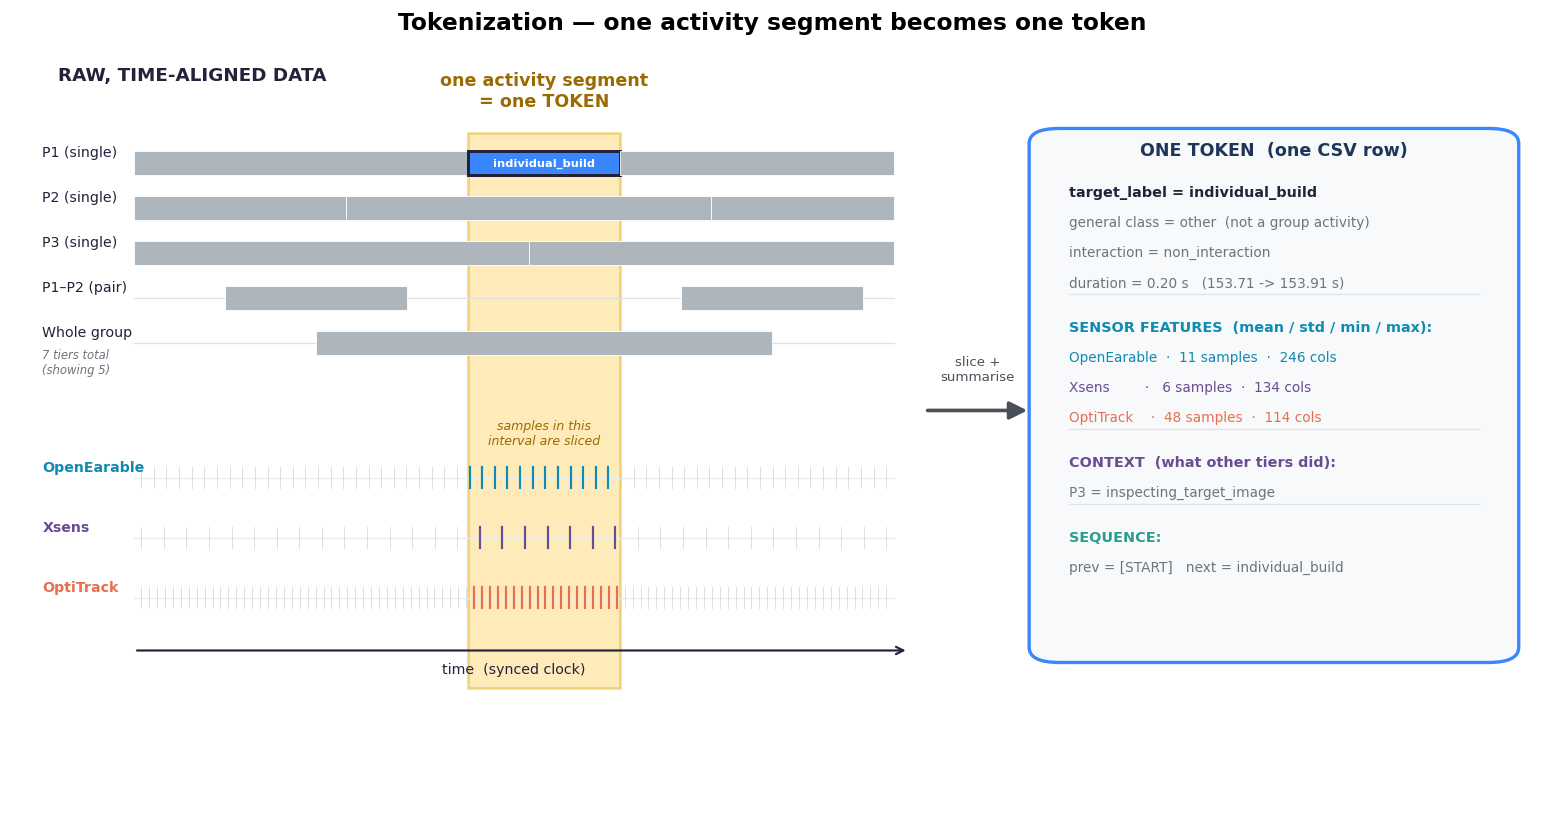

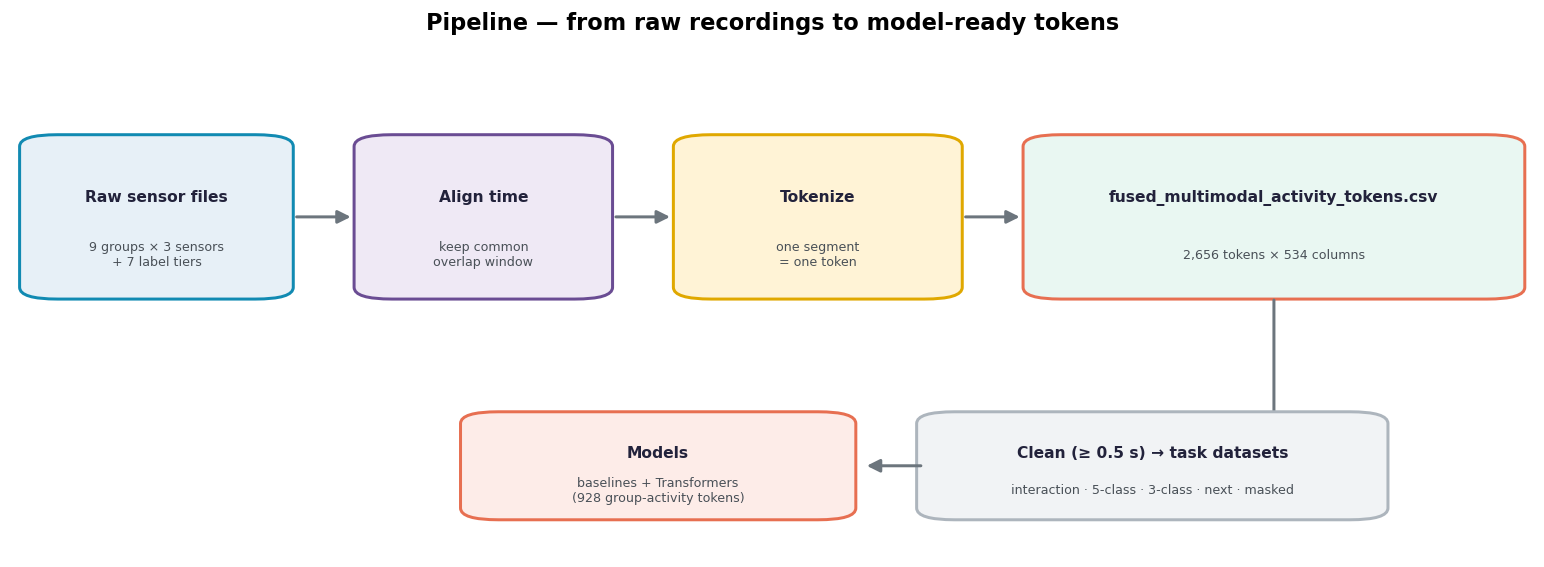

Live check from the real file:
  tokens (rows)      : 2656
  columns            : 534
  median duration (s): 3.96
  tokens ≥ 0.5 s     : 2384 (89.8%)


In [2]:
# ============================================================
# HOW THE TOKENIZED DATA WAS BUILT  —  VISUAL + VERBAL EXPLAINER
#
# Self-contained: just run this cell. It prints a plain-language
# walkthrough and draws two diagrams:
#   FIG 1 : how ONE activity segment becomes ONE token (row)
#   FIG 2 : the full pipeline (raw files -> tokens -> datasets -> models)
#
# Optional: if the fused token CSV is reachable it also prints
# a few live stats from the real file.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "font.size": 11,
})

# Colours
OE   = "#118AB2"   # OpenEarable
XS   = "#6A4C93"   # Xsens
OT   = "#E76F51"   # OptiTrack
BAND = "#FFD166"   # the selected token interval
TIER = "#8D99AE"   # annotation tiers
INK  = "#22223B"

SAVE_DIR = None     # e.g. "/content/drive/MyDrive/thesis/data/ML_MODELS/_figures"
if SAVE_DIR:
    import os; os.makedirs(SAVE_DIR, exist_ok=True)


# ------------------------------------------------------------
# VERBAL WALKTHROUGH
# ------------------------------------------------------------
print("=" * 78)
print("HOW THE TOKENIZED DATA WAS BUILT".center(78))
print("=" * 78)
print("""
The core idea:  ONE TOKEN = ONE ACTIVITY SEGMENT  (not a fixed time window).

Step 1 - INPUTS
    For each group, 3 time-synced sensor files:
      - OpenEarable (ear-worn: motion, audio-vibration, temperature, pulse)
      - Xsens       (body suit: segment orientation + motion)
      - OptiTrack   (optical: 3D position of each person in the room)
    Plus human annotations on 7 "tiers": 3 single-person, 3 pair, 1 whole-group.

Step 2 - ALIGN TIME
    Keep only the time window where all 3 sensors overlap (checked per group).
    Every token lives inside that safe, shared window.

Step 3 - DEFINE TOKEN BOUNDARIES (from the labels)
    Walk each annotation tier and find runs of the SAME label.
    Each continuous run of one activity = one segment = one token,
    with a start time, end time and duration. Durations vary by design.

Step 4 - SLICE ALL SENSORS TO THAT INTERVAL
    Take the token's [start, end] and cut OpenEarable, Xsens and OptiTrack
    to exactly that window.

Step 5 - SUMMARISE THE SLICE INTO FEATURES
    Each sensor channel is collapsed to mean / std / min / max over the
    interval, plus a sample-count and a 'missing' flag. That is why each
    token ends up with hundreds of numeric columns.

Step 6 - ADD LABELS, CONTEXT & SEQUENCE
    Map the raw label to a general class, tag interaction vs non-interaction,
    record what the OTHER tiers were doing (context), and store the previous
    and next activity (so next-/masked-prediction tasks become possible).

Result: fused_multimodal_activity_tokens.csv  ->  cleaned (>= 0.5 s)
        ->  task-specific datasets  ->  the models.
""")


# ============================================================
# FIGURE 1 — FROM ONE ACTIVITY SEGMENT TO ONE TOKEN
# ============================================================
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

# ---- The selected token interval (vertical band) ----
bx0, bx1 = 30, 40
ax.add_patch(Rectangle((bx0, 18), bx1 - bx0, 74, facecolor=BAND, alpha=0.45,
                       edgecolor="#E0A800", lw=1.5, zorder=0))
ax.text((bx0 + bx1) / 2, 95, "one activity segment\n= one TOKEN",
        ha="center", va="bottom", fontsize=10.5, fontweight="bold", color="#9a6b00")

# ---- Panel label ----
ax.text(3, 99, "RAW, TIME-ALIGNED DATA", fontsize=11, fontweight="bold", color=INK)

# ---- Annotation tiers (top) ----
tiers = ["P1 (single)", "P2 (single)", "P3 (single)", "P1–P2 (pair)", "Whole group"]
tier_y = [88, 82, 76, 70, 64]
# pre-set coloured segments per lane: list of (x0, x1)
segs = {
    0: [(8, 30), (30, 40), (40, 58)],     # P1 lane: middle one is selected
    1: [(8, 22), (22, 46), (46, 58)],
    2: [(8, 34), (34, 58)],
    3: [(14, 26), (44, 56)],
    4: [(20, 50)],
}
for li, (lab, y) in enumerate(zip(tiers, tier_y)):
    ax.text(2, y + 1.4, lab, fontsize=8.5, ha="left", va="center", color=INK)
    ax.plot([8, 58], [y, y], color="#dee2e6", lw=0.8, zorder=1)
    for (x0, x1) in segs[li]:
        selected = (li == 0 and abs(x0 - bx0) < 0.6)
        ax.add_patch(Rectangle((x0, y - 1.6), x1 - x0, 3.2,
                               facecolor="#adb5bd" if not selected else "#3a86ff",
                               edgecolor=INK if selected else "white",
                               lw=1.8 if selected else 0.5, zorder=2))
        if selected:
            ax.text((x0 + x1) / 2, y, "individual_build", ha="center", va="center",
                    fontsize=6.8, color="white", fontweight="bold", zorder=3)

ax.text(2, 60, "7 tiers total\n(showing 5)", fontsize=7, style="italic", color="#6c757d")

# ---- Sensor streams (bottom) ----
rng = np.random.default_rng(7)
sensors = [("OpenEarable", 46, OE, 60), ("Xsens", 38, XS, 34), ("OptiTrack", 30, OT, 95)]
for name, y, col, dens in sensors:
    ax.text(2, y + 1.4, name, fontsize=8.5, ha="left", va="center", color=col, fontweight="bold")
    ax.plot([8, 58], [y, y], color="#e9ecef", lw=0.8)
    xs = np.linspace(8.5, 57.5, dens)
    for x in xs:
        inside = bx0 <= x <= bx1
        ax.plot([x, x], [y - 1.4, y + 1.4],
                color=col if inside else "#ced4da",
                lw=1.3 if inside else 0.6, alpha=1.0 if inside else 0.7, zorder=2)

# count labels inside band
ax.text((bx0+bx1)/2, 50.5, "samples in this\ninterval are sliced",
        ha="center", fontsize=7.5, color="#9a6b00", style="italic")

# ---- Time axis ----
ax.annotate("", xy=(59, 23), xytext=(8, 23),
            arrowprops=dict(arrowstyle="->", color=INK, lw=1.3))
ax.text(33, 20, "time  (synced clock)", ha="center", fontsize=8.5, color=INK)

# ---- Big arrow to the token box ----
ax.add_patch(FancyArrowPatch((60, 55), (67, 55), arrowstyle="-|>",
             mutation_scale=22, lw=2.2, color="#495057"))
ax.text(63.5, 59, "slice +\nsummarise", ha="center", fontsize=8, color="#495057")

# ---- The resulting TOKEN box (right) ----
ax.add_patch(FancyBboxPatch((67.5, 22), 31, 70, boxstyle="round,pad=0.6,rounding_size=2",
                            facecolor="#f8f9fa", edgecolor="#3a86ff", lw=2))
ax.text(83, 89, "ONE TOKEN  (one CSV row)", ha="center", fontsize=10.5,
        fontweight="bold", color="#1d3557")

token_lines = [
    ("label", "target_label = individual_build", INK),
    ("",      "general class = other  (not a group activity)", "#6c757d"),
    ("",      "interaction = non_interaction", "#6c757d"),
    ("",      "duration = 0.20 s   (153.71 -> 153.91 s)", "#6c757d"),
    ("sep",   "", ""),
    ("h",     "SENSOR FEATURES  (mean / std / min / max):", OE),
    ("",      "OpenEarable  ·  11 samples  ·  246 cols", OE),
    ("",      "Xsens        ·   6 samples  ·  134 cols", XS),
    ("",      "OptiTrack    ·  48 samples  ·  114 cols", OT),
    ("sep",   "", ""),
    ("h",     "CONTEXT  (what other tiers did):", "#6a4c93"),
    ("",      "P3 = inspecting_target_image", "#6c757d"),
    ("sep",   "", ""),
    ("h",     "SEQUENCE:", "#2a9d8f"),
    ("",      "prev = [START]   next = individual_build", "#6c757d"),
]
yy = 85
for kind, txt, col in token_lines:
    if kind == "sep":
        ax.plot([69.5, 96.5], [yy + 1.5, yy + 1.5], color="#dee2e6", lw=0.8)
        yy -= 2.0; continue
    fw = "bold" if kind in ("label", "h") else "normal"
    fs = 8.6 if kind in ("label", "h") else 8.2
    ax.text(69.5, yy, txt, fontsize=fs, color=col, fontweight=fw, va="top")
    yy -= 4.0

fig.suptitle("Tokenization — one activity segment becomes one token",
             fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()
if SAVE_DIR: fig.savefig(f"{SAVE_DIR}/tokenization_diagram.png", bbox_inches="tight")
plt.show()


# ============================================================
# FIGURE 2 — THE FULL PIPELINE
# ============================================================
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

def box(x, y, w, h, title, sub, fc, ec):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.5,rounding_size=2.5",
                                facecolor=fc, edgecolor=ec, lw=1.8))
    ax.text(x + w/2, y + h*0.62, title, ha="center", va="center",
            fontsize=9.3, fontweight="bold", color=INK)
    if sub:
        ax.text(x + w/2, y + h*0.26, sub, ha="center", va="center",
                fontsize=7.6, color="#495057")

def arrow(x0, x1, y):
    ax.add_patch(FancyArrowPatch((x0, y), (x1, y), arrowstyle="-|>",
                 mutation_scale=16, lw=1.8, color="#6c757d"))

y0 = 55
box(1,  y0, 17, 34, "Raw sensor files", "9 groups × 3 sensors\n+ 7 label tiers", "#e7f0f7", OE)
arrow(18.5, 22.5, y0+17)
box(23, y0, 16, 34, "Align time", "keep common\noverlap window", "#efe9f5", XS)
arrow(39.5, 43.5, y0+17)
box(44, y0, 18, 34, "Tokenize", "one segment\n= one token", "#fff3d6", "#E0A800")
arrow(62.5, 66.5, y0+17)
box(67, y0, 32, 34, "fused_multimodal_activity_tokens.csv",
    "2,656 tokens × 534 columns", "#e9f7f2", OT)

# second row
y1 = 8
arrow_down_x = 83
ax.add_patch(FancyArrowPatch((83, y0), (83, y1+18), arrowstyle="-|>",
             mutation_scale=16, lw=1.8, color="#6c757d"))
box(60, y1, 30, 22, "Clean (≥ 0.5 s) → task datasets",
    "interaction · 5-class · 3-class · next · masked", "#f1f3f5", "#adb5bd")
arrow(60, 56, y1+11)
box(30, y1, 25, 22, "Models", "baselines + Transformers\n(928 group-activity tokens)",
    "#fdece8", "#E76F51")

fig.suptitle("Pipeline — from raw recordings to model-ready tokens",
             fontsize=13.5, fontweight="bold", y=1.02)
plt.tight_layout()
if SAVE_DIR: fig.savefig(f"{SAVE_DIR}/tokenization_pipeline.png", bbox_inches="tight")
plt.show()


# ============================================================
# OPTIONAL — live stats from the real file (skips if not found)
# ============================================================
try:
    import pandas as pd
    CSV = "/content/drive/MyDrive/thesis/data/ML_DATASETS/fused_multimodal_activity_tokens.csv"
    _df = pd.read_csv(CSV, low_memory=False)
    print("Live check from the real file:")
    print(f"  tokens (rows)      : {len(_df)}")
    print(f"  columns            : {_df.shape[1]}")
    print(f"  median duration (s): {_df['duration'].median():.2f}")
    print(f"  tokens ≥ 0.5 s     : {int((_df['duration']>=0.5).sum())} "
          f"({(_df['duration']>=0.5).mean()*100:.1f}%)")
except Exception as e:
    print("(Live file not found — diagrams above use the saved example values.)")

                  TOKEN COLUMN DICTIONARY — the non-sensor columns                  

IDENTITY  /  KEYS
------------------------------------------------------------------------------------
  group                            Which recording session / group of 3 people
                                   e.g. 1   [KEY]
  token_index                      Order of this token inside its group (0,1,2,…)
                                   e.g. 0   [KEY]
  global_token_id                  Unique id across the whole file
                                   e.g. 0   [KEY]
  source_start_row_in_reference    First row of this segment in the OpenEarable reference file
                                   e.g. 0   [KEY]
  source_end_row_in_reference      Last row of this segment in the reference file
                                   e.g. 10   [KEY]

TARGET  —  the activity this token represents
------------------------------------------------------------------------------------
  target_tier          

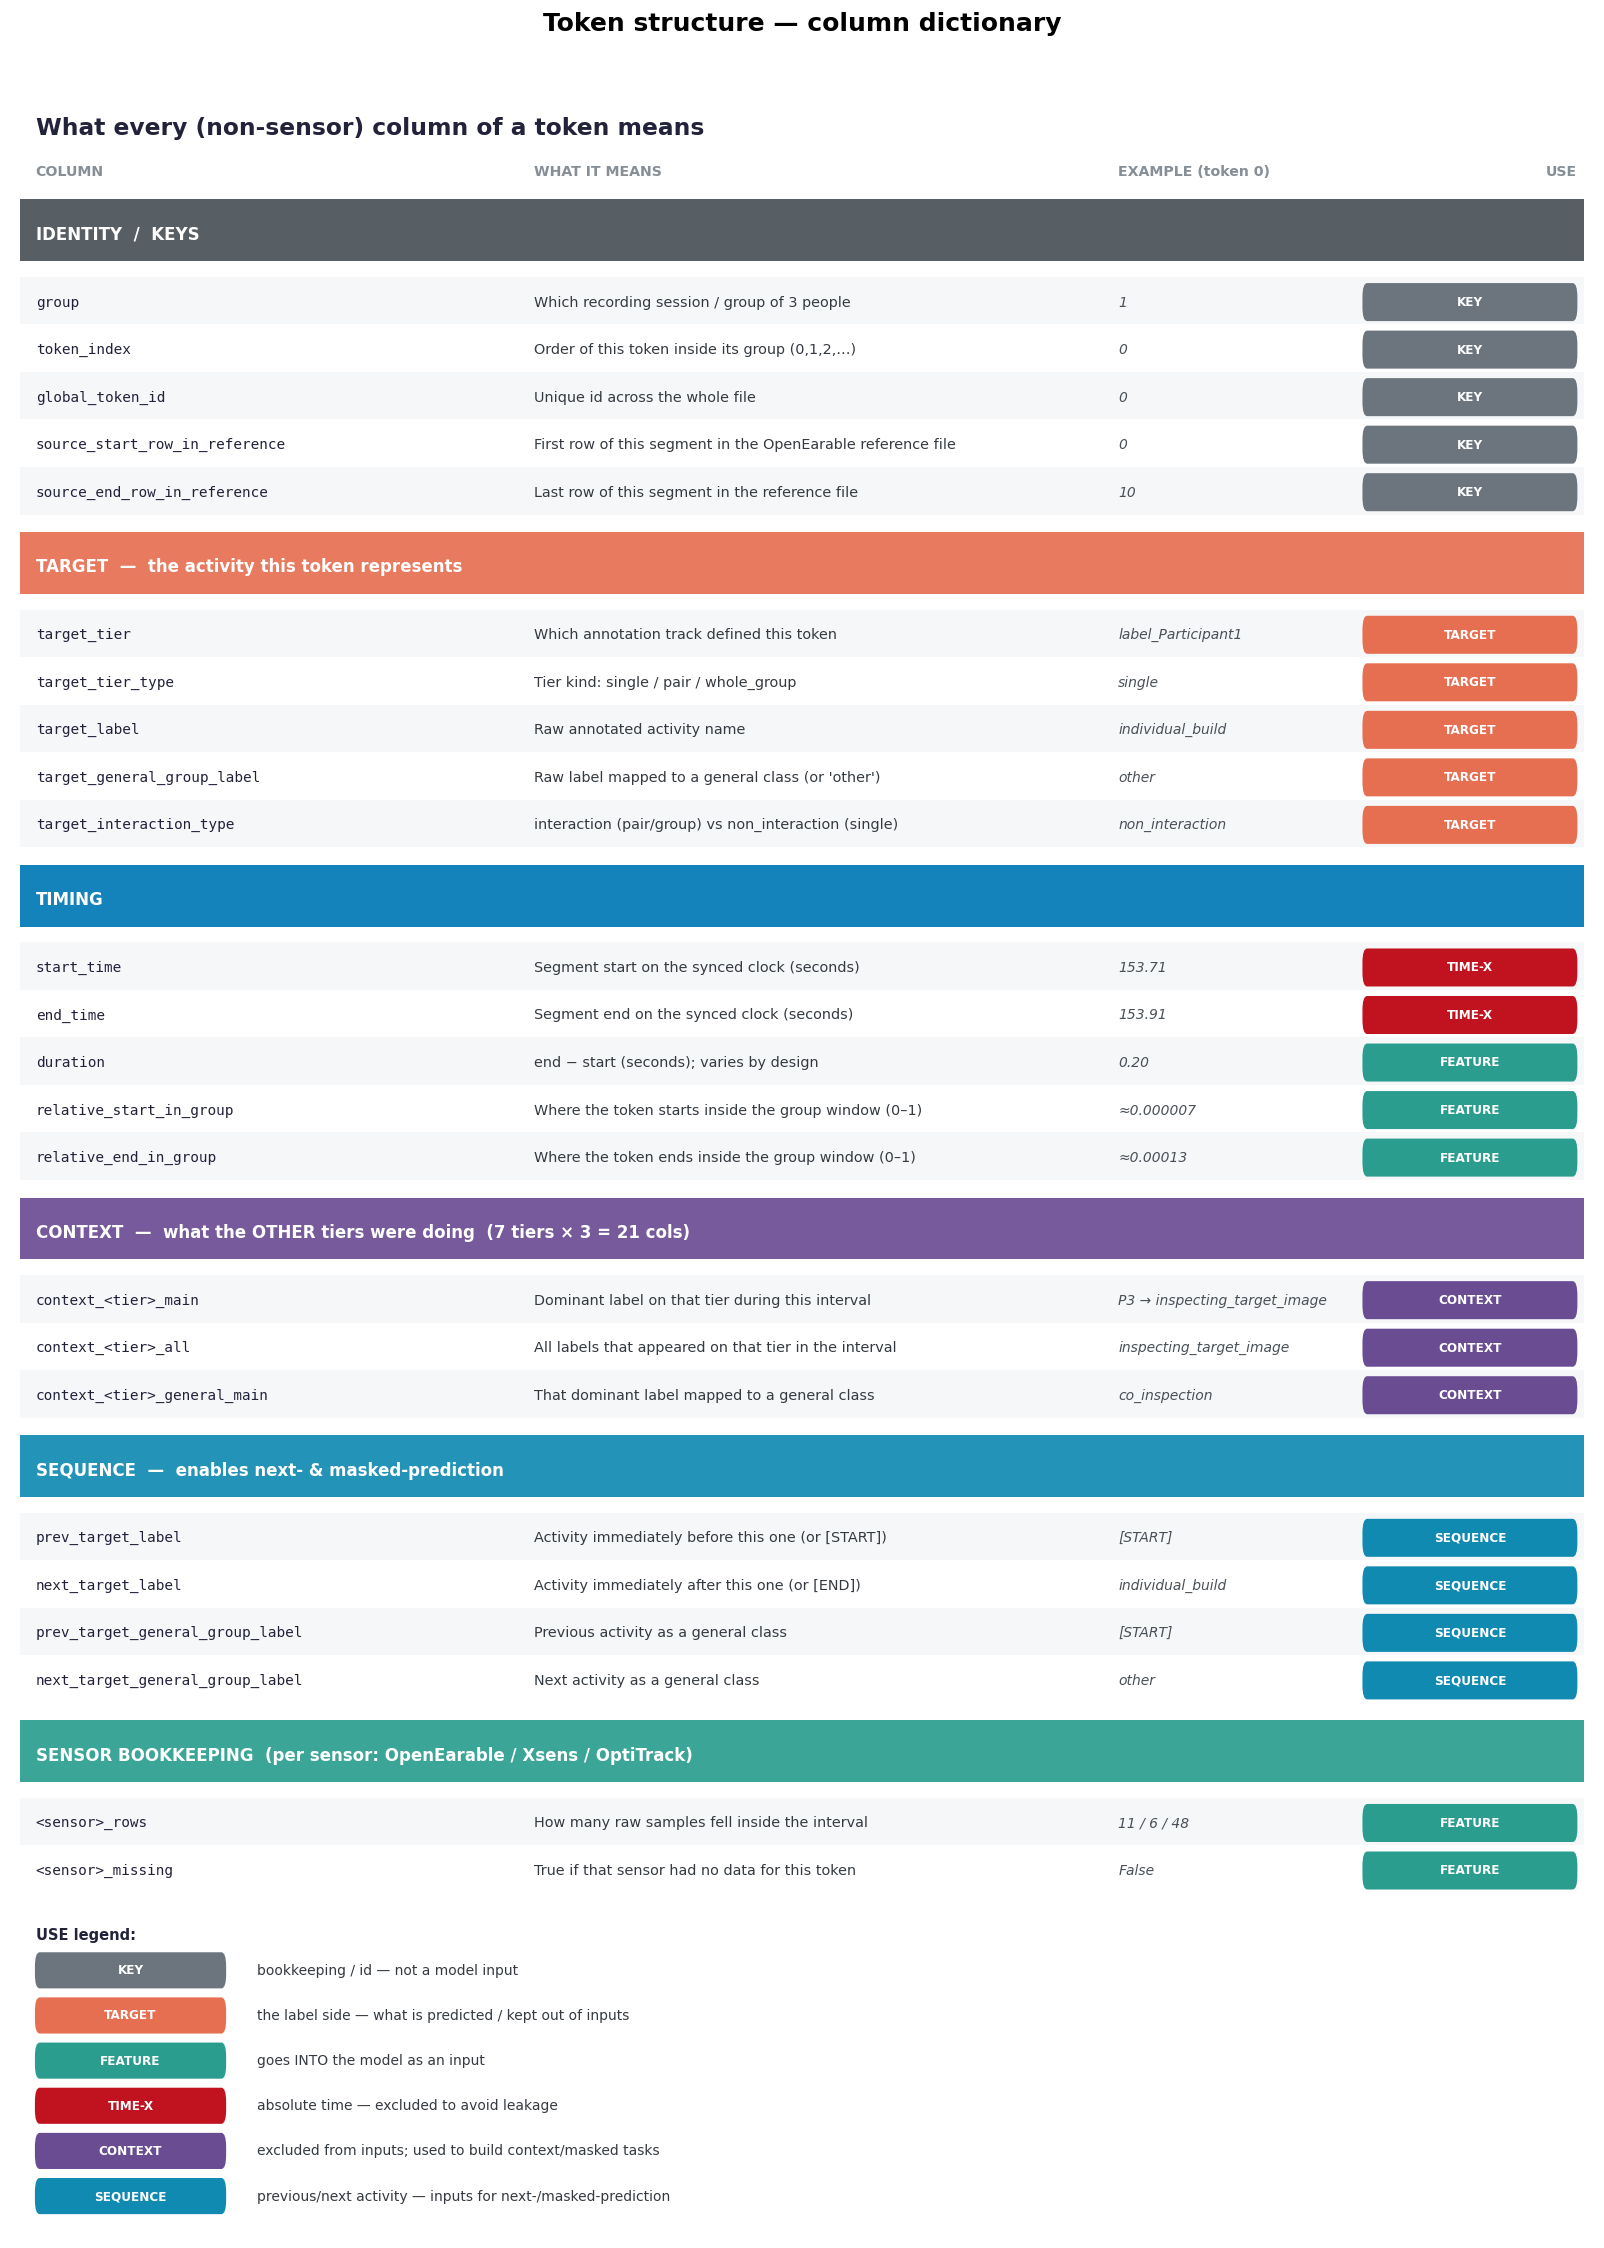


Note: the ~494 sensor columns are simply mean/std/min/max of each
sensor channel inside the interval; this card covers the structure around them.


In [5]:
# ============================================================
# TOKEN COLUMN DICTIONARY  —  the NON-SENSOR columns explained
#
# Companion to the tokenization diagram. Explains every structural
# column of a token (identity, label, timing, context, sequence,
# sensor bookkeeping) — i.e. everything that is NOT a raw
# mean/std/min/max sensor value.
#
# Self-contained: just run it. Prints a text dictionary and draws
# a colour-coded reference card. Example values come from token 0.
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200, "font.size": 11})
SAVE_DIR = None   # e.g. "/content/drive/MyDrive/thesis/data/ML_MODELS/_figures"
if SAVE_DIR:
    import os; os.makedirs(SAVE_DIR, exist_ok=True)

INK = "#22223B"

# Tag = how the column is used downstream
TAGS = {
    "KEY":      ("#6c757d", "bookkeeping / id — not a model input"),
    "TARGET":   ("#E76F51", "the label side — what is predicted / kept out of inputs"),
    "FEATURE":  ("#2A9D8F", "goes INTO the model as an input"),
    "TIME-X":   ("#C1121F", "absolute time — excluded to avoid leakage"),
    "CONTEXT":  ("#6A4C93", "excluded from inputs; used to build context/masked tasks"),
    "SEQUENCE": ("#118AB2", "previous/next activity — inputs for next-/masked-prediction"),
}

# Each section: (title, header_colour, [ (column, meaning, example, tag) ])
SECTIONS = [
    ("IDENTITY  /  KEYS", "#495057", [
        ("group", "Which recording session / group of 3 people", "1", "KEY"),
        ("token_index", "Order of this token inside its group (0,1,2,…)", "0", "KEY"),
        ("global_token_id", "Unique id across the whole file", "0", "KEY"),
        ("source_start_row_in_reference", "First row of this segment in the OpenEarable reference file", "0", "KEY"),
        ("source_end_row_in_reference", "Last row of this segment in the reference file", "10", "KEY"),
    ]),
    ("TARGET  —  the activity this token represents", "#E76F51", [
        ("target_tier", "Which annotation track defined this token", "label_Participant1", "TARGET"),
        ("target_tier_type", "Tier kind: single / pair / whole_group", "single", "TARGET"),
        ("target_label", "Raw annotated activity name", "individual_build", "TARGET"),
        ("target_general_group_label", "Raw label mapped to a general class (or 'other')", "other", "TARGET"),
        ("target_interaction_type", "interaction (pair/group) vs non_interaction (single)", "non_interaction", "TARGET"),
    ]),
    ("TIMING", "#0077B6", [
        ("start_time", "Segment start on the synced clock (seconds)", "153.71", "TIME-X"),
        ("end_time", "Segment end on the synced clock (seconds)", "153.91", "TIME-X"),
        ("duration", "end − start (seconds); varies by design", "0.20", "FEATURE"),
        ("relative_start_in_group", "Where the token starts inside the group window (0–1)", "≈0.000007", "FEATURE"),
        ("relative_end_in_group", "Where the token ends inside the group window (0–1)", "≈0.00013", "FEATURE"),
    ]),
    ("CONTEXT  —  what the OTHER tiers were doing  (7 tiers × 3 = 21 cols)", "#6A4C93", [
        ("context_<tier>_main", "Dominant label on that tier during this interval", "P3 → inspecting_target_image", "CONTEXT"),
        ("context_<tier>_all", "All labels that appeared on that tier in the interval", "inspecting_target_image", "CONTEXT"),
        ("context_<tier>_general_main", "That dominant label mapped to a general class", "co_inspection", "CONTEXT"),
    ]),
    ("SEQUENCE  —  enables next- & masked-prediction", "#118AB2", [
        ("prev_target_label", "Activity immediately before this one (or [START])", "[START]", "SEQUENCE"),
        ("next_target_label", "Activity immediately after this one (or [END])", "individual_build", "SEQUENCE"),
        ("prev_target_general_group_label", "Previous activity as a general class", "[START]", "SEQUENCE"),
        ("next_target_general_group_label", "Next activity as a general class", "other", "SEQUENCE"),
    ]),
    ("SENSOR BOOKKEEPING  (per sensor: OpenEarable / Xsens / OptiTrack)", "#2A9D8F", [
        ("<sensor>_rows", "How many raw samples fell inside the interval", "11 / 6 / 48", "FEATURE"),
        ("<sensor>_missing", "True if that sensor had no data for this token", "False", "FEATURE"),
    ]),
]

# ------------------------------------------------------------
# VERBAL VERSION (printed)
# ------------------------------------------------------------
print("=" * 84)
print("TOKEN COLUMN DICTIONARY — the non-sensor columns".center(84))
print("=" * 84)
for title, _, rows in SECTIONS:
    print("\n" + title)
    print("-" * 84)
    for col, meaning, ex, tag in rows:
        print(f"  {col:<32} {meaning}")
        print(f"  {'':<32} e.g. {ex}   [{tag}]")

# ------------------------------------------------------------
# VISUAL VERSION (reference card)
# ------------------------------------------------------------
# layout maths
HEADER_U = 1.5
ROW_U = 1.0
LEGEND_U = 0.2 + 0.9 + len(TAGS) * 0.95 + 0.6   # space for the USE legend at the bottom
total_u = sum(HEADER_U + ROW_U * len(rows) + 0.4 for _, _, rows in SECTIONS) + 2.2 + LEGEND_U

fig_h = total_u * 0.40 + 0.8
fig, ax = plt.subplots(figsize=(13.5, fig_h))
ax.set_xlim(0, 100); ax.set_ylim(0, total_u); ax.axis("off")
ax.invert_yaxis()

# column x-anchors
X_COL, X_MEAN, X_EX, X_TAG = 1.5, 33, 70, 99

y = 0.4
# title row
ax.text(1.5, y, "What every (non-sensor) column of a token means",
        fontsize=14, fontweight="bold", color=INK, va="top")
y += 1.0
# small header labels
ax.text(X_COL, y, "COLUMN", fontsize=8.5, fontweight="bold", color="#868e96", va="top")
ax.text(X_MEAN, y, "WHAT IT MEANS", fontsize=8.5, fontweight="bold", color="#868e96", va="top")
ax.text(X_EX, y, "EXAMPLE (token 0)", fontsize=8.5, fontweight="bold", color="#868e96", va="top")
ax.text(X_TAG, y, "USE", fontsize=8.5, fontweight="bold", color="#868e96", va="top", ha="right")
y += 0.9

for title, hcol, rows in SECTIONS:
    # section header band
    ax.add_patch(Rectangle((0.5, y - 0.15), 99, HEADER_U - 0.2,
                           facecolor=hcol, alpha=0.92, edgecolor="none"))
    ax.text(1.5, y + (HEADER_U - 0.35) / 2, title, fontsize=10, fontweight="bold",
            color="white", va="center")
    y += HEADER_U + 0.1

    for i, (col, meaning, ex, tag) in enumerate(rows):
        if i % 2 == 0:
            ax.add_patch(Rectangle((0.5, y - 0.12), 99, ROW_U,
                                   facecolor="#f6f7f9", edgecolor="none"))
        cy = y + ROW_U / 2 - 0.1
        ax.text(X_COL, cy, col, fontsize=8.6, family="monospace", color=INK, va="center")
        ax.text(X_MEAN, cy, meaning, fontsize=8.6, color="#343a40", va="center")
        ax.text(X_EX, cy, ex, fontsize=8.3, color="#495057", va="center", style="italic")
        tcol = TAGS[tag][0]
        ax.add_patch(FancyBboxPatch((X_TAG - 13.5, cy - 0.34), 13.5, 0.7,
                                    boxstyle="round,pad=0.05,rounding_size=0.3",
                                    facecolor=tcol, edgecolor="none"))
        ax.text(X_TAG - 6.75, cy, tag, fontsize=7.2, color="white",
                fontweight="bold", ha="center", va="center")
        y += ROW_U
    y += 0.4

# legend for the USE tags
y += 0.2
ax.text(1.5, y, "USE legend:", fontsize=8.8, fontweight="bold", color=INK, va="top")
y += 0.9
for tag, (tcol, desc) in TAGS.items():
    ax.add_patch(FancyBboxPatch((1.5, y - 0.32), 12, 0.66,
                                boxstyle="round,pad=0.05,rounding_size=0.3",
                                facecolor=tcol, edgecolor="none"))
    ax.text(7.5, y, tag, fontsize=7.2, color="white", fontweight="bold", ha="center", va="center")
    ax.text(15.5, y, desc, fontsize=8.3, color="#343a40", va="center")
    y += 0.95

fig.suptitle("Token structure — column dictionary", fontsize=15, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
if SAVE_DIR: fig.savefig(f"{SAVE_DIR}/token_column_dictionary.png", bbox_inches="tight")
plt.show()

print("\nNote: the ~494 sensor columns are simply mean/std/min/max of each")
print("sensor channel inside the interval; this card covers the structure around them.")

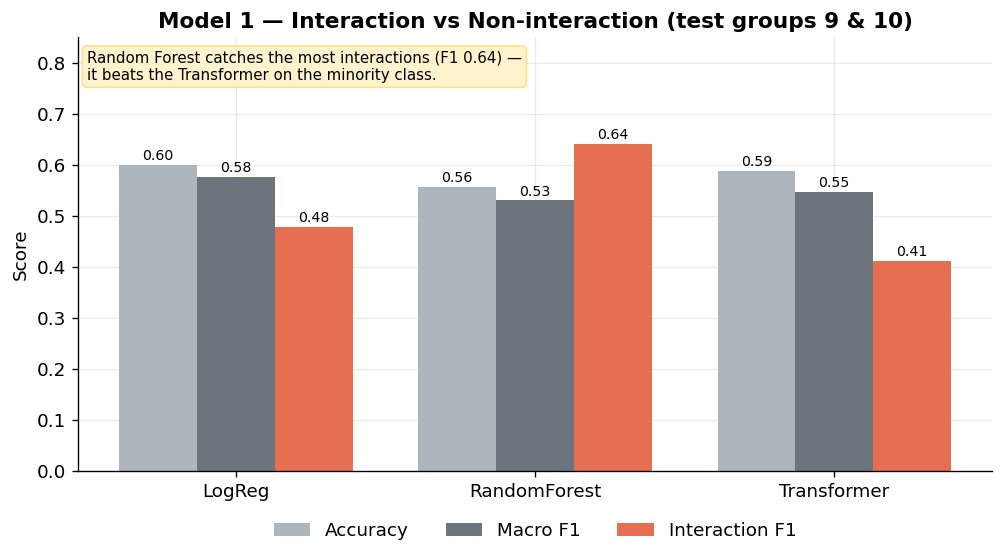

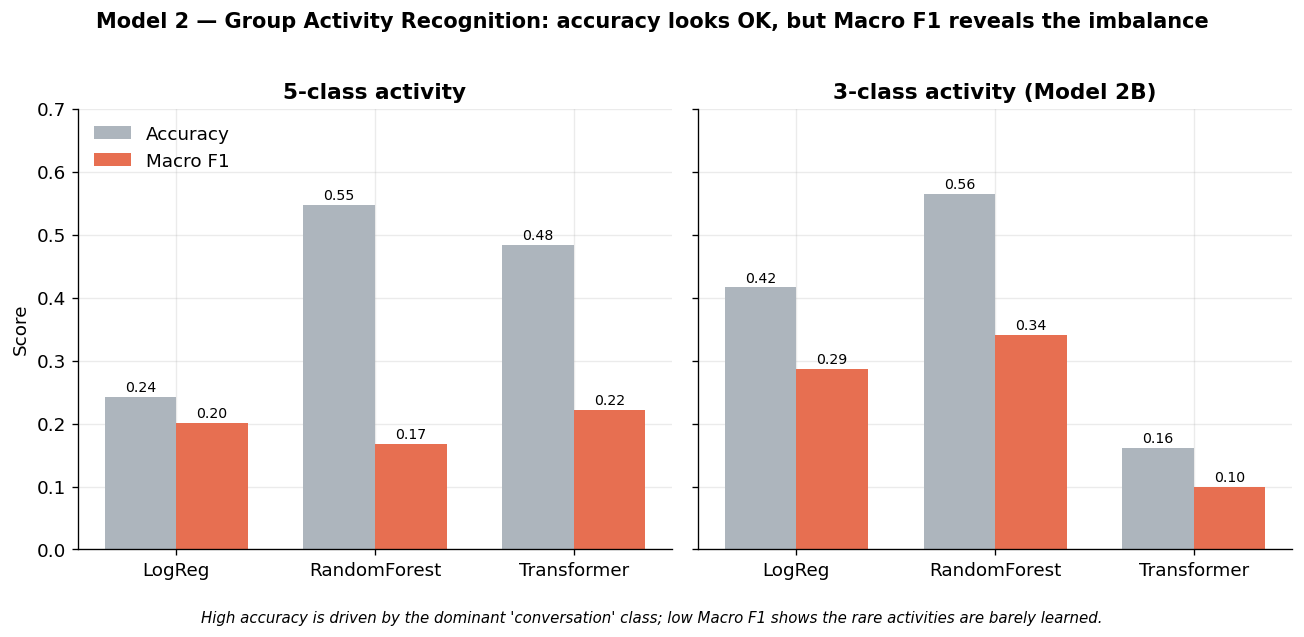

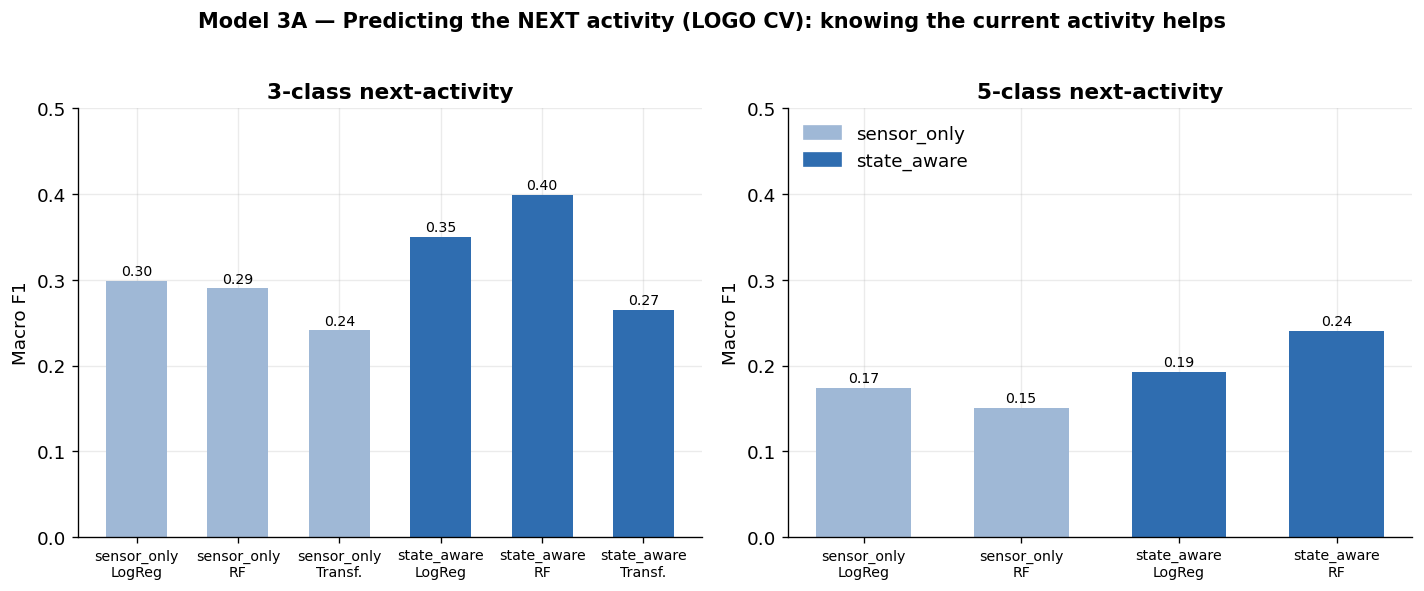

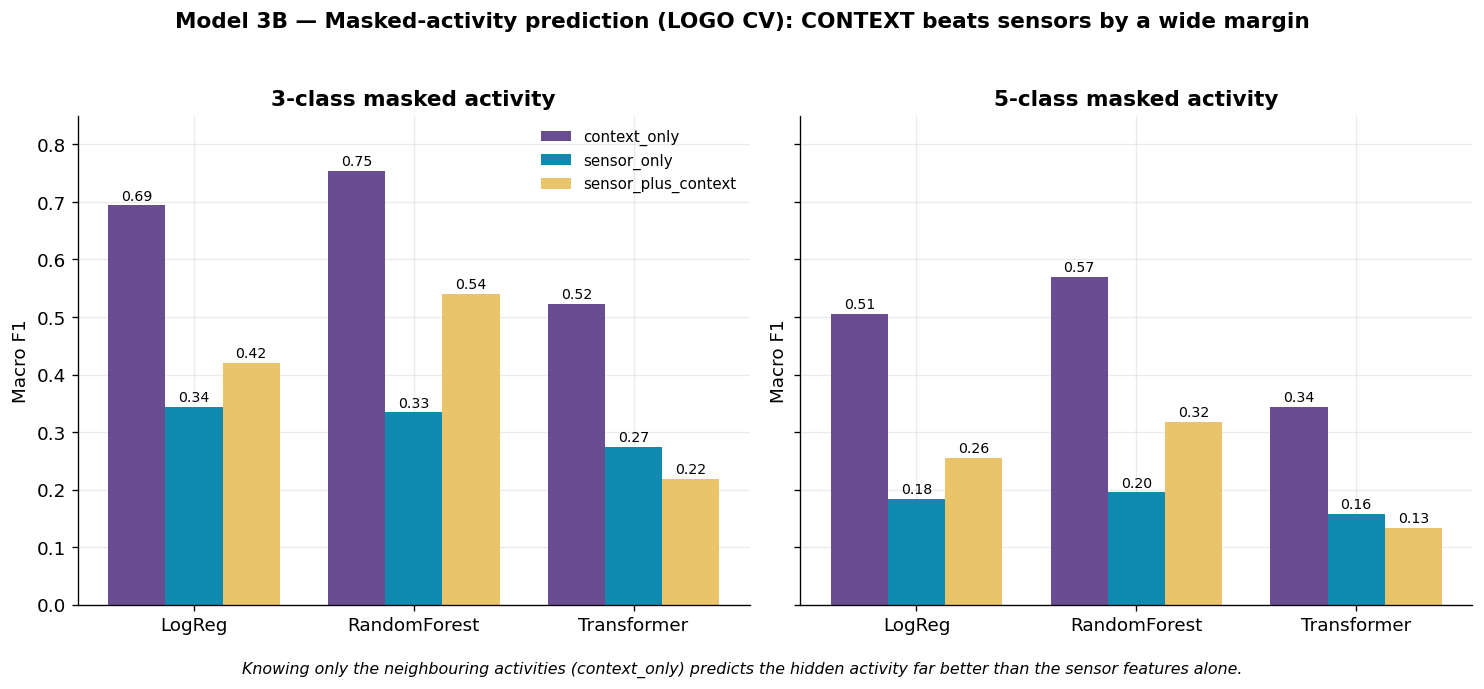

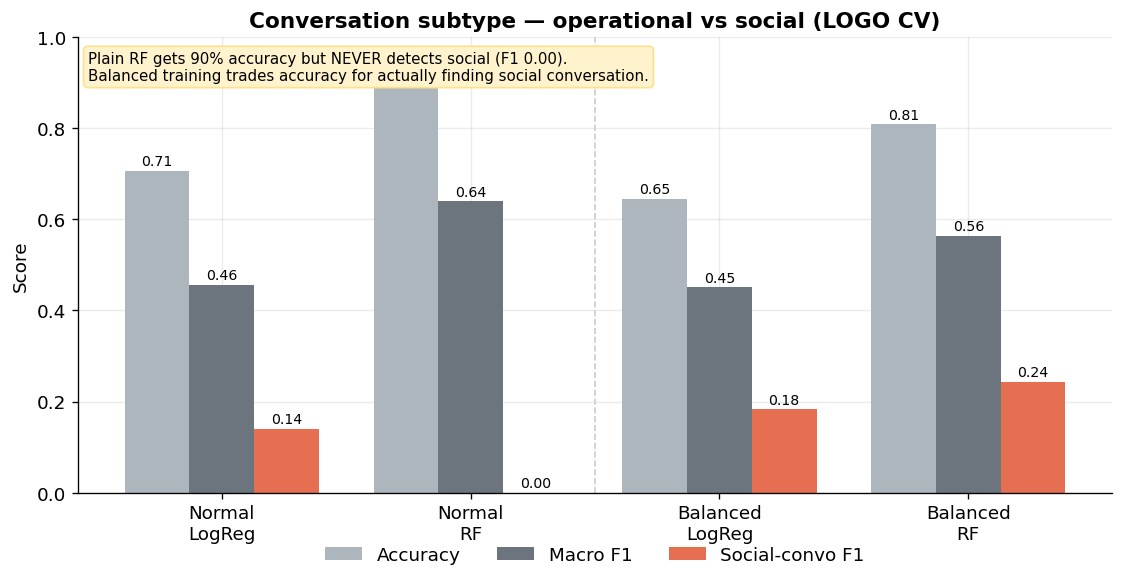

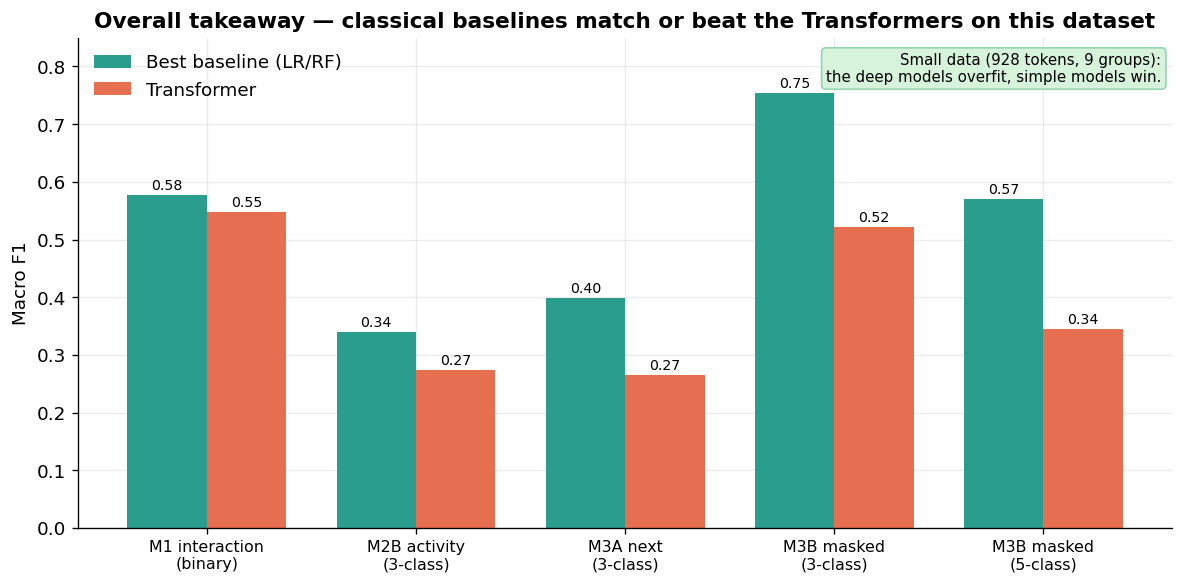

All figures generated.


In [1]:
# ============================================================
# THESIS RESULTS — VISUAL SUMMARY
#
# Self-contained: all numbers are baked in from the model runs,
# so this cell reproduces the full results story with no file paths.
#
# Produces 6 figures:
#   1. Model 1  — Interaction detection (binary)
#   2. Model 2  — Activity recognition (5-class & 3-class)
#   3. Model 3A — Next-activity prediction
#   4. Model 3B — Masked-activity prediction   <-- headline finding
#   5. Conversation subtype (operational vs social)
#   6. Baselines vs Transformers (overall takeaway)
#
# Set SAVE_DIR to a folder if you also want PNGs on disk.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ------------------------------------------------------------
# Global style
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "axes.axisbelow": True,
})

# Consistent colours
C_LR   = "#4C72B0"   # Logistic Regression
C_RF   = "#2A9D8F"   # Random Forest
C_TR   = "#E76F51"   # Transformer
C_CTX  = "#6A4C93"   # context_only
C_SENS = "#118AB2"   # sensor_only
C_BOTH = "#E9C46A"   # sensor_plus_context

SAVE_DIR = None  # e.g. "/content/drive/MyDrive/thesis/data/ML_MODELS/_figures"

if SAVE_DIR:
    import os
    os.makedirs(SAVE_DIR, exist_ok=True)


def _bar_labels(ax, bars, fmt="{:.2f}", fontsize=8.5):
    for b in bars:
        h = b.get_height()
        ax.annotate(fmt.format(h),
                    (b.get_x() + b.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=fontsize,
                    xytext=(0, 1.5), textcoords="offset points")


def _save(fig, name):
    if SAVE_DIR:
        fig.savefig(f"{SAVE_DIR}/{name}.png", bbox_inches="tight")


# ============================================================
# FIGURE 1 — MODEL 1: INTERACTION DETECTION (binary)
# Scene-level, held-out test groups 9 & 10
# ============================================================
m1 = pd.DataFrame({
    "model":          ["LogReg", "RandomForest", "Transformer"],
    "accuracy":       [0.600,    0.556,          0.588],
    "macro_f1":       [0.577,    0.530,          0.547],
    "interaction_f1": [0.478,    0.640,          0.411],
})

fig, ax = plt.subplots(figsize=(8.5, 4.8))
metrics = ["accuracy", "macro_f1", "interaction_f1"]
labels  = ["Accuracy", "Macro F1", "Interaction F1"]
x = np.arange(len(m1))
w = 0.26
colors = ["#adb5bd", "#6c757d", "#E76F51"]
for j, (m, lab, col) in enumerate(zip(metrics, labels, colors)):
    bars = ax.bar(x + (j - 1) * w, m1[m], w, label=lab, color=col)
    _bar_labels(ax, bars)
ax.set_xticks(x)
ax.set_xticklabels(m1["model"])
ax.set_ylim(0, 0.85)
ax.set_ylabel("Score")
ax.set_title("Model 1 — Interaction vs Non-interaction (test groups 9 & 10)")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.text(0.01, 0.97,
        "Random Forest catches the most interactions (F1 0.64) —\nit beats the Transformer on the minority class.",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", fc="#fff3cd", ec="#ffe08a"))
plt.tight_layout()
_save(fig, "fig1_model1_interaction")
plt.show()


# ============================================================
# FIGURE 2 — MODEL 2: ACTIVITY RECOGNITION
# Shows the accuracy-vs-macro-F1 gap (class imbalance)
# Held-out test groups 9 & 10
# ============================================================
m2_5 = pd.DataFrame({
    "model":    ["LogReg", "RandomForest", "Transformer"],
    "accuracy": [0.242,    0.547,          0.484],
    "macro_f1": [0.201,    0.168,          0.222],
})
m2_3 = pd.DataFrame({
    "model":    ["LogReg", "RandomForest", "Transformer"],
    "accuracy": [0.416,    0.565,          0.161],
    "macro_f1": [0.286,    0.340,          0.100],
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, dfm, title in zip(axes, [m2_5, m2_3],
                          ["5-class activity", "3-class activity (Model 2B)"]):
    x = np.arange(len(dfm)); w = 0.36
    b1 = ax.bar(x - w/2, dfm["accuracy"], w, label="Accuracy", color="#adb5bd")
    b2 = ax.bar(x + w/2, dfm["macro_f1"], w, label="Macro F1", color="#E76F51")
    _bar_labels(ax, b1); _bar_labels(ax, b2)
    ax.set_xticks(x); ax.set_xticklabels(dfm["model"])
    ax.set_title(title)
    ax.set_ylim(0, 0.7)
axes[0].set_ylabel("Score")
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("Model 2 — Group Activity Recognition: accuracy looks OK, but Macro F1 reveals the imbalance",
             fontsize=12.5, fontweight="bold", y=1.02)
fig.text(0.5, -0.04,
         "High accuracy is driven by the dominant 'conversation' class; low Macro F1 shows the rare activities are barely learned.",
         ha="center", fontsize=9, style="italic")
plt.tight_layout()
_save(fig, "fig2_model2_recognition")
plt.show()


# ============================================================
# FIGURE 3 — MODEL 3A: NEXT-ACTIVITY PREDICTION
# LOGO cross-validation averages. Macro F1.
# state_aware = also know the current activity
# ============================================================
m3a_3 = pd.DataFrame({
    "setup":    ["sensor_only\nLogReg", "sensor_only\nRF", "sensor_only\nTransf.",
                 "state_aware\nLogReg", "state_aware\nRF", "state_aware\nTransf."],
    "macro_f1": [0.299, 0.290, 0.241, 0.350, 0.399, 0.265],
    "accuracy": [0.375, 0.486, 0.352, 0.452, 0.587, 0.388],
    "mode":     ["sensor", "sensor", "sensor", "state", "state", "state"],
})
m3a_5 = pd.DataFrame({
    "setup":    ["sensor_only\nLogReg", "sensor_only\nRF",
                 "state_aware\nLogReg", "state_aware\nRF"],
    "macro_f1": [0.174, 0.151, 0.193, 0.240],
    "accuracy": [0.313, 0.456, 0.325, 0.551],
    "mode":     ["sensor", "sensor", "state", "state"],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, dfm, title in zip(axes, [m3a_3, m3a_5],
                          ["3-class next-activity", "5-class next-activity"]):
    cols = ["#9fb8d6" if m == "sensor" else "#2f6db0" for m in dfm["mode"]]
    x = np.arange(len(dfm))
    bars = ax.bar(x, dfm["macro_f1"], 0.6, color=cols)
    _bar_labels(ax, bars)
    ax.set_xticks(x); ax.set_xticklabels(dfm["setup"], fontsize=8.5)
    ax.set_title(title); ax.set_ylim(0, 0.5); ax.set_ylabel("Macro F1")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="#9fb8d6", label="sensor_only"),
                        Patch(color="#2f6db0", label="state_aware")],
               frameon=False, loc="upper left")
fig.suptitle("Model 3A — Predicting the NEXT activity (LOGO CV): knowing the current activity helps",
             fontsize=12.5, fontweight="bold", y=1.02)
plt.tight_layout()
_save(fig, "fig3_model3a_next")
plt.show()


# ============================================================
# FIGURE 4 — MODEL 3B: MASKED-ACTIVITY PREDICTION  (HEADLINE)
# LOGO CV averages. Macro F1.
# context_only = previous + next activity (no sensors)
# ============================================================
order = ["context_only", "sensor_only", "sensor_plus_context"]
cmap  = {"context_only": C_CTX, "sensor_only": C_SENS, "sensor_plus_context": C_BOTH}

m3b_3 = {  # (LogReg, RandomForest, Transformer) macro F1
    "context_only":        [0.694, 0.754, 0.522],
    "sensor_only":         [0.343, 0.334, 0.274],
    "sensor_plus_context": [0.420, 0.540, 0.218],
}
m3b_5 = {
    "context_only":        [0.506, 0.570, 0.344],
    "sensor_only":         [0.184, 0.195, 0.158],
    "sensor_plus_context": [0.255, 0.317, 0.134],
}
models = ["LogReg", "RandomForest", "Transformer"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), sharey=True)
for ax, data, title in zip(axes, [m3b_3, m3b_5],
                           ["3-class masked activity", "5-class masked activity"]):
    x = np.arange(len(models)); w = 0.26
    for j, mode in enumerate(order):
        bars = ax.bar(x + (j - 1) * w, data[mode], w, label=mode, color=cmap[mode])
        _bar_labels(ax, bars)
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_title(title); ax.set_ylim(0, 0.85); ax.set_ylabel("Macro F1")
axes[0].legend(frameon=False, loc="upper right", fontsize=9)
fig.suptitle("Model 3B — Masked-activity prediction (LOGO CV): CONTEXT beats sensors by a wide margin",
             fontsize=13, fontweight="bold", y=1.03)
fig.text(0.5, -0.03,
         "Knowing only the neighbouring activities (context_only) predicts the hidden activity far better than the sensor features alone.",
         ha="center", fontsize=9.5, style="italic")
plt.tight_layout()
_save(fig, "fig4_model3b_masked")
plt.show()


# ============================================================
# FIGURE 5 — CONVERSATION SUBTYPE (operational vs social)
# LOGO CV averages. The minority 'social' class is the story.
# ============================================================
conv = pd.DataFrame({
    "setup":      ["Normal\nLogReg", "Normal\nRF", "Balanced\nLogReg", "Balanced\nRF"],
    "accuracy":   [0.706, 0.904, 0.645, 0.809],
    "macro_f1":   [0.456, 0.640, 0.451, 0.564],
    "social_f1":  [0.140, 0.000, 0.183, 0.243],
})

fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(conv)); w = 0.26
b1 = ax.bar(x - w, conv["accuracy"],  w, label="Accuracy",          color="#adb5bd")
b2 = ax.bar(x,     conv["macro_f1"],  w, label="Macro F1",          color="#6c757d")
b3 = ax.bar(x + w, conv["social_f1"], w, label="Social-convo F1",   color="#E76F51")
for b in (b1, b2, b3): _bar_labels(ax, b)
ax.set_xticks(x); ax.set_xticklabels(conv["setup"])
ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.axvline(1.5, color="0.8", lw=1, ls="--")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.set_title("Conversation subtype — operational vs social (LOGO CV)")
ax.text(0.01, 0.97,
        "Plain RF gets 90% accuracy but NEVER detects social (F1 0.00).\nBalanced training trades accuracy for actually finding social conversation.",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", fc="#fff3cd", ec="#ffe08a"))
plt.tight_layout()
_save(fig, "fig5_conversation_subtype")
plt.show()


# ============================================================
# FIGURE 6 — BASELINES vs TRANSFORMERS (overall takeaway)
# Best baseline Macro F1 vs Transformer Macro F1 per task
# ============================================================
comp = pd.DataFrame({
    "task": ["M1 interaction\n(binary)", "M2B activity\n(3-class)",
             "M3A next\n(3-class)", "M3B masked\n(3-class)",
             "M3B masked\n(5-class)"],
    "best_baseline": [0.577, 0.340, 0.399, 0.754, 0.570],
    "transformer":   [0.547, 0.274, 0.265, 0.522, 0.344],
})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp)); w = 0.38
b1 = ax.bar(x - w/2, comp["best_baseline"], w, label="Best baseline (LR/RF)", color=C_RF)
b2 = ax.bar(x + w/2, comp["transformer"],   w, label="Transformer",           color=C_TR)
_bar_labels(ax, b1); _bar_labels(ax, b2)
ax.set_xticks(x); ax.set_xticklabels(comp["task"], fontsize=9.5)
ax.set_ylim(0, 0.85); ax.set_ylabel("Macro F1")
ax.legend(frameon=False, loc="upper left")
ax.set_title("Overall takeaway — classical baselines match or beat the Transformers on this dataset")
ax.text(0.99, 0.97,
        "Small data (928 tokens, 9 groups):\nthe deep models overfit, simple models win.",
        transform=ax.transAxes, va="top", ha="right", fontsize=9,
        bbox=dict(boxstyle="round", fc="#d8f3dc", ec="#95d5b2"))
plt.tight_layout()
_save(fig, "fig6_baselines_vs_transformers")
plt.show()

print("All figures generated.")
if SAVE_DIR:
    print("Saved PNGs to:", SAVE_DIR)